## Rubric Checklist

### 1. 데이터 전처리 및 증강
- [x] 정규식 기반 텍스트 정제
- [x] MeCab 토큰화
- [x] 길이 필터링
- [x] 중복 제거
- [x] Word2Vec Lexical Substitution
- [x] 약 3만 개 Train 데이터 구축 (29,076)
- [x] Train / Validation leakage 검증

### 2. Transformer 학습
- [x] Encoder-Decoder Transformer 구현
- [x] Positional Encoding
- [x] Multi-Head Attention
- [x] Padding Mask
- [x] Causal Mask
- [x] Teacher Forcing
- [x] Warm-up Learning Rate
- [x] Validation 기반 Best checkpoint 선택
- [x] 과적합 근거 분석

### 3. 챗봇 평가
- [x] 지정 4개 질문 자유 생성
- [x] Validation 383개 autoregressive generation
- [x] BLEU-1 ~ BLEU-4 평가
- [x] 정성 평가
- [x] 모델 한계 분석

In [1]:
# ============================================================
# GD06 Transformer Chatbot Project
# Cell 1. Colab 런타임 및 임시 작업공간 확인
# ============================================================
#
# 목표
# 1) 현재 Python / PyTorch / CUDA / GPU 환경을 기록한다.
# 2) Google Drive를 아직 마운트하지 않는다.
# 3) 재다운로드 가능한 데이터와 중간 산출물은
#    Google Drive가 아닌 /content 아래에서 처리한다.
#
# 저장 원칙
# - 원본 ChatbotData.csv : GitHub → RAM으로 직접 읽기
# - Word2Vec / cache     : /content (임시)
# - best model           : 나중에 Drive/models
# - metrics / plot       : 나중에 Drive/outputs
# ============================================================

import sys
import shutil
import platform
from pathlib import Path

import torch


# ------------------------------------------------------------
# 1. 프로젝트 기본 정보
# ------------------------------------------------------------

PROJECT_NAME = "GD06_Transformer_Chatbot_Project"

# Colab 런타임 종료 시 사라지는 임시 작업 공간
CONTENT_ROOT = Path("/content/gd06_chatbot")
CONTENT_DATA = CONTENT_ROOT / "data"
CONTENT_CACHE = CONTENT_ROOT / "cache"
CONTENT_MODELS = CONTENT_ROOT / "models"

for path in [
    CONTENT_ROOT,
    CONTENT_DATA,
    CONTENT_CACHE,
    CONTENT_MODELS,
]:
    path.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 2. Python / PyTorch / CUDA 환경 확인
# ------------------------------------------------------------

print("=" * 70)
print("[Runtime]")
print("=" * 70)

print("Project        :", PROJECT_NAME)
print("Python         :", sys.version.split()[0])
print("Platform       :", platform.platform())
print("PyTorch        :", torch.__version__)
print("CUDA available :", torch.cuda.is_available())
print("CUDA runtime   :", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))
else:
    print("GPU            : None")


# ------------------------------------------------------------
# 3. /content 임시 저장공간 확인
# ------------------------------------------------------------

total, used, free = shutil.disk_usage("/content")

GB = 1024 ** 3

print("\n" + "=" * 70)
print("[Temporary workspace]")
print("=" * 70)

print("CONTENT_ROOT   :", CONTENT_ROOT)
print("CONTENT_DATA   :", CONTENT_DATA)
print("CONTENT_CACHE  :", CONTENT_CACHE)
print("CONTENT_MODELS :", CONTENT_MODELS)

print(f"\n/content total : {total / GB:.2f} GB")
print(f"/content used  : {used / GB:.2f} GB")
print(f"/content free  : {free / GB:.2f} GB")


# ------------------------------------------------------------
# 4. GPU 사용 가능 여부 최종 판정
# ------------------------------------------------------------

assert torch.cuda.is_available(), (
    "GPU가 활성화되지 않았습니다. "
    "Colab의 런타임 유형에서 T4 GPU를 선택한 뒤 다시 실행하세요."
)

device = torch.device("cuda")

print("\n" + "=" * 70)
print("[Ready]")
print("=" * 70)

print("device         :", device)
print("Drive mounted? :", Path("/content/drive/MyDrive").exists())
print("\n런타임 기본 점검 완료")

[Runtime]
Project        : GD06_Transformer_Chatbot_Project
Python         : 3.13.15
Platform       : Linux-6.6.122+-x86_64-with-glibc2.39
PyTorch        : 2.11.0+cu128
CUDA available : True
CUDA runtime   : 12.8
GPU            : Tesla T4

[Temporary workspace]
CONTENT_ROOT   : /content/gd06_chatbot
CONTENT_DATA   : /content/gd06_chatbot/data
CONTENT_CACHE  : /content/gd06_chatbot/cache
CONTENT_MODELS : /content/gd06_chatbot/models

/content total : 235.68 GB
/content used  : 47.37 GB
/content free  : 188.29 GB

[Ready]
device         : cuda
Drive mounted? : False

런타임 기본 점검 완료


## 1. NLP 라이브러리 설치

현재 Colab은 Python 3.13 환경이므로, LMS의 `오래된` MeCab 설치 스크립트 대신
Python 3.13과 호환되는 `mecab-python3`와 `mecab-ko-dic`을 사용한다.

- `KoNLPy`: LMS 프로젝트에서 요구하는 `Mecab.morphs()` 인터페이스 사용
- `mecab-python3`: Python과 MeCab을 연결하는 binding
- `mecab-ko-dic`: 한국어 형태소 분석 사전
- `gensim`: 이후 Word2Vec 기반 Lexical Substitution
- `nltk`: 이후 BLEU Score 계산

Colab 기본 PyTorch/CUDA 조합은 변경하지 않는다.

In [2]:
# ============================================================
# Cell 2. NLP 라이브러리 설치
# ============================================================
#
# 중요:
# - Colab 기본 PyTorch는 재설치하지 않는다.
# - 이전에 실패했던 구형 mecab.sh 설치 스크립트도 사용하지 않는다.
# - Python 3.13 호환 Python binding + 한국어 사전을 사용한다.
# ============================================================

%pip install -q -U \
    konlpy \
    mecab-python3==1.0.12 \
    mecab-ko-dic \
    gensim \
    nltk


# ------------------------------------------------------------
# 설치된 패키지 버전 확인
# ------------------------------------------------------------

from importlib.metadata import version

packages = [
    "konlpy",
    "mecab-python3",
    "mecab-ko-dic",
    "gensim",
    "nltk",
]

print("=" * 70)
print("[NLP packages]")
print("=" * 70)

for package in packages:
    print(f"{package:<16}: {version(package)}")

print("\nNLP 패키지 설치 및 버전 확인 완료")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.2/33.2 MB 51.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.3/591.3 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 39.1 MB/s eta 0:00:00
[NLP packages]
konlpy          : 0.6.0
mecab-python3   : 1.0.12
mecab-ko-dic    : 1.0.0
gensim          : 4.4.0
nltk            : 3.10.3

NLP 패키지 설치 및 버전 확인 완료


## 2. MeCab 형태소 분석기 초기화 및 검증

프로젝트의 한국어 토큰화에는 LMS에서 요구한 KoNLPy의 `Mecab`을 사용한다.

현재 Colab 환경에서는 `mecab-ko-dic` 패키지가 설치한 실제 사전 경로를
자동으로 확인하여 `Mecab`에 전달한다. 경로를 코드에 직접 고정하지 않으므로
Colab 환경이 달라져도 사전 위치 변화에 대응할 수 있다.

이 단계에서는 실제 프로젝트 문장을 형태소 단위로 분해해
`mecab.morphs()`가 정상적으로 사용할 수 있는지 확인한다.

In [5]:
# ============================================================
# Cell 3. MeCab 형태소 분석기 초기화 및 검증
# ============================================================
#
# 목표
# 1) mecab-ko-dic의 실제 한국어 사전 경로를 자동 확인한다.
# 2) 현재 Colab에 누락된 기본 mecabrc를 필요한 경우에만 생성한다.
# 3) KoNLPy Mecab을 초기화한다.
# 4) 프로젝트에서 사용할 mecab.morphs()를 실제 문장으로 검증한다.
# ============================================================

import shlex
from pathlib import Path

import mecab_ko_dic
from konlpy.tag import Mecab


# ------------------------------------------------------------
# 1. mecab-ko-dic의 실제 사전 경로 확인
# ------------------------------------------------------------

mecab_args = shlex.split(mecab_ko_dic.MECAB_ARGS)

assert "-d" in mecab_args, (
    "mecab-ko-dic 설정에서 dictionary 경로(-d)를 찾지 못했습니다."
)

dicpath = Path(
    mecab_args[mecab_args.index("-d") + 1]
)

assert dicpath.exists(), (
    f"한국어 MeCab dictionary 경로가 존재하지 않습니다: {dicpath}"
)


print("=" * 70)
print("[MeCab dictionary]")
print("=" * 70)

print("dictionary path :", dicpath)
print("exists          :", dicpath.exists())


# ------------------------------------------------------------
# 2. 기본 mecabrc 확인
# ------------------------------------------------------------
#
# mecab-python3는 기본적으로 /usr/local/etc/mecabrc를 찾을 수 있다.
# 현재 Colab에는 이 파일이 없으므로, 없을 때에만 빈 파일을 생성한다.
#
# 실제 한국어 dictionary는 아래 Mecab(dicpath=...)에서 명시적으로 지정한다.
# ------------------------------------------------------------

MECABRC_PATH = Path("/usr/local/etc/mecabrc")

if not MECABRC_PATH.exists():
    MECABRC_PATH.parent.mkdir(parents=True, exist_ok=True)
    MECABRC_PATH.touch()

    mecabrc_status = "created"
else:
    mecabrc_status = "already exists"


print("\n" + "=" * 70)
print("[MeCab rc file]")
print("=" * 70)

print("mecabrc path    :", MECABRC_PATH)
print("status          :", mecabrc_status)
print("exists          :", MECABRC_PATH.exists())


# ------------------------------------------------------------
# 3. KoNLPy Mecab 초기화
# ------------------------------------------------------------

mecab = Mecab(dicpath=str(dicpath))


# ------------------------------------------------------------
# 4. 형태소 분석 테스트
# ------------------------------------------------------------

test_sentences = [
    "오늘 일찍 일어났더니 피곤하다.",
    "지루하다, 놀러가고 싶어.",
    "간만에 여자친구랑 데이트 하기로 했어.",
]

print("\n" + "=" * 70)
print("[MeCab morphs test]")
print("=" * 70)

for sentence in test_sentences:
    tokens = mecab.morphs(sentence)

    print("\n원문 :", sentence)
    print("토큰 :", tokens)
    print("개수 :", len(tokens))


# ------------------------------------------------------------
# 5. 프로젝트 사용 가능 여부 검증
# ------------------------------------------------------------

test_tokens = mecab.morphs(
    "오늘 일찍 일어났더니 피곤하다."
)

assert isinstance(test_tokens, list), (
    "mecab.morphs() 결과가 list가 아닙니다."
)

assert len(test_tokens) > 0, (
    "mecab.morphs() 결과가 비어 있습니다."
)


print("\n" + "=" * 70)
print("[Ready]")
print("=" * 70)

print("mecab.morphs() 사용 가능")
print("한국어 토큰화 환경 점검 완료")

[MeCab dictionary]
dictionary path : /usr/local/lib/python3.13/dist-packages/mecab_ko_dic/dicdir
exists          : True

[MeCab rc file]
mecabrc path    : /usr/local/etc/mecabrc
status          : created
exists          : True

[MeCab morphs test]

원문 : 오늘 일찍 일어났더니 피곤하다.
토큰 : ['오늘', '일찍', '일어났', '더니', '피곤', '하', '다', '.']
개수 : 8

원문 : 지루하다, 놀러가고 싶어.
토큰 : ['지루', '하', '다', ',', '놀', '러', '가', '고', '싶', '어', '.']
개수 : 11

원문 : 간만에 여자친구랑 데이트 하기로 했어.
토큰 : ['간만에', '여자', '친구', '랑', '데이트', '하', '기', '로', '했', '어', '.']
개수 : 11

[Ready]
mecab.morphs() 사용 가능
한국어 토큰화 환경 점검 완료


## 3. 공통 라이브러리 및 실험 재현성 설정

딥러닝 실험은 데이터 분할, 파라미터 초기화, 배치 순서 등 여러 과정에서
난수가 사용되기 때문에 실행할 때마다 결과가 조금씩 달라질 수 있다.

이번 프로젝트에서는 비교 가능한 실험을 위해 `SEED = 42`로 고정하고,
Python `random`, NumPy, PyTorch의 난수 상태를 동일하게 설정한다.

GPU 연산의 특성상 완전히 동일한 결과가 항상 보장되는 것은 아니지만,
가능한 범위에서 실험 조건을 통제한다.

In [6]:
# ============================================================
# Cell 4. 공통 라이브러리 및 실험 재현성 설정
# ============================================================

import os
import re
import math
import time
import random
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

import gensim
import nltk


# ------------------------------------------------------------
# 1. Random seed 고정
# ------------------------------------------------------------

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# 2. 가능한 범위에서 CUDA 연산 재현성 설정
# ------------------------------------------------------------
#
# benchmark=False:
# 입력 크기에 따라 매번 가장 빠른 알고리즘을 새로 찾지 않도록 한다.
#
# deterministic=True:
# 가능한 경우 deterministic한 CUDA 연산을 사용한다.
#
# 완전한 bit-level 동일성까지 보장하는 것은 아니다.
# ------------------------------------------------------------

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


# ------------------------------------------------------------
# 3. 프로젝트 공통 device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ------------------------------------------------------------
# 4. 환경 확인
# ------------------------------------------------------------

print("=" * 70)
print("[Experiment configuration]")
print("=" * 70)

print("SEED           :", SEED)
print("device         :", device)
print("NumPy          :", np.__version__)
print("pandas         :", pd.__version__)
print("PyTorch        :", torch.__version__)
print("gensim         :", gensim.__version__)
print("NLTK           :", nltk.__version__)

if torch.cuda.is_available():
    print("GPU            :", torch.cuda.get_device_name(0))

print("\n재현성 설정 및 공통 import 완료")

[Experiment configuration]
SEED           : 42
device         : cuda
NumPy          : 2.1.3
pandas         : 2.2.3
PyTorch        : 2.11.0+cu128
gensim         : 4.4.0
NLTK           : 3.10.3
GPU            : Tesla T4

재현성 설정 및 공통 import 완료


## 4. Step 1 — 챗봇 원본 데이터 불러오기 및 기초 점검

LMS에서 지정한 `songys/Chatbot_data`의 `ChatbotData.csv`를 사용한다.

이번 실험에서는 저장소 전체를 clone하거나 CSV를 Google Drive에 복사하지 않고,
GitHub의 특정 commit에 있는 CSV를 `pandas`로 직접 읽어 메모리에 적재한다.

이렇게 하면:

- 원본 데이터가 Google Drive 용량을 차지하지 않는다.
- 저장소의 향후 변경과 무관하게 같은 데이터 버전을 재현할 수 있다.
- 이후 전처리 전/후 데이터 수를 비교할 수 있다.

이 단계에서는 원본 데이터의 행 수, 컬럼, 결측치, 중복, label 분포만 확인하고
아직 데이터를 삭제하거나 변경하지 않는다.

In [7]:
# ============================================================
# Cell 5. Step 1 — ChatbotData.csv 불러오기 및 원본 EDA
# ============================================================
#
# 원칙
# - GitHub repository 전체를 clone하지 않는다.
# - Google Drive에도 원본 CSV를 복사하지 않는다.
# - 특정 commit을 고정하여 동일한 원본 데이터를 사용한다.
# - 이 셀에서는 원본을 수정하지 않고 상태만 확인한다.
# ============================================================


# ------------------------------------------------------------
# 1. 데이터 소스 고정
# ------------------------------------------------------------

DATA_REPOSITORY = "songys/Chatbot_data"

# 프로젝트 시작 시점에 확인한 repository commit
DATA_COMMIT = "4cf20d13fc46f5037fd1c531cd566e2dd9f72974"

DATA_URL = (
    "https://raw.githubusercontent.com/"
    f"{DATA_REPOSITORY}/{DATA_COMMIT}/ChatbotData.csv"
)


print("=" * 70)
print("[Data source]")
print("=" * 70)

print("repository :", DATA_REPOSITORY)
print("commit     :", DATA_COMMIT)
print("storage    : RAM (Google Drive에 저장하지 않음)")


# ------------------------------------------------------------
# 2. CSV를 메모리로 직접 읽기
# ------------------------------------------------------------

df_raw = pd.read_csv(DATA_URL)


# 원본 보존을 위해 이후 작업은 복사본에서 진행할 예정
df = df_raw.copy()


# ------------------------------------------------------------
# 3. 기본 구조 확인
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[Dataset structure]")
print("=" * 70)

print("shape   :", df_raw.shape)
print("columns :", df_raw.columns.tolist())

display(df_raw.head())


# 프로젝트에서 필요한 컬럼 존재 여부 확인
required_columns = {"Q", "A"}

assert required_columns.issubset(df_raw.columns), (
    f"필수 컬럼 {required_columns}이 없습니다. "
    f"현재 컬럼: {df_raw.columns.tolist()}"
)


# ------------------------------------------------------------
# 4. 결측치 확인
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[Missing values]")
print("=" * 70)

print(df_raw.isna().sum())


# ------------------------------------------------------------
# 5. 중복 현황 확인
# ------------------------------------------------------------

full_duplicates = df_raw.duplicated().sum()
question_duplicates = df_raw["Q"].duplicated().sum()
answer_duplicates = df_raw["A"].duplicated().sum()


print("\n" + "=" * 70)
print("[Duplicates]")
print("=" * 70)

print("완전 중복 행 :", full_duplicates)
print("질문(Q) 중복 :", question_duplicates)
print("답변(A) 중복 :", answer_duplicates)


# ------------------------------------------------------------
# 6. label 컬럼 확인
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[Label]")
print("=" * 70)

if "label" in df_raw.columns:
    label_counts = (
        df_raw["label"]
        .value_counts(dropna=False)
        .sort_index()
    )

    print(label_counts)
else:
    print("label 컬럼 없음")


# ------------------------------------------------------------
# 7. 질문 / 답변 데이터 준비
# ------------------------------------------------------------

questions_raw = df_raw["Q"].astype(str).tolist()
answers_raw = df_raw["A"].astype(str).tolist()


print("\n" + "=" * 70)
print("[Raw corpus]")
print("=" * 70)

print("questions :", len(questions_raw))
print("answers   :", len(answers_raw))

assert len(questions_raw) == len(answers_raw)

print("\n원본 데이터 로딩 및 기초 점검 완료")

[Data source]
repository : songys/Chatbot_data
commit     : 4cf20d13fc46f5037fd1c531cd566e2dd9f72974
storage    : RAM (Google Drive에 저장하지 않음)

[Dataset structure]
shape   : (11823, 3)
columns : ['Q', 'A', 'label']


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0



[Missing values]
Q        0
A        0
label    0
dtype: int64

[Duplicates]
완전 중복 행 : 0
질문(Q) 중복 : 161
답변(A) 중복 : 4044

[Label]
label
0    5290
1    3570
2    2963
Name: count, dtype: int64

[Raw corpus]
questions : 11823
answers   : 11823

원본 데이터 로딩 및 기초 점검 완료


## 5. Step 2 — 문장 정제 (`preprocess_sentence`)

Transformer가 문자열 자체를 바로 처리하는 것은 아니다.
먼저 모델이 학습할 필요가 없는 문자 표현을 정리한 뒤 토큰화를 수행한다.

프로젝트 조건에 따라 다음 규칙을 적용한다.

1. 영문자는 모두 소문자로 변환한다.
2. 영문자, 숫자, 한글, 주요 문장부호만 유지한다.
3. 그 외 문자(이모지 등)는 공백으로 치환한다.
4. 문자 제거 과정에서 생긴 연속 공백은 하나로 정리한다.

이번 프로젝트에서 유지하는 주요 문장부호는
`. , ? ! ~` 로 정의한다.

LMS 설명대로 문장부호 양옆에 별도의 공백을 추가하지 않는다.
이후 사용할 MeCab이 문장부호를 별도 토큰으로 처리할 수 있기 때문이다.

이 단계에서는 데이터 손실 여부를 확인하기 위해
정제 전후 문장을 비교하고, 정제 후 빈 문장이 발생하는지도 함께 점검한다.

In [8]:
# ============================================================
# Cell 6. Step 2 — 문장 정제
# ============================================================
#
# 아직 수행하지 않는 것:
# - MeCab 토큰화
# - 길이 필터링
# - 중복 제거
# - Train / Validation 분리
#
# 현재 목표:
# "문자열을 어떤 규칙으로 정리했는가?"를 명확하게 기록한다.
# ============================================================


# ------------------------------------------------------------
# 1. 문장 정제 함수
# ------------------------------------------------------------

def preprocess_sentence(sentence: str) -> str:
    """
    ChatbotData 문장을 프로젝트 조건에 맞게 정제한다.

    유지:
    - 영문 소문자 a-z
    - 숫자 0-9
    - 한글 자모 ㄱ-ㅎ, ㅏ-ㅣ
    - 한글 완성형 가-힣
    - 주요 문장부호 . , ? ! ~

    제거:
    - 이모지
    - 그 외 기호 및 문자
    """

    # 혹시 문자열 외 자료형이 들어와도 안전하게 처리
    sentence = str(sentence)

    # 1) 영문 대문자 → 소문자
    sentence = sentence.lower()

    # 2) 허용 문자 이외에는 공백으로 치환
    sentence = re.sub(
        r"[^a-z0-9ㄱ-ㅎㅏ-ㅣ가-힣.,?!~]+",
        " ",
        sentence
    )

    # 3) 문자 제거 과정에서 생긴 연속 공백 정리
    sentence = re.sub(r"\s+", " ", sentence).strip()

    return sentence


# ------------------------------------------------------------
# 2. 사람이 이해하기 쉬운 예제로 먼저 테스트
# ------------------------------------------------------------

test_sentences = [
    "PPL 심하네",
    "HELLO! 오늘 기분 어때?",
    "ㅋㅋㅋ 정말??? 좋아~ 😊",
    "3박4일 정도 놀러가고 싶다",
]

print("=" * 70)
print("[Preprocess function test]")
print("=" * 70)

for sentence in test_sentences:
    cleaned = preprocess_sentence(sentence)

    print("\n원본 :", sentence)
    print("정제 :", cleaned)


# ------------------------------------------------------------
# 3. 실제 전체 Q/A 데이터에 정제 적용
# ------------------------------------------------------------

questions_clean = [
    preprocess_sentence(sentence)
    for sentence in questions_raw
]

answers_clean = [
    preprocess_sentence(sentence)
    for sentence in answers_raw
]


# ------------------------------------------------------------
# 4. 정제 전후 변화량 확인
# ------------------------------------------------------------

q_changed = sum(
    raw != clean
    for raw, clean in zip(questions_raw, questions_clean)
)

a_changed = sum(
    raw != clean
    for raw, clean in zip(answers_raw, answers_clean)
)

q_empty = sum(
    len(sentence) == 0
    for sentence in questions_clean
)

a_empty = sum(
    len(sentence) == 0
    for sentence in answers_clean
)


print("\n" + "=" * 70)
print("[Cleaning summary]")
print("=" * 70)

print(f"전체 질문            : {len(questions_raw):,}")
print(f"정제 후 변경된 질문  : {q_changed:,}")
print(f"정제 후 빈 질문      : {q_empty:,}")

print()

print(f"전체 답변            : {len(answers_raw):,}")
print(f"정제 후 변경된 답변  : {a_changed:,}")
print(f"정제 후 빈 답변      : {a_empty:,}")


# ------------------------------------------------------------
# 5. 실제 데이터 중 변경된 사례 확인
# ------------------------------------------------------------

changed_examples = []

for q_raw, q_clean, a_raw, a_clean in zip(
    questions_raw,
    questions_clean,
    answers_raw,
    answers_clean
):
    if q_raw != q_clean or a_raw != a_clean:
        changed_examples.append({
            "Q_raw": q_raw,
            "Q_clean": q_clean,
            "A_raw": a_raw,
            "A_clean": a_clean,
        })

changed_df = pd.DataFrame(changed_examples)

print("\n" + "=" * 70)
print("[Changed examples]")
print("=" * 70)

print("정제에 의해 변경된 Q-A pair :", len(changed_df))

if len(changed_df) > 0:
    display(changed_df.head(10))


# ------------------------------------------------------------
# 6. Q-A pair 수가 그대로 유지됐는지 검증
# ------------------------------------------------------------

assert len(questions_clean) == len(answers_clean)
assert len(questions_clean) == len(df_raw)

print("\n문장 정제 완료")

[Preprocess function test]

원본 : PPL 심하네
정제 : ppl 심하네

원본 : HELLO! 오늘 기분 어때?
정제 : hello! 오늘 기분 어때?

원본 : ㅋㅋㅋ 정말??? 좋아~ 😊
정제 : ㅋㅋㅋ 정말??? 좋아~

원본 : 3박4일 정도 놀러가고 싶다
정제 : 3박4일 정도 놀러가고 싶다

[Cleaning summary]
전체 질문            : 11,823
정제 후 변경된 질문  : 32
정제 후 빈 질문      : 0

전체 답변            : 11,823
정제 후 변경된 답변  : 20
정제 후 빈 답변      : 0

[Changed examples]
정제에 의해 변경된 Q-A pair : 49


,Q_raw,Q_clean,A_raw,A_clean
0,PPL 심하네,ppl 심하네,눈살이 찌푸려지죠.,눈살이 찌푸려지죠.
1,SD카드 망가졌어,sd카드 망가졌어,다시 새로 사는 게 마음 편해요.,다시 새로 사는 게 마음 편해요.
2,SD카드 안돼,sd카드 안돼,다시 새로 사는 게 마음 편해요.,다시 새로 사는 게 마음 편해요.
3,SNS 맞팔 왜 안하지ㅠㅠ,sns 맞팔 왜 안하지ㅠㅠ,잘 모르고 있을 수도 있어요.,잘 모르고 있을 수도 있어요.
4,SNS 시간낭비인 거 아는데 매일 하는 중,sns 시간낭비인 거 아는데 매일 하는 중,시간을 정하고 해보세요.,시간을 정하고 해보세요.
5,SNS 시간낭비인데 자꾸 보게됨,sns 시간낭비인데 자꾸 보게됨,시간을 정하고 해보세요.,시간을 정하고 해보세요.
6,SNS보면 나만 빼고 다 행복해보여,sns보면 나만 빼고 다 행복해보여,자랑하는 자리니까요.,자랑하는 자리니까요.
7,나는 좋은데 ….,나는 좋은데 .,현실의 벽에 부딪혔나봐요.,현실의 벽에 부딪혔나봐요.
8,남친 SNS에 내 사진 없어,남친 sns에 내 사진 없어,신경쓰지 마세요.,신경쓰지 마세요.
9,남친이 SNS에 내 사진에 안 올려,남친이 sns에 내 사진에 안 올려,신경쓰지 마세요.,신경쓰지 마세요.



문장 정제 완료


## 6. Step 3 준비 — MeCab 토큰 길이 분포 분석

프로젝트에서는 토큰 수가 일정 길이 이상인 문장을 제외하도록 요구한다.
하지만 최대 길이에 대한 고정값은 제시하지 않는다.

따라서 임의로 길이를 정하지 않고, 정제된 전체 질문과 답변을
MeCab으로 형태소 토큰화한 뒤 실제 길이 분포를 확인한다.

확인할 항목:

- 질문/답변의 평균 및 중앙값
- p90 / p95 / p99
- 최대 토큰 길이
- 후보 MAX_TOKENS별 데이터 보존율
- 가장 긴 실제 문장의 내용

최종 `MAX_TOKENS`는 이 결과를 근거로 결정한다.

아직 이 단계에서는 문장을 제거하지 않는다.

In [9]:
# ============================================================
# Cell 7. Step 3 준비 — MeCab 토큰 길이 EDA
# ============================================================
#
# 목표
# 1) 정제된 Q/A 전체를 MeCab으로 토큰화한다.
# 2) 실제 토큰 길이 분포를 확인한다.
# 3) MAX_TOKENS 후보별 데이터 보존율을 비교한다.
#
# 아직 수행하지 않는 것:
# - 길이 필터링
# - 중복 제거
# - Train / Validation split
# ============================================================


# ------------------------------------------------------------
# 1. 전체 문장 MeCab 토큰화
# ------------------------------------------------------------

start_time = time.time()

questions_tokens_all = [
    mecab.morphs(sentence)
    for sentence in questions_clean
]

answers_tokens_all = [
    mecab.morphs(sentence)
    for sentence in answers_clean
]

elapsed = time.time() - start_time


# ------------------------------------------------------------
# 2. 토큰 길이 계산
# ------------------------------------------------------------

q_lengths = np.array([
    len(tokens)
    for tokens in questions_tokens_all
])

a_lengths = np.array([
    len(tokens)
    for tokens in answers_tokens_all
])

# Q-A pair 중 더 긴 쪽을 기준으로 본 길이
pair_max_lengths = np.maximum(
    q_lengths,
    a_lengths
)


# ------------------------------------------------------------
# 3. 기본 검증
# ------------------------------------------------------------

assert len(questions_tokens_all) == len(answers_tokens_all)
assert len(questions_tokens_all) == len(df_raw)

q_empty_tokens = int((q_lengths == 0).sum())
a_empty_tokens = int((a_lengths == 0).sum())


print("=" * 70)
print("[Tokenization]")
print("=" * 70)

print(f"Q-A pairs       : {len(q_lengths):,}")
print(f"tokenize time   : {elapsed:.2f} sec")
print(f"empty Q tokens  : {q_empty_tokens}")
print(f"empty A tokens  : {a_empty_tokens}")


# ------------------------------------------------------------
# 4. 길이 통계 함수
# ------------------------------------------------------------

def summarize_lengths(lengths):
    return {
        "mean": lengths.mean(),
        "p50": np.percentile(lengths, 50),
        "p90": np.percentile(lengths, 90),
        "p95": np.percentile(lengths, 95),
        "p99": np.percentile(lengths, 99),
        "max": lengths.max(),
    }


length_summary = pd.DataFrame({
    "Question": summarize_lengths(q_lengths),
    "Answer": summarize_lengths(a_lengths),
    "Pair max": summarize_lengths(pair_max_lengths),
}).T


print("\n" + "=" * 70)
print("[Token length summary]")
print("=" * 70)

display(
    length_summary.round(2)
)


# ------------------------------------------------------------
# 5. MAX_TOKENS 후보별 pair 보존율
# ------------------------------------------------------------
#
# 실제 build_corpus()에서는 Q와 A 모두 MAX_TOKENS 이하인
# pair만 유지할 예정이므로 pair_max_lengths를 사용한다.
# ------------------------------------------------------------

candidate_limits = [
    10,
    15,
    20,
    25,
    30,
    40,
]

retention_rows = []

for limit in candidate_limits:
    kept = int(
        (pair_max_lengths <= limit).sum()
    )

    removed = len(pair_max_lengths) - kept

    retention_rows.append({
        "MAX_TOKENS": limit,
        "kept_pairs": kept,
        "removed_pairs": removed,
        "retention_%": (
            kept / len(pair_max_lengths) * 100
        ),
    })


retention_df = pd.DataFrame(
    retention_rows
)


print("\n" + "=" * 70)
print("[Candidate MAX_TOKENS]")
print("=" * 70)

display(
    retention_df.round({
        "retention_%": 2
    })
)


# ------------------------------------------------------------
# 6. 가장 긴 실제 Q-A pair 확인
# ------------------------------------------------------------

length_check_df = pd.DataFrame({
    "Q": questions_clean,
    "A": answers_clean,
    "Q_tokens": questions_tokens_all,
    "A_tokens": answers_tokens_all,
    "Q_len": q_lengths,
    "A_len": a_lengths,
    "pair_max_len": pair_max_lengths,
})


longest_examples = (
    length_check_df
    .sort_values(
        "pair_max_len",
        ascending=False
    )
    .head(10)
)


print("\n" + "=" * 70)
print("[Longest Q-A pairs]")
print("=" * 70)

display(
    longest_examples[
        [
            "Q",
            "A",
            "Q_len",
            "A_len",
            "pair_max_len",
        ]
    ]
)


print("\n토큰 길이 EDA 완료")

[Tokenization]
Q-A pairs       : 11,823
tokenize time   : 0.83 sec
empty Q tokens  : 0
empty A tokens  : 0

[Token length summary]


,mean,p50,p90,p95,p99,max
Question,7.03,6.0,12.0,14.0,18.0,32.0
Answer,8.38,8.0,13.0,15.0,20.0,40.0
Pair max,9.44,9.0,14.0,16.0,21.0,40.0



[Candidate MAX_TOKENS]


,MAX_TOKENS,kept_pairs,removed_pairs,retention_%
0,10,8141,3682,68.86
1,15,11027,796,93.27
2,20,11665,158,98.66
3,25,11788,35,99.70
4,30,11815,8,99.93
5,40,11823,0,100.00



[Longest Q-A pairs]


,Q,A,Q_len,A_len,pair_max_len
10808,오래 못 가는 연애,연애는 문제가 있으면 문제를 해결 하기 위해 함께 노력하고 그 속에서 더욱 단단해지...,5,40,40
10780,오늘 만나기로 했는데 빈손으로 나가?,준비하지 않아도 상관 없다고 생각해요. 필요하다면 화려하지 않고 부담 없는 선물을 ...,10,37,37
10811,오래 연애해서 그런가 관심이 줄었어,연애하다보면 서로에게 익숙해져서 처음만큼 관심을 갖지 않게 되는 게 사실일 거예요....,9,36,36
9884,사랑에 유효기간이 있을까?,"사랑하는 사람과 함께하는 어제, 오늘, 내일이 각 다른 의미가 있다고 생각하면 유효...",8,35,35
10258,썸 탈 때 연락문제로 속상한 적 있어?,썸 탈 때는 특히 속상한 것 같아요. 내 맘 같지 않고 아직 내 사람이 아니니까요....,11,34,34
11810,확실히 좋아하는 데도 관심 있는거 티 안내려고 선톡 안하고 일부러 늦게 보내고 그러...,많이 있어요.,32,4,32
9413,남친 멀어진 것 같아,나를 사랑하지 않는 사람하고 계속 가는 건 나 자신을 사랑하지 않는 사람들이나 하는...,7,31,31
9680,마음이 식은 거 같아,나를 사랑하지 않는 사람하고 계속 가는 건 나 자신을 사랑하지 않는 사람들이나 하는...,7,31,31
5373,5년 사귄 여자친구와 이별이네. 조언부탁좀 드려,저는 저에게 투자하는 시간을 가져요. 예를들면 운동이나 여행같이 잡념을 없앨 수 있...,14,30,30
10728,연애는 하기 싫은데 썸은 타고 싶어.,시작하기 전 두근거림을 더 좋아하나 봐요. 아니면 연애에 대한 두려움을 가지고 있을...,13,30,30



토큰 길이 EDA 완료


### 최대 토큰 길이 결정

MeCab 토큰 길이 분포를 확인한 결과:

- Q-A pair의 평균 최대 길이: 약 9.44 tokens
- p95: 16 tokens
- p99: 21 tokens
- 전체 최대값: 40 tokens

`MAX_TOKENS = 25`로 설정하면 전체 11,823개 pair 중
11,788개(99.70%)를 보존하고 35개(0.30%)만 제외할 수 있다.

이번 데이터셋은 약 1만 건 규모로 크지 않으므로 가능한 한 학습 데이터를
보존하면서도, 극단적으로 긴 소수 문장을 위해 Transformer의 최대 sequence
길이를 과도하게 늘리지 않도록 25를 선택했다.

따라서 이번 실험에서는:

`MAX_TOKENS = 25`

를 전처리 기준으로 사용한다.

※ 이후 Decoder target에는 `<start>`, `<end>` 2개가 추가되므로,
모델 입력 길이를 정의할 때에는 이 점을 별도로 고려한다.

## 7. Step 3 — 학습 Corpus 구축

`build_corpus()`는 질문(source)과 답변(target)을 항상 하나의 pair로 처리한다.

각 pair에 대해 다음 순서를 적용한다.

1. source와 target을 각각 `preprocess_sentence()`로 정제한다.
2. 전달된 tokenizer 함수로 각각 토큰화한다.
3. 둘 중 하나라도 25 tokens를 초과하면 해당 pair 전체를 제외한다.
4. source token sequence가 이미 존재하거나 target token sequence가 이미 존재하면
   해당 pair 전체를 제외한다.
5. 모든 조건을 통과한 경우에만 source와 target을 동시에 corpus에 추가한다.

중복 여부는 문자열이 아니라 **토큰화된 sequence**를 기준으로 검사한다.
이는 Transformer가 실제로 입력받게 될 표현이 동일한 문장도 중복으로 보기 위함이다.

이 방식으로 source와 target의 index 대응 관계를 유지하면서
노드가 요구한 독립적인 중복 제거 조건을 만족시킨다.

In [10]:
# ============================================================
# Cell 8. Step 3 — build_corpus()
# ============================================================

MAX_TOKENS = 25


def build_corpus(
    source_sentences,
    target_sentences,
    tokenizer_fn,
    max_tokens=MAX_TOKENS,
):
    """
    source / target 병렬 데이터를 정제하고 토큰화하여 corpus를 만든다.

    처리 순서
    ----------
    1. source / target 정제
    2. tokenizer_fn으로 토큰화
    3. 빈 문장 제거
    4. max_tokens 초과 pair 제거
    5. source와 target을 각각 독립적으로 중복 검사
    6. pair 관계를 유지한 채 동시에 corpus에 추가

    Returns
    -------
    source_corpus : list[list[str]]
    target_corpus : list[list[str]]
    stats         : dict
    """

    assert len(source_sentences) == len(target_sentences), (
        "source와 target의 문장 수가 다릅니다."
    )

    source_corpus = []
    target_corpus = []

    # Transformer가 실제로 보게 될 token sequence 기준으로 중복 검사
    seen_source = set()
    seen_target = set()

    stats = {
        "input_pairs": len(source_sentences),
        "empty": 0,
        "too_long": 0,
        "duplicate_source": 0,
        "duplicate_target": 0,
        "duplicate_both": 0,
        "kept_pairs": 0,
    }

    for source, target in zip(
        source_sentences,
        target_sentences,
    ):

        # ----------------------------------------------------
        # 1. 정제
        # ----------------------------------------------------

        source_clean = preprocess_sentence(source)
        target_clean = preprocess_sentence(target)


        # ----------------------------------------------------
        # 2. 토큰화
        # ----------------------------------------------------

        source_tokens = tokenizer_fn(source_clean)
        target_tokens = tokenizer_fn(target_clean)


        # ----------------------------------------------------
        # 3. 빈 문장 검사
        # ----------------------------------------------------

        if len(source_tokens) == 0 or len(target_tokens) == 0:
            stats["empty"] += 1
            continue


        # ----------------------------------------------------
        # 4. 최대 길이 검사
        #
        # MAX_TOKENS는 "허용하는 최대 길이"로 정의하므로
        # 25까지 유지하고 26 이상부터 제거한다.
        # ----------------------------------------------------

        if (
            len(source_tokens) > max_tokens
            or len(target_tokens) > max_tokens
        ):
            stats["too_long"] += 1
            continue


        # ----------------------------------------------------
        # 5. 독립적인 source / target 중복 검사
        # ----------------------------------------------------

        source_key = tuple(source_tokens)
        target_key = tuple(target_tokens)

        source_duplicate = source_key in seen_source
        target_duplicate = target_key in seen_target

        if source_duplicate or target_duplicate:

            if source_duplicate and target_duplicate:
                stats["duplicate_both"] += 1

            elif source_duplicate:
                stats["duplicate_source"] += 1

            else:
                stats["duplicate_target"] += 1

            # 한쪽이라도 중복이면 pair 전체를 제외하여
            # source-target alignment를 보존한다.
            continue


        # ----------------------------------------------------
        # 6. 조건을 모두 통과한 pair 저장
        # ----------------------------------------------------

        source_corpus.append(source_tokens)
        target_corpus.append(target_tokens)

        seen_source.add(source_key)
        seen_target.add(target_key)


    stats["kept_pairs"] = len(source_corpus)

    return source_corpus, target_corpus, stats

In [11]:
# ============================================================
# Cell 9. build_corpus() 실행 및 검증
# ============================================================

que_corpus, ans_corpus, corpus_stats = build_corpus(
    questions_raw,
    answers_raw,
    tokenizer_fn=mecab.morphs,
    max_tokens=MAX_TOKENS,
)


print("=" * 70)
print("[Corpus build result]")
print("=" * 70)

for key, value in corpus_stats.items():
    print(f"{key:<20}: {value:,}")


print("\n" + "=" * 70)
print("[Corpus verification]")
print("=" * 70)

print("que_corpus :", len(que_corpus))
print("ans_corpus :", len(ans_corpus))

assert len(que_corpus) == len(ans_corpus)

# source / target 각각 중복이 정말 사라졌는지 확인
unique_questions = len(
    set(tuple(tokens) for tokens in que_corpus)
)

unique_answers = len(
    set(tuple(tokens) for tokens in ans_corpus)
)

print("unique Q   :", unique_questions)
print("unique A   :", unique_answers)

assert unique_questions == len(que_corpus)
assert unique_answers == len(ans_corpus)


# 실제 pair 예시
print("\n" + "=" * 70)
print("[Corpus examples]")
print("=" * 70)

for i in range(5):
    print(f"\n[{i}]")
    print("Q :", que_corpus[i])
    print("A :", ans_corpus[i])


print("\nCorpus 구축 완료")

[Corpus build result]
input_pairs         : 11,823
empty               : 0
too_long            : 35
duplicate_source    : 60
duplicate_target    : 4,034
duplicate_both      : 42
kept_pairs          : 7,652

[Corpus verification]
que_corpus : 7652
ans_corpus : 7652
unique Q   : 7652
unique A   : 7652

[Corpus examples]

[0]
Q : ['12', '시', '땡', '!']
A : ['하루', '가', '또', '가', '네요', '.']

[1]
Q : ['1', '지망', '학교', '떨어졌', '어']
A : ['위로', '해', '드립니다', '.']

[2]
Q : ['3', '박', '4', '일', '놀', '러', '가', '고', '싶', '다']
A : ['여행', '은', '언제나', '좋', '죠', '.']

[3]
Q : ['ppl', '심하', '네']
A : ['눈살', '이', '찌푸려', '지', '죠', '.']

[4]
Q : ['sd', '카드', '망가졌', '어']
A : ['다시', '새로', '사', '는', '게', '마음', '편', '해요', '.']

Corpus 구축 완료


### 전처리 결과와 Augmentation 규모 결정

노드의 조건에 따라 source와 target의 중복을 각각 독립적으로 제거하되,
Q-A pair의 정렬은 유지하였다.

그 결과:
####🫨비상
- 원본 Q-A pair: 11,823
- 길이 초과 제거: 35
- source 중복 제거: 60
- target 중복 제거: 4,034
- source/target 동시 중복 제거: 42
- 최종 corpus: **7,652 pairs**

노드 Step 4에서는 원본 corpus에 대해

1. `Augmented Q + Original A`
2. `Original Q + Augmented A`

를 추가하여 약 3배로 늘리도록 안내한다.

그러나 현재 전처리된 7,652 pairs를 정확히 3배로 만들면
22,956 pairs가 되어, 프로젝트 루브릭의
"3만 개가량의 훈련데이터셋" 기준에는 부족하다.

따라서 본 실험에서는 노드의 기본 두 augmentation을 유지하면서
추가적인 질문 Lexical Substitution variant를 하나 더 생성한다.
####☘️해결책
최종 구성:

- Original Q + Original A
- Q-Augmentation v1 + Original A
- Original Q + A-Augmentation v1
- Q-Augmentation v2 + Original A

예상 전체 크기:

`7,652 × 4 = 30,608 pairs`

단순 복제가 아니라 Word2Vec의 유사 단어 후보 중 서로 다른 치환을
사용하여 추가 variant를 생성한다.

또한 augmentation된 동일 원문의 변형이 train과 validation에 동시에
포함되는 데이터 누수를 방지하기 위해 원본 pair 단위의 group split을 사용한다.

## 8. Step 4 준비 — 사전학습 한국어 Word2Vec 다운로드

Lexical Substitution을 위해 LMS에서 지정한
`Kyubyong/wordvectors`의 **Korean (w)** 사전학습 Word2Vec 모델을 사용한다.

원본 모델은 한국어 말뭉치로 학습된 Word2Vec이며,
공개된 모델 정보는 다음과 같다.

- Embedding dimension: 200
- Vocabulary size: 30,185
- Corpus size: 약 339M
- 배포 파일: `ko.zip`
- 압축 내부 주요 파일: `ko.bin`

이번 프로젝트의 저장 정책에 따라 대용량 외부 모델은
Google Drive에 복제하지 않고 Colab의 임시 저장소인
`/content/gd06_chatbot/data/`에만 저장한다.

이 단계에서는 다운로드된 압축 파일의 존재 여부와 크기, ZIP 구조만 검증하며
아직 Word2Vec 모델을 RAM에 로드하지 않는다.

In [12]:
# ============================================================
# Cell 10. Step 4 준비 — Korean Word2Vec 다운로드
# ============================================================
#
# 이번 셀에서 하는 것
# - Kyubyong Korean Word2Vec의 ko.zip 다운로드
# - /content 아래에만 저장
# - 파일 크기 / ZIP 구조 검증
#
# 아직 하지 않는 것
# - 압축 해제
# - ko.bin 로드
# - Word2Vec 객체 생성
# - Google Drive 저장
# ============================================================

import sys
import subprocess
import zipfile
from pathlib import Path


# ------------------------------------------------------------
# 1. 다운로드 도구 gdown 확인
# ------------------------------------------------------------

try:
    import gdown
except ImportError:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "gdown"]
    )
    import gdown


# ------------------------------------------------------------
# 2. 저장 경로 설정
# ------------------------------------------------------------

KO_W2V_FILE_ID = "0B0ZXk88koS2KbDhXdWg1Q2RydlU"

KO_W2V_URL = (
    "https://drive.google.com/uc"
    f"?id={KO_W2V_FILE_ID}"
)

KO_ZIP_PATH = CONTENT_DATA / "ko.zip"


print("=" * 70)
print("[Korean Word2Vec download]")
print("=" * 70)

print("source  : Kyubyong/wordvectors - Korean (w)")
print("file id :", KO_W2V_FILE_ID)
print("target  :", KO_ZIP_PATH)
print("Drive   : 사용하지 않음")


# ------------------------------------------------------------
# 3. 중복 다운로드 방지
# ------------------------------------------------------------

if KO_ZIP_PATH.exists() and KO_ZIP_PATH.stat().st_size > 0:
    print("\n기존 ko.zip 발견 → 재다운로드하지 않습니다.")

else:
    print("\nko.zip 다운로드 시작...")

    downloaded_path = gdown.download(
        url=KO_W2V_URL,
        output=str(KO_ZIP_PATH),
        quiet=False,
        fuzzy=True,
    )

    assert downloaded_path is not None, (
        "Google Drive에서 ko.zip 다운로드에 실패했습니다."
    )


# ------------------------------------------------------------
# 4. 실제 파일 존재 / 크기 검증
# ------------------------------------------------------------

assert KO_ZIP_PATH.exists(), (
    f"다운로드 파일이 존재하지 않습니다: {KO_ZIP_PATH}"
)

file_size_mb = KO_ZIP_PATH.stat().st_size / (1024 ** 2)

print("\n" + "=" * 70)
print("[Downloaded file]")
print("=" * 70)

print("path :", KO_ZIP_PATH)
print(f"size : {file_size_mb:.2f} MB")


# ------------------------------------------------------------
# 5. ZIP 파일인지 검증
# ------------------------------------------------------------

assert zipfile.is_zipfile(KO_ZIP_PATH), (
    "다운로드된 파일이 정상적인 ZIP 파일이 아닙니다."
)


# ZIP을 풀지 않고 내부 파일명만 확인
with zipfile.ZipFile(KO_ZIP_PATH, "r") as zip_ref:
    archive_members = zip_ref.namelist()


print("\n" + "=" * 70)
print("[ZIP contents]")
print("=" * 70)

for member in archive_members:
    print(member)


assert any(
    Path(member).name == "ko.bin"
    for member in archive_members
), "ZIP 내부에서 ko.bin을 찾지 못했습니다."


# ------------------------------------------------------------
# 6. 현재 /content 저장공간 확인
# ------------------------------------------------------------

total, used, free = shutil.disk_usage("/content")

print("\n" + "=" * 70)
print("[Temporary storage]")
print("=" * 70)

print(f"/content used : {used / GB:.2f} GB")
print(f"/content free : {free / GB:.2f} GB")

print("\nko.zip 다운로드 및 무결성 점검 완료")
print("Word2Vec 모델은 아직 RAM에 로드하지 않았습니다.")

[Korean Word2Vec download]
source  : Kyubyong/wordvectors - Korean (w)
file id : 0B0ZXk88koS2KbDhXdWg1Q2RydlU
target  : /content/gd06_chatbot/data/ko.zip
Drive   : 사용하지 않음

ko.zip 다운로드 시작...


Downloading...
From (original): https://drive.google.com/uc?id=0B0ZXk88koS2KbDhXdWg1Q2RydlU
From (redirected): https://drive.google.com/uc?id=0B0ZXk88koS2KbDhXdWg1Q2RydlU&confirm=t&uuid=9da0d776-e86a-41a3-bc8f-93db62600fb4
To: /content/gd06_chatbot/data/ko.zip
100%|██████████| 80.6M/80.6M [00:02<00:00, 28.2MB/s]


[Downloaded file]
path : /content/gd06_chatbot/data/ko.zip
size : 76.86 MB

[ZIP contents]
ko.bin
ko.tsv

[Temporary storage]
/content used : 47.76 GB
/content free : 187.90 GB

ko.zip 다운로드 및 무결성 점검 완료
Word2Vec 모델은 아직 RAM에 로드하지 않았습니다.


### Korean Word2Vec 파일 추출

다운로드한 `ko.zip`에는 `ko.bin`과 `ko.tsv`가 포함되어 있다.

Lexical Substitution에는 사전학습 Word2Vec 모델인 `ko.bin`만 필요하므로,
전체 압축을 해제하지 않고 `ko.bin`만 Colab 임시 저장공간에 추출한다.

원 제작 코드를 확인하면 이 파일은 Gensim의
`Word2Vec.save()`로 저장된 모델이다.

아직 이 단계에서는 모델을 RAM에 로드하지 않는다.

저장 위치:

`/content/gd06_chatbot/data/ko.bin`

In [13]:
# ============================================================
# Cell 11. ko.zip에서 ko.bin만 추출
# ============================================================
#
# 이번 셀에서 하는 것
# - ZIP 내부의 ko.bin만 /content에 추출
# - 파일 존재 여부 / 크기 확인
# - SHA256 fingerprint 기록
#
# 아직 하지 않는 것
# - Gensim Word2Vec.load()
# - RAM에 embedding matrix 적재
# ============================================================

import hashlib
import shutil
import zipfile
from pathlib import Path


KO_BIN_PATH = CONTENT_DATA / "ko.bin"


# ------------------------------------------------------------
# 1. ko.bin만 선택적으로 추출
# ------------------------------------------------------------

if KO_BIN_PATH.exists() and KO_BIN_PATH.stat().st_size > 0:
    print("기존 ko.bin 발견 → 다시 추출하지 않습니다.")

else:
    print("ko.bin 추출 시작...")

    with zipfile.ZipFile(KO_ZIP_PATH, "r") as zip_ref:

        members = zip_ref.namelist()

        ko_bin_member = next(
            (
                member
                for member in members
                if Path(member).name == "ko.bin"
            ),
            None,
        )

        assert ko_bin_member is not None, (
            "ko.zip 내부에서 ko.bin을 찾지 못했습니다."
        )

        # archive의 경로 구조와 관계없이
        # CONTENT_DATA/ko.bin으로 직접 복사
        with zip_ref.open(ko_bin_member) as source:
            with open(KO_BIN_PATH, "wb") as target:
                shutil.copyfileobj(source, target)


# ------------------------------------------------------------
# 2. 추출 결과 검증
# ------------------------------------------------------------

assert KO_BIN_PATH.exists(), (
    f"ko.bin이 생성되지 않았습니다: {KO_BIN_PATH}"
)

bin_size_mb = KO_BIN_PATH.stat().st_size / (1024 ** 2)


print("\n" + "=" * 70)
print("[Extracted Word2Vec file]")
print("=" * 70)

print("path :", KO_BIN_PATH)
print(f"size : {bin_size_mb:.2f} MB")


# ------------------------------------------------------------
# 3. 파일 fingerprint 기록
# ------------------------------------------------------------
#
# 모델 전체를 RAM에 올리는 것이 아니라,
# 파일을 작은 block 단위로 순차적으로 읽어 hash만 계산한다.
# ------------------------------------------------------------

sha256 = hashlib.sha256()

with open(KO_BIN_PATH, "rb") as f:
    for block in iter(
        lambda: f.read(1024 * 1024),
        b""
    ):
        sha256.update(block)


print("SHA256:", sha256.hexdigest())


# ------------------------------------------------------------
# 4. 저장공간 확인
# ------------------------------------------------------------

total, used, free = shutil.disk_usage("/content")

print("\n" + "=" * 70)
print("[Temporary storage]")
print("=" * 70)

print(f"/content used : {used / GB:.2f} GB")
print(f"/content free : {free / GB:.2f} GB")


# ------------------------------------------------------------
# 5. RAM 미로드 상태 확인용 안내
# ------------------------------------------------------------

print("\nko.bin 추출 및 파일 검증 완료")
print("Word2Vec 객체는 아직 생성하지 않았습니다.")

ko.bin 추출 시작...

[Extracted Word2Vec file]
path : /content/gd06_chatbot/data/ko.bin
size : 48.35 MB
SHA256: 213600349e0e8616d38035351e3db0f6de1c8ed285b05eb25b3e9a4db27ecd0a

[Temporary storage]
/content used : 47.81 GB
/content free : 187.85 GB

ko.bin 추출 및 파일 검증 완료
Word2Vec 객체는 아직 생성하지 않았습니다.


### Word2Vec 모델 로드 및 현행 Gensim 호환성 검증

`ko.bin`은 2016년경의 Gensim `Word2Vec.save()` 형식으로 저장된 모델이다.
현재 실험 환경은 Python 3.13 / Gensim 4.4이므로 실제 모델을 로드하여
이전 저장 형식과의 호환성을 확인한다.

로드 전후에는 현재 Python 프로세스의 RAM 사용량도 측정한다.

검증 항목:

- `Word2Vec.load()` 성공 여부
- vocabulary 크기
- embedding dimension
- 실제 한국어 단어 조회 여부
- `most_similar()` 유사어 검색
- 모델 로드에 따른 RAM 증가량

이 모델은 Lexical Substitution에만 사용하며
Transformer의 Embedding layer와는 별개의 사전학습 모델이다.

In [14]:
# ============================================================
# Cell 12. Korean Word2Vec 로드 및 호환성 검증
# ============================================================
#
# 목적
# - 2016년 Gensim 모델을 현재 Gensim 4.4에서 로드
# - vocabulary / vector dimension 확인
# - RAM 증가량 측정
#
# 여기서는 아직 corpus augmentation을 수행하지 않는다.
# ============================================================

import os
import gc
import time

import psutil
from gensim.models import Word2Vec


# ------------------------------------------------------------
# 1. 현재 Python 프로세스 RAM 측정 함수
# ------------------------------------------------------------

process = psutil.Process(os.getpid())

def current_ram_mb():
    return process.memory_info().rss / (1024 ** 2)


gc.collect()

ram_before = current_ram_mb()


print("=" * 70)
print("[Before Word2Vec load]")
print("=" * 70)

print(f"RAM usage : {ram_before:.2f} MB")
print("model file:", KO_BIN_PATH)


# ------------------------------------------------------------
# 2. 모델 로드
# ------------------------------------------------------------

load_start = time.time()

try:
    ko_w2v_model = Word2Vec.load(
        str(KO_BIN_PATH)
    )

except Exception as e:
    print("\n" + "=" * 70)
    print("[Word2Vec load failed]")
    print("=" * 70)

    print("error type   :", type(e).__name__)
    print("error message:", str(e))

    raise


load_time = time.time() - load_start

gc.collect()

ram_after = current_ram_mb()
ram_delta = ram_after - ram_before


# ------------------------------------------------------------
# 3. Gensim 4.x에서는 실제 단어 벡터를 model.wv에서 사용
# ------------------------------------------------------------

ko_w2v = ko_w2v_model.wv


print("\n" + "=" * 70)
print("[Word2Vec model]")
print("=" * 70)

print(f"load time       : {load_time:.2f} sec")
print(f"RAM before      : {ram_before:.2f} MB")
print(f"RAM after       : {ram_after:.2f} MB")
print(f"RAM increase    : {ram_delta:.2f} MB")

print("vocabulary size :", len(ko_w2v.key_to_index))
print("vector size     :", ko_w2v.vector_size)


# ------------------------------------------------------------
# 4. LMS 원본 모델 정보와 비교
# ------------------------------------------------------------

EXPECTED_VECTOR_SIZE = 200
EXPECTED_VOCAB_SIZE = 30185

assert ko_w2v.vector_size == EXPECTED_VECTOR_SIZE, (
    f"예상 vector size={EXPECTED_VECTOR_SIZE}, "
    f"실제={ko_w2v.vector_size}"
)

assert len(ko_w2v.key_to_index) == EXPECTED_VOCAB_SIZE, (
    f"예상 vocab={EXPECTED_VOCAB_SIZE}, "
    f"실제={len(ko_w2v.key_to_index)}"
)


print("\n모델 구조 검증 통과")

[Before Word2Vec load]
RAM usage : 917.13 MB
model file: /content/gd06_chatbot/data/ko.bin


ERROR:gensim.models.word2vec:Model load error. Was model saved using code from an older Gensim Version? Try loading older model using gensim-3.8.3, then re-saving, to restore compatibility with current code.



[Word2Vec load failed]
error type   : AttributeError
error message: 'Word2Vec' object has no attribute 'wv'


AttributeError: 'Word2Vec' object has no attribute 'wv'

### 구형 `ko.bin`과 Gensim 4.4 호환성 확인

원본 `ko.bin`을 현재 Gensim 4.4의 `Word2Vec.load()`로 직접 읽어 보았으나
다음 오류가 발생하였다.

`AttributeError: 'Word2Vec' object has no attribute 'wv'`

이는 파일 손상이나 다운로드 실패가 아니라,
Python 2 / 구형 Gensim에서 저장된 Word2Vec 객체 구조와
현재 Gensim 4.x 객체 구조가 달라 발생한 호환성 문제이다.

구형 Gensim으로 환경을 다운그레이드하지 않고,
같은 배포 파일에 포함된 `ko.tsv`의 단어와 벡터를 이용해
현재 Gensim 4.x `KeyedVectors` 형식으로 재구성하는 방법을 사용한다.

In [15]:
# ============================================================
# Cell 13. ko.tsv 추출 및 저장 형식 점검
# ============================================================
#
# 목적
# - 구형 ko.bin 대신 함께 배포된 ko.tsv 사용 가능성 확인
# - ko.tsv만 /content에 추출
# - 전체 파일을 RAM에 읽지 않고 첫 physical lines만 검사
#
# 아직 하지 않는 것
# - 전체 TSV 파싱
# - KeyedVectors 생성
# - augmentation
# ============================================================

import zipfile
from pathlib import Path


KO_TSV_PATH = CONTENT_DATA / "ko.tsv"


# ------------------------------------------------------------
# 1. ko.tsv만 선택적으로 추출
# ------------------------------------------------------------

if KO_TSV_PATH.exists() and KO_TSV_PATH.stat().st_size > 0:
    print("기존 ko.tsv 발견 → 다시 추출하지 않습니다.")

else:
    print("ko.tsv 추출 시작...")

    with zipfile.ZipFile(KO_ZIP_PATH, "r") as zip_ref:

        members = zip_ref.namelist()

        ko_tsv_member = next(
            (
                member
                for member in members
                if Path(member).name == "ko.tsv"
            ),
            None,
        )

        assert ko_tsv_member is not None, (
            "ko.zip 내부에서 ko.tsv를 찾지 못했습니다."
        )

        with zip_ref.open(ko_tsv_member) as source:
            with open(KO_TSV_PATH, "wb") as target:
                shutil.copyfileobj(source, target)


# ------------------------------------------------------------
# 2. 파일 존재 및 크기 확인
# ------------------------------------------------------------

assert KO_TSV_PATH.exists()

tsv_size_mb = KO_TSV_PATH.stat().st_size / (1024 ** 2)


print("\n" + "=" * 70)
print("[Extracted TSV]")
print("=" * 70)

print("path :", KO_TSV_PATH)
print(f"size : {tsv_size_mb:.2f} MB")


# ------------------------------------------------------------
# 3. 첫 physical lines만 확인
#
# repr()를 사용하는 이유:
# - 탭(\t)
# - 개행(\n)
# - 벡터가 여러 줄에 걸쳐 저장됐는지
#
# 를 눈으로 정확히 확인하기 위함
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[First physical lines]")
print("=" * 70)

with open(
    KO_TSV_PATH,
    "r",
    encoding="utf-8",
    errors="replace",
) as f:

    for line_number in range(1, 21):

        line = f.readline()

        if not line:
            break

        print(
            f"{line_number:02d}: "
            f"{repr(line[:300])}"
        )


print("\nko.tsv 구조 점검 완료")
print("아직 전체 벡터는 RAM에 로드하지 않았습니다.")

ko.tsv 추출 시작...

[Extracted TSV]
path : /content/gd06_chatbot/data/ko.tsv
size : 81.41 MB

[First physical lines]
01: '0\t하\t[ 1.2513299  -0.79136038 -1.73257852 -0.10256522  0.49739066 -0.6211493\n'
02: ' -0.75320292 -0.73639965 -0.48074064 -2.71791887  0.67065614 -0.1903334\n'
03: ' -1.31397796 -1.23559558  2.00065851 -1.61444771  2.8125627   0.36464775\n'
04: ' -0.31341434 -0.84969783 -1.16742218  3.88621426 -0.19248959  0.72334504\n'
05: '  1.61381435  1.22231627 -1.98783004  0.16487961  0.74688107  0.2055409\n'
06: ' -0.49372947  0.26293227 -1.1739614  -0.7118696  -0.94235498 -1.16192245\n'
07: ' -0.9702999  -0.14968382  0.39508039 -1.35469091  1.52059424 -0.69668955\n'
08: ' -0.6592297   1.77892768  0.51839161  0.12564908 -1.01279342 -0.75113606\n'
09: ' -0.46775284 -0.25275588  1.60871994 -0.19367571 -1.30534375 -0.52219325\n'
10: '  0.22237206  0.01566228  0.68035346 -0.19585778  1.28235471  1.07552814\n'
11: '  1.31279242  1.78266883 -2.61281204 -1.32444537  0.39185339 -0.5816



```
Word2Vec
= 단어 벡터를 학습할 수 있는 전체 모델
= training state 포함

KeyedVectors
= 이미 학습된 단어 → 벡터만 보관
= 유사도 계산 가능
```



### 구형 Word2Vec 벡터를 Gensim 4 `KeyedVectors`로 변환

`ko.tsv`의 실제 구조를 확인한 결과 하나의 200차원 벡터가
여러 physical line에 걸쳐 저장되어 있었다.

따라서 일반적인 TSV reader 대신 파일을 순차적으로 읽으며:

1. `index<TAB>word<TAB>[`가 나타나면 새 단어의 시작으로 판단한다.
2. `]`가 나타날 때까지 이어지는 줄을 하나의 벡터 문자열로 결합한다.
3. 200개의 실수 값으로 변환한다.
4. 현재 Gensim 4.4의 `KeyedVectors`를 새로 구축한다.

이 과정에서는 구형 Word2Vec의 학습 상태를 복원하지 않는다.
Lexical Substitution에 필요한 **단어 → 벡터와 유사도 연산만 복원**한다.

In [16]:
# ============================================================
# Cell 14. ko.tsv → Gensim 4 KeyedVectors 변환
# ============================================================
#
# 목표
# - 2016년 TSV를 한 줄씩 읽어 200차원 vector로 복원
# - 현재 Gensim 4.4 KeyedVectors 구축
# - vocab / vector size / RAM 사용량 검증
#
# ============================================================

import gc
import os
import re
import time

import numpy as np
import psutil

from gensim.models import KeyedVectors


# ------------------------------------------------------------
# 1. 예상 모델 정보
# ------------------------------------------------------------

EXPECTED_VECTOR_SIZE = 200
EXPECTED_VOCAB_SIZE = 30185


# ------------------------------------------------------------
# 2. RAM 측정
# ------------------------------------------------------------

process = psutil.Process(os.getpid())

def current_ram_mb():
    return process.memory_info().rss / (1024 ** 2)


gc.collect()
ram_before = current_ram_mb()


# ------------------------------------------------------------
# 3. TSV streaming parser
# ------------------------------------------------------------

# record 시작:
# 0<TAB>하<TAB>[ 1.2513 ...
record_pattern = re.compile(
    r"^(\d+)\t([^\t]+)\t\[(.*)$"
)


words = []
vectors = []

current_index = None
current_word = None
vector_parts = []

parse_start = time.time()


def finalize_record(
    index,
    word,
    parts,
    expected_dim=EXPECTED_VECTOR_SIZE,
):
    """
    여러 physical line으로 나뉜 vector 문자열을
    하나의 float32 vector로 변환한다.
    """

    vector_text = " ".join(parts)

    # 마지막 ] 제거
    vector_text = vector_text.replace("]", " ")

    vector = np.fromstring(
        vector_text,
        sep=" ",
        dtype=np.float32,
    )

    if vector.size != expected_dim:
        raise ValueError(
            f"Vector dimension mismatch "
            f"(index={index}, word={word!r}): "
            f"expected={expected_dim}, actual={vector.size}"
        )

    return vector


with open(
    KO_TSV_PATH,
    "r",
    encoding="utf-8",
    errors="strict",
) as f:

    for line_number, line in enumerate(f, start=1):

        stripped = line.strip()

        match = record_pattern.match(line)

        # ----------------------------------------------------
        # 새로운 단어 record 시작
        # ----------------------------------------------------

        if match:

            # 이전 record가 아직 남아 있다면 먼저 완료
            if current_word is not None:

                vector = finalize_record(
                    current_index,
                    current_word,
                    vector_parts,
                )

                words.append(current_word)
                vectors.append(vector)

            current_index = int(match.group(1))
            current_word = match.group(2)

            # "[" 뒤의 첫 vector 조각
            vector_parts = [
                match.group(3).strip()
            ]

        # ----------------------------------------------------
        # 현재 vector의 continuation line
        # ----------------------------------------------------

        else:

            if current_word is None:
                raise ValueError(
                    f"Vector record 시작 전에 "
                    f"continuation line 발견: line={line_number}"
                )

            vector_parts.append(stripped)


# ------------------------------------------------------------
# 4. 마지막 record 저장
# ------------------------------------------------------------

if current_word is not None:

    vector = finalize_record(
        current_index,
        current_word,
        vector_parts,
    )

    words.append(current_word)
    vectors.append(vector)


parse_time = time.time() - parse_start


# ------------------------------------------------------------
# 5. numpy matrix로 결합
# ------------------------------------------------------------

vectors_matrix = np.vstack(vectors).astype(
    np.float32,
    copy=False,
)


print("=" * 70)
print("[TSV parse result]")
print("=" * 70)

print(f"parse time       : {parse_time:.2f} sec")
print(f"parsed words     : {len(words):,}")
print("matrix shape     :", vectors_matrix.shape)
print("matrix dtype     :", vectors_matrix.dtype)


# ------------------------------------------------------------
# 6. 구조 검증
# ------------------------------------------------------------

assert len(words) == EXPECTED_VOCAB_SIZE, (
    f"예상 vocab={EXPECTED_VOCAB_SIZE:,}, "
    f"실제={len(words):,}"
)

assert vectors_matrix.shape == (
    EXPECTED_VOCAB_SIZE,
    EXPECTED_VECTOR_SIZE,
), (
    f"예상 shape="
    f"({EXPECTED_VOCAB_SIZE}, {EXPECTED_VECTOR_SIZE}), "
    f"실제={vectors_matrix.shape}"
)

assert len(words) == len(set(words)), (
    "중복된 vocabulary token이 존재합니다."
)


# ------------------------------------------------------------
# 7. 현재 Gensim 4 KeyedVectors 구축
# ------------------------------------------------------------

ko_w2v = KeyedVectors(
    vector_size=EXPECTED_VECTOR_SIZE
)

ko_w2v.add_vectors(
    words,
    vectors_matrix,
)


# ------------------------------------------------------------
# 8. 최종 KeyedVectors 검증
# ------------------------------------------------------------

assert len(ko_w2v.key_to_index) == EXPECTED_VOCAB_SIZE
assert ko_w2v.vector_size == EXPECTED_VECTOR_SIZE


gc.collect()

ram_after = current_ram_mb()
ram_delta = ram_after - ram_before


print("\n" + "=" * 70)
print("[Gensim 4 KeyedVectors]")
print("=" * 70)

print(
    "vocabulary size :",
    f"{len(ko_w2v.key_to_index):,}"
)
print(
    "vector size     :",
    ko_w2v.vector_size
)

print(
    f"RAM before      : {ram_before:.2f} MB"
)
print(
    f"RAM after       : {ram_after:.2f} MB"
)
print(
    f"RAM increase    : {ram_delta:.2f} MB"
)


# ------------------------------------------------------------
# 9. parser용 임시 Python list 정리
#
# ko_w2v 안에 필요한 vectors는 이미 들어갔으므로
# 중간 자료구조는 제거한다.
# ------------------------------------------------------------

del vectors
del vectors_matrix

gc.collect()

ram_cleaned = current_ram_mb()

print(
    f"RAM after clean : {ram_cleaned:.2f} MB"
)

print("\nKeyedVectors 변환 완료")

[TSV parse result]
parse time       : 3.55 sec
parsed words     : 30,185
matrix shape     : (30185, 200)
matrix dtype     : float32

[Gensim 4 KeyedVectors]
vocabulary size : 30,185
vector size     : 200
RAM before      : 999.45 MB
RAM after       : 1210.55 MB
RAM increase    : 211.11 MB
RAM after clean : 1210.56 MB

KeyedVectors 변환 완료


### Word2Vec 유사어 및 Corpus Coverage 검증

현행 Gensim `KeyedVectors` 변환이 완료되었으므로,
실제 한국어 단어의 의미적 유사도 검색이 가능한지 확인한다.

이후 전처리된 7,652개 Q-A corpus를 기준으로 Word2Vec coverage를 측정한다.

Coverage는 세 관점에서 확인한다.

1. **Token occurrence coverage**
   - 전체 등장 토큰 중 Word2Vec vocabulary에 존재하는 비율

2. **Unique token coverage**
   - 서로 다른 token 종류 중 vocabulary에 존재하는 비율

3. **Sentence coverage**
   - 문장 안에 치환 가능한 token이 하나 이상 존재하는 문장의 비율

Lexical Substitution은 문장의 모든 단어가 Word2Vec에 존재할 필요는 없다.
치환 가능한 단어가 하나 이상 있으면 augmentation을 수행할 수 있다.

또한 OOV(Out Of Vocabulary) 빈도가 높은 token을 확인하여
현재 embedding과 MeCab corpus 사이의 차이도 기록한다.

In [17]:
# ============================================================
# Cell 15. Word2Vec semantic check + corpus coverage
# ============================================================

from collections import Counter


# ------------------------------------------------------------
# 1. 실제 한국어 단어 vocabulary 확인
# ------------------------------------------------------------

test_words = [
    "사랑",
    "친구",
    "학교",
    "여행",
    "오늘",
    "피곤",
]


print("=" * 70)
print("[Vocabulary check]")
print("=" * 70)

for word in test_words:
    print(
        f"{word:<8}: "
        f"{word in ko_w2v.key_to_index}"
    )


# ------------------------------------------------------------
# 2. most_similar() 동작 확인
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[most_similar test]")
print("=" * 70)

for word in test_words:

    if word not in ko_w2v.key_to_index:
        print(f"\n[{word}] OOV")
        continue

    print(f"\n[{word}]")

    similar_words = ko_w2v.most_similar(
        word,
        topn=5,
    )

    for similar_word, similarity in similar_words:
        print(
            f"{similar_word:<12}"
            f"{similarity:.4f}"
        )


# ------------------------------------------------------------
# 3. Corpus coverage 계산 함수
# ------------------------------------------------------------

def calculate_w2v_coverage(corpus, wv):
    """
    corpus 안의 token이 Word2Vec vocabulary에
    얼마나 포함되어 있는지 계산한다.
    """

    # 모든 token occurrence
    all_tokens = [
        token
        for sentence in corpus
        for token in sentence
    ]

    total_tokens = len(all_tokens)

    covered_tokens = sum(
        token in wv.key_to_index
        for token in all_tokens
    )

    # unique token type
    unique_tokens = set(all_tokens)

    covered_unique = {
        token
        for token in unique_tokens
        if token in wv.key_to_index
    }

    # lexical substitution이 가능한 문장
    augmentable_sentences = sum(
        any(
            token in wv.key_to_index
            for token in sentence
        )
        for sentence in corpus
    )

    return {
        "sentences": len(corpus),

        "total_tokens": total_tokens,
        "covered_tokens": covered_tokens,
        "token_coverage_%":
            covered_tokens / total_tokens * 100,

        "unique_tokens": len(unique_tokens),
        "covered_unique": len(covered_unique),
        "unique_coverage_%":
            len(covered_unique)
            / len(unique_tokens)
            * 100,

        "augmentable_sentences":
            augmentable_sentences,

        "sentence_coverage_%":
            augmentable_sentences
            / len(corpus)
            * 100,
    }


# ------------------------------------------------------------
# 4. Question / Answer 각각 측정
# ------------------------------------------------------------

q_coverage = calculate_w2v_coverage(
    que_corpus,
    ko_w2v,
)

a_coverage = calculate_w2v_coverage(
    ans_corpus,
    ko_w2v,
)


coverage_df = pd.DataFrame(
    [
        {
            "Corpus": "Question",
            **q_coverage,
        },
        {
            "Corpus": "Answer",
            **a_coverage,
        },
    ]
)


print("\n" + "=" * 70)
print("[Word2Vec coverage]")
print("=" * 70)

display(
    coverage_df[
        [
            "Corpus",
            "sentences",
            "total_tokens",
            "covered_tokens",
            "token_coverage_%",
            "unique_tokens",
            "covered_unique",
            "unique_coverage_%",
            "augmentable_sentences",
            "sentence_coverage_%",
        ]
    ].round(2)
)


# ------------------------------------------------------------
# 5. 자주 등장하는 OOV token 확인
# ------------------------------------------------------------

def most_common_oov(corpus, wv, topn=30):

    counter = Counter(
        token
        for sentence in corpus
        for token in sentence
        if token not in wv.key_to_index
    )

    return counter.most_common(topn)


q_oov = most_common_oov(
    que_corpus,
    ko_w2v,
    topn=30,
)

a_oov = most_common_oov(
    ans_corpus,
    ko_w2v,
    topn=30,
)


print("\n" + "=" * 70)
print("[Most common Question OOV]")
print("=" * 70)

for token, count in q_oov:
    print(f"{token!r:<15} {count:,}")


print("\n" + "=" * 70)
print("[Most common Answer OOV]")
print("=" * 70)

for token, count in a_oov:
    print(f"{token!r:<15} {count:,}")


print("\nWord2Vec vocabulary coverage 분석 완료")

[Vocabulary check]
사랑      : True
친구      : True
학교      : True
여행      : True
오늘      : True
피곤      : True

[most_similar test]

[사랑]
슬픔          0.7217
행복          0.6759
절망          0.6469
기쁨          0.6458
이별          0.6335

[친구]
연인          0.7585
애인          0.7490
엄마          0.7044
동료          0.6891
언니          0.6842

[학교]
학교의         0.7561
강습소         0.7426
중고등학교       0.7386
전문학교        0.7357
사립학교        0.7347

[여행]
항해          0.6019
탐험          0.5845
여행자         0.5578
체류          0.5552
방문          0.5393

[오늘]
아침          0.5024
저물          0.4555
내일          0.4449
지금          0.4404
새벽          0.4367

[피곤]
지루          0.6597
거만          0.6574
조용          0.6501
난폭          0.6490
지저분         0.6316

[Word2Vec coverage]


,Corpus,sentences,total_tokens,covered_tokens,token_coverage_%,unique_tokens,covered_unique,unique_coverage_%,augmentable_sentences,sentence_coverage_%
0,Question,7652,57148,50285,87.99,4570,2677,58.58,7598,99.29
1,Answer,7652,65974,59213,89.75,3871,2412,62.31,7645,99.91



[Most common Question OOV]
'했'             272
'썸'             248
'할까'            157
'인데'            119
'해야'            110
'돼'             109
'봐'             95
'왔'             94
'될까'            83
'여친'            77
'헤어진지'          72
'걸까'            70
'힘드'            68
'남친'            66
'카톡'            63
'됐'             60
'썸남'            58
'볼까'            57
'3'             54
'헤어졌'           53
'2'             52
'어떡'            51
'1'             50
'줘'             47
'헤어진'           44
'생겼'            42
','             41
'일까'            40
'건가'            38
'힘든'            36

[Most common Answer OOV]
'예요'            823
'봐요'            509
'해요'            297
'마세요'           163
'했'             145
'될'             98
'바랄게요'          98
'돼요'            97
'봅니다'           91
'그럴'            76
'바랍니다'          68
'어떨까'           63
'합니다'           61
'몰라요'           60
'힘든'            57
'셨'             52
'썸'             43
'새로운'           41
'드세요'           39
'입니다

추가할 내용:


```
v1
→ 치환 가능한 token 하나 선택
→ 1순위 유사어 치환

v2
→ 같은 원문에서 다른 치환 결과 생성
→ v1과 동일 문장이 되지 않도록 검사
```



## 9. Train / Validation 분리 — Augmentation 이전

Data Augmentation을 수행하기 전에 원본 corpus를 Train과 Validation으로 분리한다.

Augmentation을 먼저 수행한 뒤 random split하면 원문과 그 변형 문장이
Train과 Validation 양쪽에 들어갈 수 있어 데이터 누수가 발생할 수 있다.

따라서 다음 순서를 사용한다.

`원본 corpus → Train/Validation split → Train에만 Augmentation`

Validation은 사람이 작성한 원본 Q-A pair만 유지하여
모델의 일반화 성능과 과적합 여부를 평가한다.

이번 실험에서는:

- Train: 95%
- Validation: 5%
- Random seed: 42

로 설정한다.

전처리된 corpus가 7,652 pairs이므로 Train 원본 약 7,269개에
4종 구성을 적용하면 약 2.9만 개의 최종 훈련 데이터가 만들어질 것으로 예상한다.

In [18]:
# ============================================================
# Cell 16. Augmentation 이전 Train / Validation split
# ============================================================
#
# 중요
# - 아직 augmentation 하지 않는다.
# - Validation에는 synthetic data를 넣지 않는다.
# - 고정 seed를 사용하여 동일 split을 재현한다.
# ============================================================

VAL_RATIO = 0.05

num_pairs = len(que_corpus)

assert num_pairs == len(ans_corpus)


# ------------------------------------------------------------
# 1. 고정 seed 기반 index shuffle
# ------------------------------------------------------------

split_rng = np.random.default_rng(SEED)

indices = np.arange(num_pairs)
split_rng.shuffle(indices)


# ------------------------------------------------------------
# 2. Validation 크기 결정
# ------------------------------------------------------------

num_val = int(round(
    num_pairs * VAL_RATIO
))

num_val = max(1, num_val)

val_indices = indices[:num_val]
train_indices = indices[num_val:]


# ------------------------------------------------------------
# 3. 실제 corpus 분리
# ------------------------------------------------------------

train_q = [
    que_corpus[i]
    for i in train_indices
]

train_a = [
    ans_corpus[i]
    for i in train_indices
]

val_q = [
    que_corpus[i]
    for i in val_indices
]

val_a = [
    ans_corpus[i]
    for i in val_indices
]


# ------------------------------------------------------------
# 4. 기본 검증
# ------------------------------------------------------------

assert len(train_q) == len(train_a)
assert len(val_q) == len(val_a)

assert (
    len(train_q) + len(val_q)
    == len(que_corpus)
)


# ------------------------------------------------------------
# 5. Train / Validation 중복 여부 확인
#
# 이미 전체 corpus에서 Q와 A 중복을 제거했기 때문에
# split 사이에도 동일 Q/A가 존재하면 안 된다.
# ------------------------------------------------------------

train_q_set = {
    tuple(tokens)
    for tokens in train_q
}

val_q_set = {
    tuple(tokens)
    for tokens in val_q
}

train_a_set = {
    tuple(tokens)
    for tokens in train_a
}

val_a_set = {
    tuple(tokens)
    for tokens in val_a
}


q_overlap = (
    train_q_set & val_q_set
)

a_overlap = (
    train_a_set & val_a_set
)


# ------------------------------------------------------------
# 6. 결과 출력
# ------------------------------------------------------------

print("=" * 70)
print("[Train / Validation split]")
print("=" * 70)

print(f"Total corpus     : {num_pairs:,}")
print(
    f"Train original   : "
    f"{len(train_q):,} "
    f"({len(train_q) / num_pairs * 100:.2f}%)"
)
print(
    f"Validation       : "
    f"{len(val_q):,} "
    f"({len(val_q) / num_pairs * 100:.2f}%)"
)

print()
print("Q overlap        :", len(q_overlap))
print("A overlap        :", len(a_overlap))


assert len(q_overlap) == 0
assert len(a_overlap) == 0


# ------------------------------------------------------------
# 7. Augmentation 후 예상 Train 규모
# ------------------------------------------------------------

EXPECTED_AUG_FACTOR = 4

expected_train_size = (
    len(train_q)
    * EXPECTED_AUG_FACTOR
)

print(
    "\nExpected train "
    f"(×{EXPECTED_AUG_FACTOR}) : "
    f"{expected_train_size:,}"
)


# ------------------------------------------------------------
# 8. 예시 확인
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[Train examples]")
print("=" * 70)

for i in range(3):
    print(f"\n[{i}]")
    print("Q :", train_q[i])
    print("A :", train_a[i])


print("\nTrain / Validation 분리 완료")

[Train / Validation split]
Total corpus     : 7,652
Train original   : 7,269 (94.99%)
Validation       : 383 (5.01%)

Q overlap        : 0
A overlap        : 0

Expected train (×4) : 29,076

[Train examples]

[0]
Q : ['산', '넘', '어', '산', '이', '네', '.']
A : ['고통', '의', '연속', '이', '기', '도', '하', '죠', '.']

[1]
Q : ['친구', '도', '연인', '도', '아닌', '그런', '사이', '의', '끝']
A : ['후유증', '이', '클', '수', '도', '있', '겠', '어요', '.']

[2]
Q : ['업무', '지적', '또', '받', '음']
A : ['업무', '능력', '이', '없', '는', '게', '아니', '라', '센스', '가', '부족', '한', '걸', '수', '도', '있', '어요', '.']

Train / Validation 분리 완료


## 10. Step 4 — Lexical Substitution 함수 설계

노드의 기본 Lexical Substitution은 다음 흐름을 따른다.

`문장의 Word2Vec vocabulary 단어 → 하나 선택 → 유사 단어로 치환`

본 실험에서도 이 원칙을 유지하되, 현재 데이터와 Word2Vec의 특성을 고려해
다음 안전장치를 추가한다.

- Word2Vec vocabulary에 존재하는 token만 치환 후보로 사용한다.
- 숫자와 `. , ? ! ~` 등의 문장부호는 치환하지 않는다.
- 지나치게 짧은 문법 형태소의 무작위 치환을 줄이기 위해
  기본적으로 한글/영문으로 이루어진 token을 사용한다.
- `most_similar()` 상위 후보 중 원래 token과 동일한 단어는 제외한다.
- 생성 결과가 원문과 동일하면 augmentation 실패로 처리한다.
- v2를 만들 때는 v1과 동일한 결과가 나오지 않도록 검사한다.
- 모든 난수는 고정 seed를 사용하여 재현 가능하게 만든다.

Word2Vec의 유사 단어는 반드시 동의어를 의미하지 않는다.
따라서 이 방법은 '동의어 치환'보다
'분산표현 공간에서 의미적으로 가까운 단어를 이용한 데이터 변형'으로 해석한다.

전체 데이터 증강 전에 소량의 실제 Train 문장으로 결과를 눈으로 확인한다.

In [19]:
# ============================================================
# Cell 17. Lexical Substitution 함수
# ============================================================
#
# 아직 전체 Train corpus를 증강하지 않는다.
# 먼저 함수와 소량 결과를 검증한다.
# ============================================================

import re
import random


# ------------------------------------------------------------
# 1. 치환에서 제외할 특수 token
# ------------------------------------------------------------

PUNCT_TOKENS = {
    ".",
    ",",
    "?",
    "!",
    "~",
}


# 한글 완성형/자모 또는 영문자가 하나 이상 있는 token
LEXICAL_TOKEN_PATTERN = re.compile(
    r"[a-zA-Zㄱ-ㅎㅏ-ㅣ가-힣]"
)


def is_lexical_candidate(token, wv):
    """
    Word2Vec Lexical Substitution 후보인지 판단한다.

    제외:
    - Word2Vec OOV
    - 문장부호
    - 숫자로만 이루어진 token
    - 한글/영문자가 없는 token
    """

    if token not in wv.key_to_index:
        return False

    if token in PUNCT_TOKENS:
        return False

    if token.isdigit():
        return False

    if LEXICAL_TOKEN_PATTERN.search(token) is None:
        return False

    return True


# ------------------------------------------------------------
# 2. 특정 token의 실제 치환 후보 얻기
# ------------------------------------------------------------

def get_similar_candidates(
    token,
    wv,
    topn=10,
    min_similarity=0.45,
):
    """
    Word2Vec 상위 유사어 중 실제 사용할 수 있는 후보를 반환한다.

    min_similarity:
    지나치게 관계가 약한 후보를 줄이기 위한 최소 cosine similarity.
    """

    if token not in wv.key_to_index:
        return []

    try:
        similar = wv.most_similar(
            token,
            topn=topn,
        )

    except KeyError:
        return []

    candidates = []

    for word, similarity in similar:

        # 자기 자신은 제외
        if word == token:
            continue

        # 너무 낮은 유사도 제외
        if similarity < min_similarity:
            continue

        # 숫자/문장부호 등 제외
        if word in PUNCT_TOKENS:
            continue

        if word.isdigit():
            continue

        if LEXICAL_TOKEN_PATTERN.search(word) is None:
            continue

        candidates.append(
            (word, float(similarity))
        )

    return candidates


# ------------------------------------------------------------
# 3. 문장 하나를 Lexical Substitution
# ------------------------------------------------------------

def lexical_sub(
    tokens,
    wv,
    rng,
    topn=10,
    min_similarity=0.45,
    forbidden_results=None,
):
    """
    token sequence에서 치환 가능한 단어 하나를 선택해
    Word2Vec 유사어로 교체한다.

    Parameters
    ----------
    tokens:
        원본 token list

    wv:
        Gensim KeyedVectors

    rng:
        random.Random 인스턴스
        -> 실험 재현성을 위해 외부에서 seed를 고정한다.

    forbidden_results:
        이미 생성한 결과를 tuple 형태로 전달하면
        동일한 augmentation 생성을 피한다.

    Returns
    -------
    augmented_tokens : list[str]
    info : dict
    """

    original = list(tokens)

    if forbidden_results is None:
        forbidden_results = set()

    # --------------------------------------------------------
    # 치환 가능한 위치 찾기
    # --------------------------------------------------------

    candidate_indices = [
        i
        for i, token in enumerate(original)
        if is_lexical_candidate(token, wv)
    ]

    if not candidate_indices:
        return original, {
            "success": False,
            "reason": "no_candidate_token",
        }

    # 같은 sentence에서도 실행마다 후보 탐색 순서를 바꿀 수 있지만
    # seed가 고정되어 있어 전체 실험은 재현 가능하다.
    rng.shuffle(candidate_indices)


    # --------------------------------------------------------
    # 후보 위치를 하나씩 시도
    # --------------------------------------------------------

    for index in candidate_indices:

        source_token = original[index]

        similar_candidates = get_similar_candidates(
            source_token,
            wv,
            topn=topn,
            min_similarity=min_similarity,
        )

        if not similar_candidates:
            continue

        # 유사어 후보 순서도 seed 기반으로 섞는다.
        shuffled_candidates = similar_candidates.copy()
        rng.shuffle(shuffled_candidates)

        for replacement, similarity in shuffled_candidates:

            augmented = original.copy()
            augmented[index] = replacement

            augmented_key = tuple(augmented)

            # 원문과 같거나 이미 생성된 variant면 사용하지 않는다.
            if augmented == original:
                continue

            if augmented_key in forbidden_results:
                continue

            return augmented, {
                "success": True,
                "index": index,
                "source": source_token,
                "replacement": replacement,
                "similarity": similarity,
            }


    # 모든 후보가 실패한 경우 원문 그대로 반환
    return original, {
        "success": False,
        "reason": "no_valid_replacement",
    }

In [20]:
# ============================================================
# Cell 18. Lexical Substitution 소량 품질 점검
# ============================================================

# variant마다 별도의 RNG를 사용
# → 실행할 때마다 같은 결과 재현
rng_v1 = random.Random(SEED + 101)
rng_v2 = random.Random(SEED + 202)


preview_rows = []

PREVIEW_N = 20


for i in range(min(PREVIEW_N, len(train_q))):

    original_q = train_q[i]

    # --------------------------------------------------------
    # Q augmentation v1
    # --------------------------------------------------------

    q_aug_v1, info_v1 = lexical_sub(
        original_q,
        ko_w2v,
        rng=rng_v1,
    )


    # --------------------------------------------------------
    # Q augmentation v2
    #
    # 원문과 v1 결과 모두 피한다.
    # --------------------------------------------------------

    forbidden = {
        tuple(original_q),
        tuple(q_aug_v1),
    }

    q_aug_v2, info_v2 = lexical_sub(
        original_q,
        ko_w2v,
        rng=rng_v2,
        forbidden_results=forbidden,
    )


    preview_rows.append({
        "id": i,

        "original":
            " ".join(original_q),

        "aug_v1":
            " ".join(q_aug_v1),

        "v1_change":
            (
                f"{info_v1.get('source')} → "
                f"{info_v1.get('replacement')}"
                if info_v1.get("success")
                else info_v1.get("reason")
            ),

        "v1_sim":
            round(
                info_v1.get("similarity", np.nan),
                3,
            ),

        "aug_v2":
            " ".join(q_aug_v2),

        "v2_change":
            (
                f"{info_v2.get('source')} → "
                f"{info_v2.get('replacement')}"
                if info_v2.get("success")
                else info_v2.get("reason")
            ),

        "v2_sim":
            round(
                info_v2.get("similarity", np.nan),
                3,
            ),
    })


preview_df = pd.DataFrame(preview_rows)


print("=" * 70)
print("[Lexical Substitution preview]")
print("=" * 70)

display(preview_df)

[Lexical Substitution preview]


,id,original,aug_v1,v1_change,v1_sim,aug_v2,v2_change,v2_sim
0,0,산 넘 어 산 이 네 .,산 넘 어 산 이 카 .,네 → 카,0.531,산기슭 넘 어 산 이 네 .,산 → 산기슭,0.567
1,1,친구 도 연인 도 아닌 그런 사이 의 끝,친구 도 연인 도 아닌 그런 간의 의 끝,사이 → 간의,0.505,친구 도 사랑 도 아닌 그런 사이 의 끝,연인 → 사랑,0.619
2,2,업무 지적 또 받 음,경비 지적 또 받 음,업무 → 경비,0.570,업무 지적 설로 받 음,또 → 설로,0.468
3,3,친구 도 아니 고 사귀 는 사이 도 아닌데 뭐 지 ?,친구 도 아니 고 사귀 는 사이 도 아닌데 뭐 꼼짝 ?,지 → 꼼짝,0.572,오빠 도 아니 고 사귀 는 사이 도 아닌데 뭐 지 ?,친구 → 오빠,0.666
4,4,오늘 이 일 주일 이 네 .,저물 이 일 주일 이 네 .,오늘 → 저물,0.455,오늘 이 년 주일 이 네 .,일 → 년,0.560
5,5,숙취 때문 에 지끈거려,숙취 때문 이에 지끈거려,에 → 이에,0.487,숙취 하지만 에 지끈거려,때문 → 하지만,0.531
6,6,안경 쓰 는 남자 애 좋 아 하 는 남자 있 어 ?,안경 쓰 는 어린아이 애 좋 아 하 는 남자 있 어 ?,남자 → 어린아이,0.628,안경 쓰 는 남자 애 좋 아 시키 는 남자 있 어 ?,하 → 시키,0.544
7,7,기대 하 지 마 라 .,기대 하 지 마 이라고 .,라 → 이라고,0.529,기대 하 지 마의 라 .,마 → 마의,0.642
8,8,창문 을 열 고 나왔 네,창문 을 열 고 나왔 카나,네 → 카나,0.567,난간 을 열 고 나왔 네,창문 → 난간,0.754
9,9,꼴 사나워 질 것 같 은데,꼴 사나워 질 것 다르 은데,같 → 다르,0.491,꼴 사나워 질 것 달리 은데,같 → 달리,0.518


In [21]:
# ============================================================
# Cell 19. 실제 Lexical Substitution 가능 문장 비율
# ============================================================

def has_valid_substitution(
    tokens,
    wv,
    topn=10,
    min_similarity=0.45,
):
    """
    안전장치를 적용한 뒤에도 실제 치환 가능한 token이
    하나 이상 존재하는지 확인한다.
    """

    for token in tokens:

        if not is_lexical_candidate(token, wv):
            continue

        candidates = get_similar_candidates(
            token,
            wv,
            topn=topn,
            min_similarity=min_similarity,
        )

        if candidates:
            return True

    return False


q_substitutable = sum(
    has_valid_substitution(tokens, ko_w2v)
    for tokens in train_q
)

a_substitutable = sum(
    has_valid_substitution(tokens, ko_w2v)
    for tokens in train_a
)


print("=" * 70)
print("[Usable Lexical Substitution coverage]")
print("=" * 70)

print(
    f"Train Q : "
    f"{q_substitutable:,} / {len(train_q):,} "
    f"({q_substitutable / len(train_q) * 100:.2f}%)"
)

print(
    f"Train A : "
    f"{a_substitutable:,} / {len(train_a):,} "
    f"({a_substitutable / len(train_a) * 100:.2f}%)"
)

[Usable Lexical Substitution coverage]
Train Q : 7,187 / 7,269 (98.87%)
Train A : 7,225 / 7,269 (99.39%)


### Lexical Substitution 1차 실험 결과와 품질 개선

1차 augmentation preview에서는 전체 Train 문장의 대부분에 치환 가능한
Word2Vec token이 존재했으나, 조사·어미·용언 어간과 같은 문법 형태소가
치환되면서 문법적으로 부자연스러운 문장이 다수 생성되었다.

예:

- `네 → 카`
- `에 → 이에`
- `하 → 시키`
- `라 → 이라고`
- `는 → ㄴ다는`

또한 Word2Vec의 높은 cosine similarity는 반드시 동의어 관계를 의미하지 않으므로
의미가 과도하게 바뀌는 사례도 확인하였다.

따라서 최종 augmentation에서는 다음 기준을 추가한다.

1. 명사(NNG, NNP)와 일반부사(MAG)를 중심으로 치환한다.
2. 원 단어와 유사 단어의 품사 종류가 동일한 경우만 사용한다.
3. 최소 cosine similarity를 0.60으로 높인다.
4. top-10 후보를 무작위로 섞지 않고 similarity가 높은 순서대로 사용한다.
5. 숫자, 문장부호, 한 글자 형태소는 제외한다.
6. 원문과 동일하거나 이미 생성된 문장은 제외한다.

이를 통해 데이터의 다양성보다 **문법적 안정성과 의미 보존을 우선**한다.

In [22]:
# ============================================================
# Cell 20. POS-aware Lexical Substitution v2
# ============================================================

from functools import lru_cache


# ------------------------------------------------------------
# 1. 치환을 허용할 품사
#
# NNG : 일반 명사
# NNP : 고유 명사
# MAG : 일반 부사
#
# 동사(VV), 형용사(VA)는 활용형이 깨질 수 있어 제외
# 조사(J*), 어미(E*) 등 문법 형태소도 제외
# ------------------------------------------------------------

ALLOWED_POS = {
    "NNG",
    "NNP",
    "MAG",
}

MIN_SIMILARITY = 0.60
SIMILAR_TOPN = 10


# ------------------------------------------------------------
# 2. token 단위 POS 조회
#
# 동일 token을 반복 분석하지 않도록 cache 사용
# ------------------------------------------------------------

@lru_cache(maxsize=None)
def get_token_pos(token):
    """
    token 단독으로 MeCab 품사를 조회한다.

    이미 corpus 자체가 MeCab morph 단위이므로
    augmentation 후보 필터링을 위한 보조 정보로 사용한다.
    """

    result = mecab.pos(token)

    if not result:
        return None

    # 첫 분석 결과의 품사만 사용
    return result[0][1].split("+")[0]


# ------------------------------------------------------------
# 3. source token 후보 여부
# ------------------------------------------------------------

def is_safe_lexical_candidate(token, wv):

    # Word2Vec vocabulary
    if token not in wv.key_to_index:
        return False

    # 한 글자 형태소 제외
    if len(token) < 2:
        return False

    # 숫자 / 문장부호 제외
    if token.isdigit():
        return False

    if token in PUNCT_TOKENS:
        return False

    # 한글/영문 내용 확인
    if LEXICAL_TOKEN_PATTERN.search(token) is None:
        return False

    # 내용어 품사만 허용
    pos = get_token_pos(token)

    if pos not in ALLOWED_POS:
        return False

    return True


# ------------------------------------------------------------
# 4. 같은 품사의 Word2Vec 유사어 찾기
# ------------------------------------------------------------

def get_safe_similar_candidates(
    token,
    wv,
    topn=SIMILAR_TOPN,
    min_similarity=MIN_SIMILARITY,
):

    if not is_safe_lexical_candidate(token, wv):
        return []

    source_pos = get_token_pos(token)

    try:
        similar_words = wv.most_similar(
            token,
            topn=topn,
        )

    except KeyError:
        return []

    candidates = []

    for word, similarity in similar_words:

        if word == token:
            continue

        if similarity < min_similarity:
            continue

        if len(word) < 2:
            continue

        if word.isdigit():
            continue

        if word in PUNCT_TOKENS:
            continue

        if LEXICAL_TOKEN_PATTERN.search(word) is None:
            continue

        replacement_pos = get_token_pos(word)

        # 원 단어와 같은 품사만 허용
        if replacement_pos != source_pos:
            continue

        candidates.append(
            (word, float(similarity))
        )

    # most_similar가 이미 similarity 내림차순이므로
    # 순서를 섞지 않는다.
    return candidates


# ------------------------------------------------------------
# 5. 안전한 Lexical Substitution
# ------------------------------------------------------------

def lexical_sub_safe(
    tokens,
    wv,
    rng,
    candidate_rank=0,
    forbidden_results=None,
):
    """
    내용어 중심의 안전한 Lexical Substitution.

    candidate_rank:
    0 -> 가장 유사한 valid candidate (v1)
    1 -> 두 번째 valid candidate 우선 (v2)

    해당 rank가 없으면 다른 token 위치를 탐색한다.
    """

    original = list(tokens)

    if forbidden_results is None:
        forbidden_results = set()

    # 실제 치환 가능한 token과 후보를 먼저 구축
    replaceable = []

    for index, token in enumerate(original):

        candidates = get_safe_similar_candidates(
            token,
            wv,
        )

        if candidates:
            replaceable.append(
                (index, token, candidates)
            )

    if not replaceable:
        return original, {
            "success": False,
            "reason": "no_safe_candidate",
        }

    # 어떤 단어를 바꿀지는 seed 기반 random
    # → 데이터 다양성은 유지
    rng.shuffle(replaceable)

    for index, source_token, candidates in replaceable:

        # v2일 때 2순위 후보를 우선 시도
        ordered_candidates = (
            candidates[candidate_rank:]
            + candidates[:candidate_rank]
        )

        for replacement, similarity in ordered_candidates:

            augmented = original.copy()
            augmented[index] = replacement

            result_key = tuple(augmented)

            if augmented == original:
                continue

            if result_key in forbidden_results:
                continue

            return augmented, {
                "success": True,
                "index": index,
                "source": source_token,
                "source_pos": get_token_pos(source_token),
                "replacement": replacement,
                "replacement_pos": get_token_pos(replacement),
                "similarity": similarity,
            }

    return original, {
        "success": False,
        "reason": "no_unique_safe_result",
    }

In [23]:
# ============================================================
# Cell 21. POS-aware augmentation preview
# ============================================================

rng_safe_v1 = random.Random(SEED + 301)
rng_safe_v2 = random.Random(SEED + 302)

safe_preview_rows = []

PREVIEW_N = 20


for i in range(min(PREVIEW_N, len(train_q))):

    original_q = train_q[i]

    # v1
    q_aug_v1, info_v1 = lexical_sub_safe(
        original_q,
        ko_w2v,
        rng=rng_safe_v1,
        candidate_rank=0,
    )

    # v2
    forbidden = {
        tuple(original_q),
        tuple(q_aug_v1),
    }

    q_aug_v2, info_v2 = lexical_sub_safe(
        original_q,
        ko_w2v,
        rng=rng_safe_v2,
        candidate_rank=1,
        forbidden_results=forbidden,
    )

    safe_preview_rows.append({
        "id": i,

        "original":
            " ".join(original_q),

        "aug_v1":
            " ".join(q_aug_v1),

        "v1_change":
            (
                f"{info_v1.get('source')} "
                f"({info_v1.get('source_pos')})"
                f" → "
                f"{info_v1.get('replacement')} "
                f"({info_v1.get('replacement_pos')})"
                if info_v1.get("success")
                else info_v1.get("reason")
            ),

        "v1_sim":
            round(
                info_v1.get("similarity", np.nan),
                3,
            ),

        "aug_v2":
            " ".join(q_aug_v2),

        "v2_change":
            (
                f"{info_v2.get('source')} "
                f"({info_v2.get('source_pos')})"
                f" → "
                f"{info_v2.get('replacement')} "
                f"({info_v2.get('replacement_pos')})"
                if info_v2.get("success")
                else info_v2.get("reason")
            ),

        "v2_sim":
            round(
                info_v2.get("similarity", np.nan),
                3,
            ),
    })


safe_preview_df = pd.DataFrame(
    safe_preview_rows
)

print("=" * 70)
print("[POS-aware Lexical Substitution preview]")
print("=" * 70)

display(safe_preview_df)

[POS-aware Lexical Substitution preview]


,id,original,aug_v1,v1_change,v1_sim,aug_v2,v2_change,v2_sim
0,0,산 넘 어 산 이 네 .,산 넘 어 산 이 네 .,no_safe_candidate,NaN,산 넘 어 산 이 네 .,no_safe_candidate,NaN
1,1,친구 도 연인 도 아닌 그런 사이 의 끝,친구 도 애인 도 아닌 그런 사이 의 끝,연인 (NNG) → 애인 (NNG),0.784,애인 도 연인 도 아닌 그런 사이 의 끝,친구 (NNG) → 애인 (NNG),0.749
2,2,업무 지적 또 받 음,직무 지적 또 받 음,업무 (NNG) → 직무 (NNG),0.678,임무 지적 또 받 음,업무 (NNG) → 임무 (NNG),0.653
3,3,친구 도 아니 고 사귀 는 사이 도 아닌데 뭐 지 ?,친구 도 아니 고 교제 는 사이 도 아닌데 뭐 지 ?,사귀 (NNG) → 교제 (NNG),0.712,친구 도 아니 고 재회 는 사이 도 아닌데 뭐 지 ?,사귀 (NNG) → 재회 (NNG),0.708
4,4,오늘 이 일 주일 이 네 .,오늘 이 일 일주일 이 네 .,주일 (NNG) → 일주일 (NNG),0.753,오늘 이 일 이틀 이 네 .,주일 (NNG) → 이틀 (NNG),0.673
5,5,숙취 때문 에 지끈거려,숙취 때문 에 지끈거려,no_safe_candidate,NaN,숙취 때문 에 지끈거려,no_safe_candidate,NaN
6,6,안경 쓰 는 남자 애 좋 아 하 는 남자 있 어 ?,안경 쓰 는 남자 애 좋 아 하 는 여자 있 어 ?,남자 (NNG) → 여자 (NNG),0.810,두건 쓰 는 남자 애 좋 아 하 는 남자 있 어 ?,안경 (NNG) → 두건 (NNG),0.627
7,7,기대 하 지 마 라 .,기대 하 지 마 라 .,no_safe_candidate,NaN,기대 하 지 마 라 .,no_safe_candidate,NaN
8,8,창문 을 열 고 나왔 네,지붕 을 열 고 나왔 네,창문 (NNG) → 지붕 (NNG),0.789,계단 을 열 고 나왔 네,창문 (NNG) → 계단 (NNG),0.756
9,9,꼴 사나워 질 것 같 은데,꼴 사나워 질 것 같 은데,no_safe_candidate,NaN,꼴 사나워 질 것 같 은데,no_safe_candidate,NaN


In [24]:
# ============================================================
# Cell 22. Safe substitution coverage
# ============================================================

def has_safe_substitution(tokens, wv):

    for token in tokens:

        candidates = get_safe_similar_candidates(
            token,
            wv,
        )

        if candidates:
            return True

    return False


safe_q_count = sum(
    has_safe_substitution(tokens, ko_w2v)
    for tokens in train_q
)

safe_a_count = sum(
    has_safe_substitution(tokens, ko_w2v)
    for tokens in train_a
)


print("=" * 70)
print("[Safe Lexical Substitution coverage]")
print("=" * 70)

print(
    f"Train Q : "
    f"{safe_q_count:,} / {len(train_q):,} "
    f"({safe_q_count / len(train_q) * 100:.2f}%)"
)

print(
    f"Train A : "
    f"{safe_a_count:,} / {len(train_a):,} "
    f"({safe_a_count / len(train_a) * 100:.2f}%)"
)

[Safe Lexical Substitution coverage]
Train Q : 5,173 / 7,269 (71.17%)
Train A : 5,471 / 7,269 (75.26%)


### POS 기반 Lexical Substitution의 보완

2차 augmentation 실험에서는 조사·어미 등의 문법 형태소 치환이 크게 줄었지만,
일부 token의 품사가 실제 문맥과 다르게 판정되는 문제가 확인되었다.

예를 들어:

`친구도 아니고 사귀는 사이도 아닌데`

에서 `사귀`는 문맥상 동사(VV)이지만,
token `"사귀"`만 분리해 다시 MeCab으로 분석하면 NNG로 판정되었다.

이는 형태소 분석 결과에서 token만 저장한 뒤
각 token을 문맥 없이 다시 품사 분석했기 때문이다.

따라서 최종 augmentation에서는:

- 모델 입력 token은 LMS 조건대로 `mecab.morphs()`로 생성한다.
- 동시에 같은 원문에 `mecab.pos()`를 적용하여
  **원문 문맥에서의 POS 정보를 metadata로 함께 저장한다.**
- augmentation 후보 선정에는 이 원문 POS를 사용한다.

기존 token corpus와 Q-A split은 변경하지 않으며,
POS metadata만 동일한 순서로 추가한다.

In [25]:
# ============================================================
# Cell 23. 원문 문맥 POS metadata를 포함한 corpus 재구축
# ============================================================
#
# 중요:
# - 기존 que_corpus / ans_corpus 자체는 변경하지 않는다.
# - 기존 build_corpus와 완전히 같은 필터 / 중복 규칙을 사용한다.
# - 추가로 원문 문맥에서 얻은 POS tag만 함께 보존한다.
# ============================================================


def build_corpus_with_pos(
    source_sentences,
    target_sentences,
    tokenizer_fn,
    pos_fn,
    max_tokens=MAX_TOKENS,
):
    """
    기존 build_corpus와 동일한 token corpus를 만들면서
    각 token의 원문 문맥 POS도 함께 보존한다.
    """

    assert len(source_sentences) == len(target_sentences)

    source_corpus = []
    target_corpus = []

    source_pos_corpus = []
    target_pos_corpus = []

    seen_source = set()
    seen_target = set()

    stats = {
        "input_pairs": len(source_sentences),
        "empty": 0,
        "too_long": 0,
        "duplicate_source": 0,
        "duplicate_target": 0,
        "duplicate_both": 0,
        "kept_pairs": 0,
    }

    for source, target in zip(
        source_sentences,
        target_sentences,
    ):

        # ----------------------------------------------------
        # 1. 정제
        # ----------------------------------------------------

        source_clean = preprocess_sentence(source)
        target_clean = preprocess_sentence(target)


        # ----------------------------------------------------
        # 2. LMS 조건대로 morph token 생성
        # ----------------------------------------------------

        source_tokens = tokenizer_fn(source_clean)
        target_tokens = tokenizer_fn(target_clean)


        # ----------------------------------------------------
        # 3. 같은 원문 문맥에서 POS 분석
        # ----------------------------------------------------

        source_pos_pairs = pos_fn(source_clean)
        target_pos_pairs = pos_fn(target_clean)

        source_pos_tokens = [
            token
            for token, pos in source_pos_pairs
        ]

        target_pos_tokens = [
            token
            for token, pos in target_pos_pairs
        ]


        # morphs()와 pos()의 형태소 순서가 동일한지 검증
        assert source_tokens == source_pos_tokens, (
            f"Source morph/POS mismatch:\n"
            f"{source_tokens}\n"
            f"{source_pos_tokens}"
        )

        assert target_tokens == target_pos_tokens, (
            f"Target morph/POS mismatch:\n"
            f"{target_tokens}\n"
            f"{target_pos_tokens}"
        )


        # ----------------------------------------------------
        # 4. coarse POS
        #
        # 예: VV+EP → VV
        # ----------------------------------------------------

        source_pos = [
            pos.split("+")[0]
            for token, pos in source_pos_pairs
        ]

        target_pos = [
            pos.split("+")[0]
            for token, pos in target_pos_pairs
        ]


        # ----------------------------------------------------
        # 5. 기존 build_corpus와 같은 필터
        # ----------------------------------------------------

        if len(source_tokens) == 0 or len(target_tokens) == 0:
            stats["empty"] += 1
            continue

        if (
            len(source_tokens) > max_tokens
            or len(target_tokens) > max_tokens
        ):
            stats["too_long"] += 1
            continue


        source_key = tuple(source_tokens)
        target_key = tuple(target_tokens)

        source_duplicate = source_key in seen_source
        target_duplicate = target_key in seen_target

        if source_duplicate or target_duplicate:

            if source_duplicate and target_duplicate:
                stats["duplicate_both"] += 1

            elif source_duplicate:
                stats["duplicate_source"] += 1

            else:
                stats["duplicate_target"] += 1

            continue


        # ----------------------------------------------------
        # 6. token + POS metadata 함께 저장
        # ----------------------------------------------------

        source_corpus.append(source_tokens)
        target_corpus.append(target_tokens)

        source_pos_corpus.append(source_pos)
        target_pos_corpus.append(target_pos)

        seen_source.add(source_key)
        seen_target.add(target_key)


    stats["kept_pairs"] = len(source_corpus)

    return (
        source_corpus,
        target_corpus,
        source_pos_corpus,
        target_pos_corpus,
        stats,
    )


(
    que_corpus_check,
    ans_corpus_check,
    que_pos_corpus,
    ans_pos_corpus,
    pos_corpus_stats,
) = build_corpus_with_pos(
    questions_raw,
    answers_raw,
    tokenizer_fn=mecab.morphs,
    pos_fn=mecab.pos,
    max_tokens=MAX_TOKENS,
)


# ------------------------------------------------------------
# 기존 corpus와 완전히 동일한지 검증
# ------------------------------------------------------------

assert que_corpus_check == que_corpus
assert ans_corpus_check == ans_corpus

assert len(que_pos_corpus) == len(que_corpus)
assert len(ans_pos_corpus) == len(ans_corpus)


print("=" * 70)
print("[Context-aware POS corpus]")
print("=" * 70)

print("Q corpus       :", len(que_corpus))
print("A corpus       :", len(ans_corpus))
print("Q POS metadata :", len(que_pos_corpus))
print("A POS metadata :", len(ans_pos_corpus))

print()
print("기존 token corpus와 완전 동일 :", True)

print("\nPOS metadata 구축 완료")

[Context-aware POS corpus]
Q corpus       : 7652
A corpus       : 7652
Q POS metadata : 7652
A POS metadata : 7652

기존 token corpus와 완전 동일 : True

POS metadata 구축 완료


In [26]:
# ============================================================
# Cell 24. 기존 split과 POS metadata 정렬
# ============================================================


train_q_pos = [
    que_pos_corpus[i]
    for i in train_indices
]

train_a_pos = [
    ans_pos_corpus[i]
    for i in train_indices
]

val_q_pos = [
    que_pos_corpus[i]
    for i in val_indices
]

val_a_pos = [
    ans_pos_corpus[i]
    for i in val_indices
]


# ------------------------------------------------------------
# 기본 alignment 검증
# ------------------------------------------------------------

assert len(train_q_pos) == len(train_q)
assert len(train_a_pos) == len(train_a)

assert len(val_q_pos) == len(val_q)
assert len(val_a_pos) == len(val_a)

for tokens, pos_tags in zip(
    train_q,
    train_q_pos,
):
    assert len(tokens) == len(pos_tags)


print("=" * 70)
print("[Context POS examples]")
print("=" * 70)


# 앞서 preview에서 보았던 Train 첫 문장들을 다시 확인
for i in range(10):

    print(f"\n[{i}]")

    print(
        list(
            zip(
                train_q[i],
                train_q_pos[i],
            )
        )
    )


print("\nTrain / Validation POS alignment 완료")

[Context POS examples]

[0]
[('산', 'NNG'), ('넘', 'VV'), ('어', 'EC'), ('산', 'NNG'), ('이', 'VCP'), ('네', 'EF'), ('.', 'SF')]

[1]
[('친구', 'NNG'), ('도', 'JX'), ('연인', 'NNG'), ('도', 'JX'), ('아닌', 'VCN'), ('그런', 'MM'), ('사이', 'NNG'), ('의', 'JKG'), ('끝', 'NNG')]

[2]
[('업무', 'NNG'), ('지적', 'NNG'), ('또', 'MAG'), ('받', 'VV'), ('음', 'ETN')]

[3]
[('친구', 'NNG'), ('도', 'JX'), ('아니', 'VCN'), ('고', 'EC'), ('사귀', 'VV'), ('는', 'ETM'), ('사이', 'NNG'), ('도', 'JX'), ('아닌데', 'VCN'), ('뭐', 'NP'), ('지', 'VCP'), ('?', 'SF')]

[4]
[('오늘', 'NNG'), ('이', 'JKS'), ('일', 'NR'), ('주일', 'NNBC'), ('이', 'VCP'), ('네', 'EF'), ('.', 'SF')]

[5]
[('숙취', 'NNG'), ('때문', 'NNB'), ('에', 'JKB'), ('지끈거려', 'VV')]

[6]
[('안경', 'NNG'), ('쓰', 'VV'), ('는', 'ETM'), ('남자', 'NNG'), ('애', 'NNG'), ('좋', 'VA'), ('아', 'EC'), ('하', 'VV'), ('는', 'ETM'), ('남자', 'NNG'), ('있', 'VA'), ('어', 'EF'), ('?', 'SF')]

[7]
[('기대', 'NNG'), ('하', 'XSV'), ('지', 'EC'), ('마', 'VX'), ('라', 'EF'), ('.', 'SF')]

[8]
[('창문', 'NNG'), ('을', 'JKO'), ('열', 'VV'), ('고

### 최종 Lexical Substitution 기준 탐색

문맥 기반 POS metadata를 구축하여 조사·어미·용언이 잘못 치환되는 문제를 보완하였다.

이제 cosine similarity 기준을 다음 후보로 비교한다.

- 0.60
- 0.65
- 0.70
- 0.75

단순히 치환 가능한 문장의 비율만 비교하지 않고,
최종 Train 구성에 필요한 다음 세 augmentation의 실제 성공률을 측정한다.

1. Question augmentation v1
2. Question augmentation v2
3. Answer augmentation v1

최종 Train 규모는:

`Original + Q-Aug v1 + Q-Aug v2 + A-Aug v1`

중 실제 생성에 성공한 데이터만 포함하여 계산한다.

높은 threshold는 의미 보존에는 유리하지만 데이터량이 감소하고,
낮은 threshold는 augmentation 가능량은 늘지만 의미가 크게 변할 위험이 있다.

따라서 약 3만 건의 Train 규모와 augmentation 품질을 함께 고려해
최종 threshold를 결정한다.

In [27]:
# ============================================================
# Cell 25. Context-aware Lexical Substitution candidate
# ============================================================

from functools import lru_cache


FINAL_ALLOWED_POS = {
    "NNG",  # 일반명사
    "NNP",  # 고유명사
    "MAG",  # 일반부사
}

FINAL_TOPN = 10


# ------------------------------------------------------------
# 1. replacement 단어의 안정적인 POS 확인
# ------------------------------------------------------------

@lru_cache(maxsize=None)
def get_stable_replacement_pos(word):
    """
    replacement 후보가 MeCab에서 하나의 형태소로
    안정적으로 분석될 때만 coarse POS를 반환한다.

    예:
    '애인' -> [('애인', 'NNG')]  → NNG

    여러 형태소로 분해되거나 분석 결과 token이 달라지면
    augmentation 후보에서 제외한다.
    """

    result = mecab.pos(word)

    if len(result) != 1:
        return None

    analyzed_token, pos = result[0]

    if analyzed_token != word:
        return None

    return pos.split("+")[0]


# ------------------------------------------------------------
# 2. 문맥 POS 기반 유사어 후보
# ------------------------------------------------------------

def get_context_safe_candidates(
    token,
    source_pos,
    wv,
    min_similarity=0.70,
    topn=FINAL_TOPN,
):
    """
    원문 문맥에서 얻은 source_pos를 기준으로
    같은 품사의 Word2Vec replacement만 반환한다.
    """

    # 원 token 자체가 허용된 내용어인지 검사
    if source_pos not in FINAL_ALLOWED_POS:
        return []

    if len(token) < 2:
        return []

    if token not in wv.key_to_index:
        return []

    if token.isdigit():
        return []

    if token in PUNCT_TOKENS:
        return []

    try:
        similar_words = wv.most_similar(
            token,
            topn=topn,
        )

    except KeyError:
        return []

    candidates = []

    for replacement, similarity in similar_words:

        if replacement == token:
            continue

        if similarity < min_similarity:
            continue

        if len(replacement) < 2:
            continue

        if replacement.isdigit():
            continue

        if replacement in PUNCT_TOKENS:
            continue

        replacement_pos = get_stable_replacement_pos(
            replacement
        )

        # 같은 품사만 사용
        if replacement_pos != source_pos:
            continue

        candidates.append(
            (replacement, float(similarity))
        )

    return candidates

In [28]:
# ============================================================
# Cell 26. 한 문장의 실제 augmentation 후보 생성
# ============================================================

def collect_substitution_variants(
    tokens,
    pos_tags,
    wv,
    min_similarity,
):
    """
    한 문장에서 가능한 1-token substitution 결과를 모두 생성한다.

    Returns
    -------
    variants : list[dict]

    각 dict:
    - tokens
    - source
    - replacement
    - source_pos
    - similarity
    """

    assert len(tokens) == len(pos_tags)

    original = list(tokens)
    original_key = tuple(original)

    variants = []
    seen_results = {original_key}

    for index, (token, source_pos) in enumerate(
        zip(tokens, pos_tags)
    ):

        candidates = get_context_safe_candidates(
            token=token,
            source_pos=source_pos,
            wv=wv,
            min_similarity=min_similarity,
        )

        for replacement, similarity in candidates:

            augmented = original.copy()
            augmented[index] = replacement

            result_key = tuple(augmented)

            if result_key in seen_results:
                continue

            seen_results.add(result_key)

            variants.append({
                "tokens": augmented,
                "index": index,
                "source": token,
                "replacement": replacement,
                "source_pos": source_pos,
                "similarity": similarity,
            })

    # 의미적으로 가까운 후보를 먼저 사용
    variants.sort(
        key=lambda x: x["similarity"],
        reverse=True,
    )

    return variants

In [29]:
# ============================================================
# Cell 27. Similarity threshold 비교 실험
# ============================================================

SIMILARITY_THRESHOLDS = [
    0.60,
    0.65,
    0.70,
    0.75,
]


threshold_rows = []


for threshold in SIMILARITY_THRESHOLDS:

    q_v1_success = 0
    q_v2_success = 0
    a_v1_success = 0

    q_variant_counts = []
    a_variant_counts = []


    # --------------------------------------------------------
    # Question
    # --------------------------------------------------------

    for tokens, pos_tags in zip(
        train_q,
        train_q_pos,
    ):

        variants = collect_substitution_variants(
            tokens,
            pos_tags,
            ko_w2v,
            min_similarity=threshold,
        )

        q_variant_counts.append(
            len(variants)
        )

        if len(variants) >= 1:
            q_v1_success += 1

        if len(variants) >= 2:
            q_v2_success += 1


    # --------------------------------------------------------
    # Answer
    # --------------------------------------------------------

    for tokens, pos_tags in zip(
        train_a,
        train_a_pos,
    ):

        variants = collect_substitution_variants(
            tokens,
            pos_tags,
            ko_w2v,
            min_similarity=threshold,
        )

        a_variant_counts.append(
            len(variants)
        )

        if len(variants) >= 1:
            a_v1_success += 1


    # --------------------------------------------------------
    # 실제 예상 Train 크기
    # --------------------------------------------------------

    projected_train_size = (
        len(train_q)
        + q_v1_success
        + q_v2_success
        + a_v1_success
    )


    threshold_rows.append({
        "threshold": threshold,

        "Q_v1":
            q_v1_success,

        "Q_v1_%":
            q_v1_success
            / len(train_q) * 100,

        "Q_v2":
            q_v2_success,

        "Q_v2_%":
            q_v2_success
            / len(train_q) * 100,

        "A_v1":
            a_v1_success,

        "A_v1_%":
            a_v1_success
            / len(train_a) * 100,

        "Q_avg_variants":
            np.mean(q_variant_counts),

        "A_avg_variants":
            np.mean(a_variant_counts),

        "projected_train":
            projected_train_size,
    })


threshold_df = pd.DataFrame(
    threshold_rows
)


print("=" * 70)
print("[Similarity threshold comparison]")
print("=" * 70)

display(
    threshold_df.round({
        "Q_v1_%": 2,
        "Q_v2_%": 2,
        "A_v1_%": 2,
        "Q_avg_variants": 2,
        "A_avg_variants": 2,
    })
)

[Similarity threshold comparison]


,threshold,Q_v1,Q_v1_%,Q_v2,Q_v2_%,A_v1,A_v1_%,Q_avg_variants,A_avg_variants,projected_train
0,0.60,4978,68.48,4446,61.16,4761,65.50,5.71,4.37,21454
1,0.65,3895,53.58,2965,40.79,3442,47.35,2.87,1.80,17571
2,0.70,2840,39.07,1795,24.69,2249,30.94,1.41,0.71,14153
3,0.75,1886,25.95,1071,14.73,809,11.13,0.57,0.19,11035


In [30]:
# ============================================================
# Cell 28. Threshold별 augmentation 품질 비교
# ============================================================

QUALITY_SAMPLE_IDS = [
    1,   # 친구 / 연인
    2,   # 업무
    3,   # 사귀(VV) 포함
    6,   # 남자 / 안경
    12,  # 재회
    13,  # 졸업
    15,  # 드라마
    18,  # 서울/추천
    19,  # 한강
]


quality_rows = []


for sample_id in QUALITY_SAMPLE_IDS:

    tokens = train_q[sample_id]
    pos_tags = train_q_pos[sample_id]

    row = {
        "id": sample_id,
        "original": " ".join(tokens),
    }

    for threshold in SIMILARITY_THRESHOLDS:

        variants = collect_substitution_variants(
            tokens,
            pos_tags,
            ko_w2v,
            min_similarity=threshold,
        )

        if variants:

            best = variants[0]

            row[f"th_{threshold:.2f}"] = (
                " ".join(best["tokens"])
                + " | "
                + f"{best['source']}→"
                + f"{best['replacement']} "
                + f"({best['similarity']:.3f})"
            )

        else:
            row[f"th_{threshold:.2f}"] = (
                "no augmentation"
            )

    quality_rows.append(row)


quality_df = pd.DataFrame(
    quality_rows
)


print("=" * 70)
print("[Threshold quality preview]")
print("=" * 70)

display(quality_df)

[Threshold quality preview]


,id,original,th_0.60,th_0.65,th_0.70,th_0.75
0,1,친구 도 연인 도 아닌 그런 사이 의 끝,친구 도 애인 도 아닌 그런 사이 의 끝 | 연인→애인 (0.784),친구 도 애인 도 아닌 그런 사이 의 끝 | 연인→애인 (0.784),친구 도 애인 도 아닌 그런 사이 의 끝 | 연인→애인 (0.784),친구 도 애인 도 아닌 그런 사이 의 끝 | 연인→애인 (0.784)
1,2,업무 지적 또 받 음,업무 비판 또 받 음 | 지적→비판 (0.689),업무 비판 또 받 음 | 지적→비판 (0.689),no augmentation,no augmentation
2,3,친구 도 아니 고 사귀 는 사이 도 아닌데 뭐 지 ?,연인 도 아니 고 사귀 는 사이 도 아닌데 뭐 지 ? | 친구→연인 (0.759),연인 도 아니 고 사귀 는 사이 도 아닌데 뭐 지 ? | 친구→연인 (0.759),연인 도 아니 고 사귀 는 사이 도 아닌데 뭐 지 ? | 친구→연인 (0.759),연인 도 아니 고 사귀 는 사이 도 아닌데 뭐 지 ? | 친구→연인 (0.759)
3,6,안경 쓰 는 남자 애 좋 아 하 는 남자 있 어 ?,안경 쓰 는 여자 애 좋 아 하 는 남자 있 어 ? | 남자→여자 (0.810),안경 쓰 는 여자 애 좋 아 하 는 남자 있 어 ? | 남자→여자 (0.810),안경 쓰 는 여자 애 좋 아 하 는 남자 있 어 ? | 남자→여자 (0.810),안경 쓰 는 여자 애 좋 아 하 는 남자 있 어 ? | 남자→여자 (0.810)
4,12,재회 어떻하 죠 ?,동침 어떻하 죠 ? | 재회→동침 (0.761),동침 어떻하 죠 ? | 재회→동침 (0.761),동침 어떻하 죠 ? | 재회→동침 (0.761),동침 어떻하 죠 ? | 재회→동침 (0.761)
5,13,짝 남 이 졸업 하 는데 뭘 주 면 인상 깊 을까 ?,짝 남 이 중퇴 하 는데 뭘 주 면 인상 깊 을까 ? | 졸업→중퇴 (0.841),짝 남 이 중퇴 하 는데 뭘 주 면 인상 깊 을까 ? | 졸업→중퇴 (0.841),짝 남 이 중퇴 하 는데 뭘 주 면 인상 깊 을까 ? | 졸업→중퇴 (0.841),짝 남 이 중퇴 하 는데 뭘 주 면 인상 깊 을까 ? | 졸업→중퇴 (0.841)
6,15,드라마 같 은 사랑 하 고 싶 어,시트콤 같 은 사랑 하 고 싶 어 | 드라마→시트콤 (0.790),시트콤 같 은 사랑 하 고 싶 어 | 드라마→시트콤 (0.790),시트콤 같 은 사랑 하 고 싶 어 | 드라마→시트콤 (0.790),시트콤 같 은 사랑 하 고 싶 어 | 드라마→시트콤 (0.790)
7,18,서울 근교 데이트 추천 해 줘,서울 교외 데이트 추천 해 줘 | 근교→교외 (0.786),서울 교외 데이트 추천 해 줘 | 근교→교외 (0.786),서울 교외 데이트 추천 해 줘 | 근교→교외 (0.786),서울 교외 데이트 추천 해 줘 | 근교→교외 (0.786)
8,19,한강 가 서 맥주 마시 고 싶 다 .,낙동강 가 서 맥주 마시 고 싶 다 . | 한강→낙동강 (0.820),낙동강 가 서 맥주 마시 고 싶 다 . | 한강→낙동강 (0.820),낙동강 가 서 맥주 마시 고 싶 다 . | 한강→낙동강 (0.820),낙동강 가 서 맥주 마시 고 싶 다 . | 한강→낙동강 (0.820)


### 최종 Lexical Substitution 정책

Similarity threshold 비교 결과 `0.65`를 최종 최소 기준으로 선택하였다.

`0.70` 이상에서는 augmentation 가능한 데이터가 크게 감소하지만,
높은 similarity 자체가 의미 보존을 보장하지는 않았다.

예를 들어 다음 치환은 높은 cosine similarity를 갖지만
원문의 의미를 크게 변경할 수 있다.

- `재회 → 동침` : 0.761
- `졸업 → 중퇴` : 0.841
- `남자 → 여자` : 0.810

따라서 similarity를 지나치게 높이는 대신 다음 조건을 함께 적용한다.

- 원문 문맥에서 NNG / NNP / MAG로 분석된 token만 사용
- replacement 역시 동일한 품사일 것
- 단일 형태소로 안정적으로 분석되는 replacement만 사용
- cosine similarity >= 0.65
- 원본과 동일한 결과 및 중복 augmentation 제외

또한 특정 원문에서 과도하게 많은 변형을 생성하지 않도록
각 원본의 augmentation 후보를 similarity 순으로 정렬한 뒤,
모든 원본의 1순위 후보 → 2순위 후보 → 3순위 후보 순으로
균등하게 추가하는 방식으로 최종 Train dataset을 구축한다.

목표 Train 크기는:

`7,269 × 4 = 29,076 pairs`

로 설정한다.

Validation 383 pairs에는 augmentation을 적용하지 않는다.

In [31]:
# ============================================================
# Cell 29. 최종 Augmentation 후보 풀 분석
# ============================================================
#
# 아직 최종 Train dataset을 생성하지 않는다.
#
# 목적
# - threshold=0.65 기준으로 Q/A 후보를 모두 수집
# - 원본 하나당 후보 수 분포 확인
# - 약 29,076 Train을 만들 충분한 후보가 있는지 검증
# - Q/A augmentation 비율 확인
# ============================================================

FINAL_MIN_SIMILARITY = 0.65

TARGET_TRAIN_SIZE = (
    len(train_q) * 4
)

ORIGINAL_TRAIN_SIZE = len(train_q)
REQUIRED_AUGMENTED = (
    TARGET_TRAIN_SIZE
    - ORIGINAL_TRAIN_SIZE
)


# ------------------------------------------------------------
# 1. 각 원본 pair별 augmentation 후보 생성
# ------------------------------------------------------------

augmentation_candidate_lists = []

total_q_candidates = 0
total_a_candidates = 0


for pair_id, (
    q_tokens,
    q_pos,
    a_tokens,
    a_pos,
) in enumerate(
    zip(
        train_q,
        train_q_pos,
        train_a,
        train_a_pos,
    )
):

    candidates = []
    seen_pairs = set()


    # --------------------------------------------------------
    # Question augmentation candidates
    # Augmented Q + Original A
    # --------------------------------------------------------

    q_variants = collect_substitution_variants(
        q_tokens,
        q_pos,
        ko_w2v,
        min_similarity=FINAL_MIN_SIMILARITY,
    )

    for variant in q_variants:

        aug_q = variant["tokens"]
        aug_a = list(a_tokens)

        pair_key = (
            tuple(aug_q),
            tuple(aug_a),
        )

        if pair_key in seen_pairs:
            continue

        seen_pairs.add(pair_key)

        candidates.append({
            "pair_id": pair_id,
            "kind": "Q_aug",
            "q": aug_q,
            "a": aug_a,
            "source": variant["source"],
            "replacement": variant["replacement"],
            "pos": variant["source_pos"],
            "similarity": variant["similarity"],
        })

        total_q_candidates += 1


    # --------------------------------------------------------
    # Answer augmentation candidates
    # Original Q + Augmented A
    # --------------------------------------------------------

    a_variants = collect_substitution_variants(
        a_tokens,
        a_pos,
        ko_w2v,
        min_similarity=FINAL_MIN_SIMILARITY,
    )

    for variant in a_variants:

        aug_q = list(q_tokens)
        aug_a = variant["tokens"]

        pair_key = (
            tuple(aug_q),
            tuple(aug_a),
        )

        if pair_key in seen_pairs:
            continue

        seen_pairs.add(pair_key)

        candidates.append({
            "pair_id": pair_id,
            "kind": "A_aug",
            "q": aug_q,
            "a": aug_a,
            "source": variant["source"],
            "replacement": variant["replacement"],
            "pos": variant["source_pos"],
            "similarity": variant["similarity"],
        })

        total_a_candidates += 1


    # --------------------------------------------------------
    # 품질이 높은 후보부터 사용하도록 정렬
    # --------------------------------------------------------

    candidates.sort(
        key=lambda x: x["similarity"],
        reverse=True,
    )

    augmentation_candidate_lists.append(
        candidates
    )


# ------------------------------------------------------------
# 2. 후보 수 분포
# ------------------------------------------------------------

candidate_counts = np.array([
    len(candidates)
    for candidates in augmentation_candidate_lists
])


print("=" * 70)
print("[Final augmentation candidate pool]")
print("=" * 70)

print(
    f"Original Train          : "
    f"{ORIGINAL_TRAIN_SIZE:,}"
)

print(
    f"Target Train            : "
    f"{TARGET_TRAIN_SIZE:,}"
)

print(
    f"Required augmentations  : "
    f"{REQUIRED_AUGMENTED:,}"
)

print()

print(
    f"Q augmentation candidates : "
    f"{total_q_candidates:,}"
)

print(
    f"A augmentation candidates : "
    f"{total_a_candidates:,}"
)

print(
    f"Total candidates          : "
    f"{candidate_counts.sum():,}"
)

print(
    f"Maximum possible Train    : "
    f"{ORIGINAL_TRAIN_SIZE + candidate_counts.sum():,}"
)


# ------------------------------------------------------------
# 3. 원본별 후보 분포
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("[Candidates per original pair]")
print("=" * 70)

print(
    "no candidate :",
    int((candidate_counts == 0).sum())
)

print(
    "mean         :",
    round(candidate_counts.mean(), 2)
)

print(
    "median       :",
    round(float(np.median(candidate_counts)), 2)
)

print(
    "p75          :",
    round(float(np.percentile(candidate_counts, 75)), 2)
)

print(
    "p90          :",
    round(float(np.percentile(candidate_counts, 90)), 2)
)

print(
    "max          :",
    int(candidate_counts.max())
)


# ------------------------------------------------------------
# 4. Round-robin 방식으로 몇 round까지 사용할 수 있는지 확인
#
# Round 1:
# 각 원본의 가장 좋은 augmentation 하나
#
# Round 2:
# 두 번째 augmentation
# ...
# ------------------------------------------------------------

round_rows = []

cumulative_augmented = 0

max_round = int(candidate_counts.max())


for rank in range(1, max_round + 1):

    available_this_round = int(
        (candidate_counts >= rank).sum()
    )

    cumulative_augmented += (
        available_this_round
    )

    projected_train = (
        ORIGINAL_TRAIN_SIZE
        + cumulative_augmented
    )

    round_rows.append({
        "round": rank,
        "available_this_round":
            available_this_round,

        "cumulative_augmented":
            cumulative_augmented,

        "projected_train":
            projected_train,

        "target_reached":
            projected_train
            >= TARGET_TRAIN_SIZE,
    })

    # 목표를 처음 넘는 round까지만 보면 충분
    if projected_train >= TARGET_TRAIN_SIZE:
        break


round_df = pd.DataFrame(
    round_rows
)


print("\n" + "=" * 70)
print("[Round-robin capacity]")
print("=" * 70)

display(round_df)


# ------------------------------------------------------------
# 5. 목표 달성 가능 여부
# ------------------------------------------------------------

assert (
    ORIGINAL_TRAIN_SIZE
    + candidate_counts.sum()
    >= TARGET_TRAIN_SIZE
), (
    "현재 augmentation 기준으로는 "
    "목표 Train 크기를 만들 수 없습니다."
)


print(
    "\n현재 기준으로 목표 Train 규모를 "
    "구축할 충분한 후보가 있습니다."
)

[Final augmentation candidate pool]
Original Train          : 7,269
Target Train            : 29,076
Required augmentations  : 21,807

Q augmentation candidates : 20,878
A augmentation candidates : 13,101
Total candidates          : 33,979
Maximum possible Train    : 41,248

[Candidates per original pair]
no candidate : 2036
mean         : 4.67
median       : 2.0
p75          : 8.0
p90          : 12.0
max          : 46

[Round-robin capacity]


,round,available_this_round,cumulative_augmented,projected_train,target_reached
0,1,5233,5233,12502,False
1,2,4353,9586,16855,False
2,3,3581,13167,20436,False
3,4,3146,16313,23582,False
4,5,2665,18978,26247,False
5,6,2389,21367,28636,False
6,7,2151,23518,30787,True



현재 기준으로 목표 Train 규모를 구축할 충분한 후보가 있습니다.


중요한 점은 7,269개를 단순 복제해서 30,000개를 맞추는 게 아니라, 지금까지 검증한 조건을 통과한 33,979개의 실제 Lexical Substitution 후보 중에서 품질 순으로 필요한 22,731개만 선택한다는 것

```
Validation
383개 원본 그대로
→ augmentation 없음

Train
원본                         7,269
+ 안전한 Lexical Substitution 22,731
-----------------------------------
최종                        30,000
```



## 11. 최종 Augmented Train Dataset 구축

최종 Train dataset의 목표 크기는 원본 Train의 4배인 29,076 pairs로 설정한다.

- Original Train: 7,269 pairs
- 필요한 augmentation: 21,807 pairs
- Final Train: 29,076 pairs

Augmentation 후보는 cosine similarity >= 0.65,
문맥 POS 일치, 안정적인 단일 형태소 조건을 통과한 데이터만 사용한다.

특정 원본에서 과도한 변형이 생성되는 것을 방지하기 위해
각 원본의 1순위 후보를 먼저 사용한 뒤 2순위, 3순위 후보를 순차적으로 사용하는
round-robin 방식으로 선택한다.

추가 안전 조건:

1. 최종 Train 안에서 완전히 동일한 Q-A pair는 허용하지 않는다.
2. augmentation 결과가 Validation의 Q-A pair와 동일하면 제외한다.
3. augmented Q가 Validation Q와 동일하거나,
   augmented A가 Validation A와 동일한 경우도 제외한다.
4. source와 target은 항상 pair 단위로 함께 추가하여 alignment를 유지한다.
5. 목표 29,076개에 도달하면 후보 선택을 종료한다.

Validation 383 pairs에는 augmentation을 적용하지 않는다.

In [32]:
# ============================================================
# Cell 30. Final Train dataset 생성
# ============================================================

FINAL_TRAIN_SIZE = 29_076

assert FINAL_TRAIN_SIZE > len(train_q)

required_augmented = (
    FINAL_TRAIN_SIZE - len(train_q)
)


# ------------------------------------------------------------
# 1. Validation leakage 방지용 set
# ------------------------------------------------------------

val_pair_set = {
    (
        tuple(q),
        tuple(a),
    )
    for q, a in zip(
        val_q,
        val_a,
    )
}

val_q_set = {
    tuple(q)
    for q in val_q
}

val_a_set = {
    tuple(a)
    for a in val_a
}


# ------------------------------------------------------------
# 2. Final dataset 초기화
#
# 우선 Original Train 7,269개를 전부 넣는다.
# ------------------------------------------------------------

final_train_q = [
    list(q)
    for q in train_q
]

final_train_a = [
    list(a)
    for a in train_a
]


# 결과 추적용 metadata
final_metadata = []


for pair_id, (q, a) in enumerate(
    zip(train_q, train_a)
):
    final_metadata.append({
        "final_id": pair_id,
        "base_pair_id": pair_id,
        "kind": "original",
        "round": 0,
        "source": None,
        "replacement": None,
        "pos": None,
        "similarity": np.nan,
    })


# ------------------------------------------------------------
# 3. Train 내부 중복 검사 set
# ------------------------------------------------------------

selected_pair_set = {
    (
        tuple(q),
        tuple(a),
    )
    for q, a in zip(
        final_train_q,
        final_train_a,
    )
}


# ------------------------------------------------------------
# 4. 후보 선택 통계
# ------------------------------------------------------------

selection_stats = {
    "selected": 0,

    "skip_duplicate_pair": 0,
    "skip_val_pair": 0,
    "skip_val_q": 0,
    "skip_val_a": 0,
}


# ------------------------------------------------------------
# 5. Round-robin selection
#
# rank=0:
# 각 원본의 가장 좋은 augmentation
#
# rank=1:
# 각 원본의 두 번째 augmentation
#
# ...
# ------------------------------------------------------------

max_candidate_count = max(
    len(candidates)
    for candidates in augmentation_candidate_lists
)


round_selection_rows = []


for rank in range(max_candidate_count):

    if len(final_train_q) >= FINAL_TRAIN_SIZE:
        break


    # --------------------------------------------------------
    # 이번 round에서 존재하는 후보 수집
    # --------------------------------------------------------

    round_candidates = []

    for base_pair_id, candidates in enumerate(
        augmentation_candidate_lists
    ):

        if len(candidates) <= rank:
            continue

        candidate = candidates[rank].copy()

        candidate["base_pair_id"] = (
            base_pair_id
        )

        candidate["round"] = (
            rank + 1
        )

        round_candidates.append(
            candidate
        )


    # --------------------------------------------------------
    # 마지막 round에서 일부만 골라야 할 수도 있으므로
    # 같은 rank 안에서는 similarity 높은 순으로 정렬
    # --------------------------------------------------------

    round_candidates.sort(
        key=lambda x: (
            -x["similarity"],
            x["base_pair_id"],
        )
    )


    selected_this_round = 0


    # --------------------------------------------------------
    # 실제 선택
    # --------------------------------------------------------

    for candidate in round_candidates:

        if len(final_train_q) >= FINAL_TRAIN_SIZE:
            break


        aug_q = candidate["q"]
        aug_a = candidate["a"]

        q_key = tuple(aug_q)
        a_key = tuple(aug_a)

        pair_key = (
            q_key,
            a_key,
        )


        # ----------------------------------------------------
        # A. Final Train pair 중복 차단
        # ----------------------------------------------------

        if pair_key in selected_pair_set:
            selection_stats[
                "skip_duplicate_pair"
            ] += 1

            continue


        # ----------------------------------------------------
        # B. Validation leakage 차단
        # ----------------------------------------------------

        if pair_key in val_pair_set:
            selection_stats[
                "skip_val_pair"
            ] += 1

            continue


        if q_key in val_q_set:
            selection_stats[
                "skip_val_q"
            ] += 1

            continue


        if a_key in val_a_set:
            selection_stats[
                "skip_val_a"
            ] += 1

            continue


        # ----------------------------------------------------
        # C. 최종 dataset에 추가
        # ----------------------------------------------------

        final_train_q.append(
            list(aug_q)
        )

        final_train_a.append(
            list(aug_a)
        )

        selected_pair_set.add(
            pair_key
        )


        final_metadata.append({
            "final_id":
                len(final_train_q) - 1,

            "base_pair_id":
                candidate["base_pair_id"],

            "kind":
                candidate["kind"],

            "round":
                candidate["round"],

            "source":
                candidate["source"],

            "replacement":
                candidate["replacement"],

            "pos":
                candidate["pos"],

            "similarity":
                candidate["similarity"],
        })


        selection_stats["selected"] += 1

        selected_this_round += 1


    round_selection_rows.append({
        "round": rank + 1,

        "available":
            len(round_candidates),

        "selected":
            selected_this_round,

        "cumulative_augmented":
            len(final_train_q)
            - len(train_q),

        "current_train":
            len(final_train_q),
    })


# ------------------------------------------------------------
# 6. 목표 크기 검증
# ------------------------------------------------------------

assert len(final_train_q) == FINAL_TRAIN_SIZE, (
    f"목표 Train={FINAL_TRAIN_SIZE:,}, "
    f"실제={len(final_train_q):,}"
)

assert len(final_train_q) == len(
    final_train_a
)

assert len(final_metadata) == len(
    final_train_q
)


print("=" * 70)
print("[Final Train dataset]")
print("=" * 70)

print(
    f"Original Train       : "
    f"{len(train_q):,}"
)

print(
    f"Selected augmentation: "
    f"{selection_stats['selected']:,}"
)

print(
    f"Final Train          : "
    f"{len(final_train_q):,}"
)

print(
    f"Validation           : "
    f"{len(val_q):,}"
)


print("\n" + "=" * 70)
print("[Selection skips]")
print("=" * 70)

for key, value in selection_stats.items():

    if key == "selected":
        continue

    print(
        f"{key:<22}: "
        f"{value:,}"
    )


round_selection_df = pd.DataFrame(
    round_selection_rows
)


print("\n" + "=" * 70)
print("[Round selection]")
print("=" * 70)

display(round_selection_df)

[Final Train dataset]
Original Train       : 7,269
Selected augmentation: 21,807
Final Train          : 29,076
Validation           : 383

[Selection skips]
skip_duplicate_pair   : 0
skip_val_pair         : 0
skip_val_q            : 0
skip_val_a            : 1

[Round selection]


,round,available,selected,cumulative_augmented,current_train
0,1,5233,5232,5232,12501
1,2,4353,4353,9585,16854
2,3,3581,3581,13166,20435
3,4,3146,3146,16312,23581
4,5,2665,2665,18977,26246
5,6,2389,2389,21366,28635
6,7,2151,441,21807,29076


In [33]:
# ============================================================
# Cell 31. Final dataset integrity validation
# ============================================================


# ------------------------------------------------------------
# 1. Q-A alignment 길이
# ------------------------------------------------------------

same_length = (
    len(final_train_q)
    == len(final_train_a)
)


# ------------------------------------------------------------
# 2. 완전히 동일한 Q-A pair 중복
# ------------------------------------------------------------

final_pair_keys = [
    (
        tuple(q),
        tuple(a),
    )
    for q, a in zip(
        final_train_q,
        final_train_a,
    )
]

unique_pair_count = len(
    set(final_pair_keys)
)

duplicate_pair_count = (
    len(final_pair_keys)
    - unique_pair_count
)


# ------------------------------------------------------------
# 3. Q와 A 자체 중복
#
# Augmentation 이후에는 동일한 Q나 A가 다른 pair에서
# 존재할 수 있으므로 이것 자체가 오류는 아니다.
# 다만 현황은 기록한다.
# ------------------------------------------------------------

unique_q_count = len({
    tuple(q)
    for q in final_train_q
})

unique_a_count = len({
    tuple(a)
    for a in final_train_a
})


# ------------------------------------------------------------
# 4. Validation leakage 최종 재검증
# ------------------------------------------------------------

final_q_set = {
    tuple(q)
    for q in final_train_q
}

final_a_set = {
    tuple(a)
    for a in final_train_a
}

final_pair_set = set(
    final_pair_keys
)


pair_leakage = (
    final_pair_set
    & val_pair_set
)

q_leakage = (
    final_q_set
    & val_q_set
)

a_leakage = (
    final_a_set
    & val_a_set
)


# ------------------------------------------------------------
# 5. token sequence 길이 검증
# ------------------------------------------------------------

max_train_q_len = max(
    len(q)
    for q in final_train_q
)

max_train_a_len = max(
    len(a)
    for a in final_train_a
)


# ------------------------------------------------------------
# 6. 결과
# ------------------------------------------------------------

print("=" * 70)
print("[Alignment & duplicate validation]")
print("=" * 70)

print(
    "Q-A same length          :",
    same_length
)

print(
    "Final pair count         :",
    f"{len(final_pair_keys):,}"
)

print(
    "Unique pair count        :",
    f"{unique_pair_count:,}"
)

print(
    "Duplicate Q-A pairs      :",
    f"{duplicate_pair_count:,}"
)

print()

print(
    "Unique Q                 :",
    f"{unique_q_count:,}"
)

print(
    "Unique A                 :",
    f"{unique_a_count:,}"
)

print()

print(
    "Train-Val pair leakage   :",
    len(pair_leakage)
)

print(
    "Train-Val Q leakage      :",
    len(q_leakage)
)

print(
    "Train-Val A leakage      :",
    len(a_leakage)
)

print()

print(
    "Max Train Q tokens       :",
    max_train_q_len
)

print(
    "Max Train A tokens       :",
    max_train_a_len
)


# ------------------------------------------------------------
# 7. 반드시 만족해야 하는 조건
# ------------------------------------------------------------

assert same_length

assert duplicate_pair_count == 0

assert len(pair_leakage) == 0
assert len(q_leakage) == 0
assert len(a_leakage) == 0

assert len(final_train_q) == 29_076


print(
    "\nFinal Train dataset "
    "integrity 검증 통과"
)

[Alignment & duplicate validation]
Q-A same length          : True
Final pair count         : 29,076
Unique pair count        : 29,076
Duplicate Q-A pairs      : 0

Unique Q                 : 20,424
Unique A                 : 15,827

Train-Val pair leakage   : 0
Train-Val Q leakage      : 0
Train-Val A leakage      : 0

Max Train Q tokens       : 24
Max Train A tokens       : 25

Final Train dataset integrity 검증 통과


In [34]:
# ============================================================
# Cell 32. Augmentation type distribution
# ============================================================

metadata_df = pd.DataFrame(
    final_metadata
)


kind_counts = (
    metadata_df["kind"]
    .value_counts()
    .rename_axis("kind")
    .reset_index(name="count")
)

kind_counts["ratio_%"] = (
    kind_counts["count"]
    / len(metadata_df)
    * 100
)


print("=" * 70)
print("[Augmentation type distribution]")
print("=" * 70)

display(
    kind_counts.round({
        "ratio_%": 2
    })
)


# ------------------------------------------------------------
# Round 분포
# ------------------------------------------------------------

round_counts = (
    metadata_df
    .groupby(["round", "kind"])
    .size()
    .unstack(
        fill_value=0
    )
)


print("\n" + "=" * 70)
print("[Round × augmentation kind]")
print("=" * 70)

display(round_counts)


# ------------------------------------------------------------
# Similarity 분포
# ------------------------------------------------------------

augmented_metadata = metadata_df[
    metadata_df["kind"] != "original"
].copy()


print("\n" + "=" * 70)
print("[Selected similarity]")
print("=" * 70)

display(
    augmented_metadata[
        "similarity"
    ]
    .describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
    .to_frame()
    .T
    .round(3)
)


print(
    "\nMinimum selected similarity :",
    round(
        augmented_metadata[
            "similarity"
        ].min(),
        3,
    )
)

[Augmentation type distribution]


,kind,count,ratio_%
0,Q_aug,13242,45.54
1,A_aug,8565,29.46
2,original,7269,25.00



[Round × augmentation kind]


kind,A_aug,Q_aug,original
round,,,
0,0,0,7269
1,1890,3342,0
2,1973,2380,0
3,1378,2203,0
4,1375,1771,0
5,929,1736,0
6,901,1488,0
7,119,322,0



[Selected similarity]


,count,mean,std,min,10%,25%,50%,75%,90%,max
similarity,21807.0,0.719,0.048,0.65,0.663,0.679,0.715,0.749,0.788,0.934



Minimum selected similarity : 0.65


In [35]:
# ============================================================
# Cell 33. Final dataset examples
# ============================================================

# augmentation 데이터만 일부 확인
sample_augmented = (
    metadata_df[
        metadata_df["kind"]
        != "original"
    ]
    .sample(
        n=15,
        random_state=SEED,
    )
)


example_rows = []


for _, meta in sample_augmented.iterrows():

    idx = int(
        meta["final_id"]
    )

    base_id = int(
        meta["base_pair_id"]
    )

    example_rows.append({
        "kind":
            meta["kind"],

        "round":
            int(meta["round"]),

        "base_Q":
            " ".join(
                train_q[base_id]
            ),

        "final_Q":
            " ".join(
                final_train_q[idx]
            ),

        "base_A":
            " ".join(
                train_a[base_id]
            ),

        "final_A":
            " ".join(
                final_train_a[idx]
            ),

        "change":
            (
                f"{meta['source']} "
                f"→ {meta['replacement']}"
            ),

        "similarity":
            round(
                float(
                    meta["similarity"]
                ),
                3,
            ),
    })


example_df = pd.DataFrame(
    example_rows
)


print("=" * 70)
print("[Final augmentation examples]")
print("=" * 70)

display(example_df)

[Final augmentation examples]


,kind,round,base_Q,final_Q,base_A,final_A,change,similarity
0,Q_aug,1,나 만 왜 이렇게 사랑 이 힘들 까,나 만 왜 이렇게 슬픔 이 힘들 까,서로 다른 두 사람 이 만나 는 거 라 더 힘든 것 같 아요 .,서로 다른 두 사람 이 만나 는 거 라 더 힘든 것 같 아요 .,사랑 → 슬픔,0.722
1,Q_aug,1,결국 연락 했 어,마침내 연락 했 어,속 은 후련 하 겠 어요 .,속 은 후련 하 겠 어요 .,결국 → 마침내,0.729
2,Q_aug,5,친구 에서 연인 이 되 려면,엄마 에서 연인 이 되 려면,이성 으로 대 해요 .,이성 으로 대 해요 .,친구 → 엄마,0.704
3,Q_aug,1,짝 남 생각 에 잠 을 못 자 .,짝 남 판단 에 잠 을 못 자 .,짝사랑 일수록 여러 가지 생각 이 들 어서 그래요 .,짝사랑 일수록 여러 가지 생각 이 들 어서 그래요 .,생각 → 판단,0.727
4,A_aug,3,명절 선물 뭐 하 지,명절 선물 뭐 하 지,현금 이 최고 입니다 .,예금 이 최고 입니다 .,현금 → 예금,0.750
5,Q_aug,1,폰 베 터리 가 너무 잘 닳 아,폰 베 터리 가 워낙 잘 닳 아,베 터리 만 바꿔 보 세요 .,베 터리 만 바꿔 보 세요 .,너무 → 워낙,0.780
6,Q_aug,1,헤어졌 는데 아픔 보다 는 미움 . 원망,헤어졌 는데 슬픔 보다 는 미움 . 원망,아름다운 이별 이란 없 어요 .,아름다운 이별 이란 없 어요 .,아픔 → 슬픔,0.743
7,A_aug,2,수수 한 여자 가 좋 아,수수 한 여자 가 좋 아,수수 한 데 예쁜 여자 라고 말 해야죠 .,수수 한 데 예쁜 남자 라고 말 해야죠 .,여자 → 남자,0.810
8,A_aug,4,달콤 한 와플 먹 고 싶 어,달콤 한 와플 먹 고 싶 어,근처 카페 에서 드셔 보 세요 .,인근 카페 에서 드셔 보 세요 .,근처 → 인근,0.741
9,A_aug,1,참담 하 다,참담 하 다,기분 이 많이 안 좋 겠 어요 .,기분 이 자주 안 좋 겠 어요 .,많이 → 자주,0.723


## 12. Step 5 — 데이터 벡터화

Transformer는 문자열 token을 직접 계산하지 않으므로,
각 token에 정수 ID를 부여하는 vocabulary를 구축한다.

이번 챗봇은 질문과 답변이 모두 한국어이므로
Encoder와 Decoder가 하나의 공통 vocabulary를 사용한다.

데이터 누수를 방지하기 위해 vocabulary는 **최종 Train 데이터만으로 구축**하고,
Validation에서 처음 등장하는 token은 `<unk>`로 처리한다.

특수 token은 다음 네 개를 사용한다.

- `<pad>` : batch 내 문장 길이를 맞추기 위한 padding
- `<unk>` : Train vocabulary에 없는 token
- `<start>` : Decoder 답변 생성 시작
- `<end>` : Decoder 답변 생성 종료

답변(target)은:

`<start> + 답변 tokens + <end>`

형태로 구성한다.

질문 최대 길이는 기존 전처리 기준인 25 tokens이며,
답변은 `<start>`, `<end>`가 추가되므로 최대 27 tokens가 된다.

In [36]:
# ============================================================
# Cell 34. Target에 <start> / <end> token 추가
# ============================================================

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
START_TOKEN = "<start>"
END_TOKEN = "<end>"


def add_target_special_tokens(corpus):
    """
    모든 target sequence에
    <start>와 <end>를 추가한다.
    """
    return [
        [START_TOKEN] + list(tokens) + [END_TOKEN]
        for tokens in corpus
    ]


# Train
final_train_a_with_special = add_target_special_tokens(
    final_train_a
)

# Validation
val_a_with_special = add_target_special_tokens(
    val_a
)


# ------------------------------------------------------------
# 구조 검증
# ------------------------------------------------------------

assert len(final_train_a_with_special) == len(final_train_a)
assert len(val_a_with_special) == len(val_a)

assert all(
    tokens[0] == START_TOKEN
    and tokens[-1] == END_TOKEN
    for tokens in final_train_a_with_special
)


print("=" * 70)
print("[Target special tokens]")
print("=" * 70)

for i in range(3):
    print(f"\n[{i}]")
    print("before :", final_train_a[i])
    print("after  :", final_train_a_with_special[i])


print("\nTrain target :", len(final_train_a_with_special))
print("Val target   :", len(val_a_with_special))

print("\n<start> / <end> 추가 완료")

[Target special tokens]

[0]
before : ['고통', '의', '연속', '이', '기', '도', '하', '죠', '.']
after  : ['<start>', '고통', '의', '연속', '이', '기', '도', '하', '죠', '.', '<end>']

[1]
before : ['후유증', '이', '클', '수', '도', '있', '겠', '어요', '.']
after  : ['<start>', '후유증', '이', '클', '수', '도', '있', '겠', '어요', '.', '<end>']

[2]
before : ['업무', '능력', '이', '없', '는', '게', '아니', '라', '센스', '가', '부족', '한', '걸', '수', '도', '있', '어요', '.']
after  : ['<start>', '업무', '능력', '이', '없', '는', '게', '아니', '라', '센스', '가', '부족', '한', '걸', '수', '도', '있', '어요', '.', '<end>']

Train target : 29076
Val target   : 383

<start> / <end> 추가 완료


In [37]:
# ============================================================
# Cell 35. Shared vocabulary 구축
# ============================================================
#
# 질문과 답변이 모두 한국어이므로 하나의 vocabulary 공유
#
# 중요:
# Validation은 vocabulary 생성에 사용하지 않는다.
# ============================================================

SPECIAL_TOKENS = [
    PAD_TOKEN,
    UNK_TOKEN,
    START_TOKEN,
    END_TOKEN,
]


# ------------------------------------------------------------
# 1. Train 전체 token frequency
# ------------------------------------------------------------

token_counter = Counter()


# Encoder input
for sentence in final_train_q:
    token_counter.update(sentence)


# Decoder target
for sentence in final_train_a_with_special:
    token_counter.update(sentence)


# special token은 아래에서 직접 넣으므로
# frequency counter에서 제거
for token in SPECIAL_TOKENS:
    token_counter.pop(token, None)


# ------------------------------------------------------------
# 2. 정렬 규칙
#
# frequency 내림차순
# 같은 빈도는 token 문자열 기준
#
# → 다시 실행해도 vocab index가 동일하도록 결정론적으로 구성
# ------------------------------------------------------------

sorted_tokens = sorted(
    token_counter.items(),
    key=lambda x: (-x[1], x[0]),
)


# ------------------------------------------------------------
# 3. token → index
# ------------------------------------------------------------

token_to_id = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1,
    START_TOKEN: 2,
    END_TOKEN: 3,
}


for token, frequency in sorted_tokens:
    token_to_id[token] = len(token_to_id)


# ------------------------------------------------------------
# 4. index → token
# ------------------------------------------------------------

id_to_token = {
    idx: token
    for token, idx in token_to_id.items()
}


VOCAB_SIZE = len(token_to_id)

PAD_ID = token_to_id[PAD_TOKEN]
UNK_ID = token_to_id[UNK_TOKEN]
START_ID = token_to_id[START_TOKEN]
END_ID = token_to_id[END_TOKEN]


print("=" * 70)
print("[Shared vocabulary]")
print("=" * 70)

print(f"Vocabulary size : {VOCAB_SIZE:,}")
print()
print("PAD_ID          :", PAD_ID)
print("UNK_ID          :", UNK_ID)
print("START_ID        :", START_ID)
print("END_ID          :", END_ID)


print("\n" + "=" * 70)
print("[Most frequent tokens]")
print("=" * 70)

for token, count in sorted_tokens[:20]:
    print(
        f"{token!r:<15}"
        f"{count:,}"
    )

[Shared vocabulary]
Vocabulary size : 7,660

PAD_ID          : 0
UNK_ID          : 1
START_ID        : 2
END_ID          : 3

[Most frequent tokens]
'.'            36,129
'이'            13,810
'하'            13,472
'는'            13,247
'을'            8,347
'가'            7,959
'세요'           6,736
'해'            6,184
'좋'            6,094
'고'            6,028
'어'            5,873
'보'            5,457
'거'            5,413
'있'            5,391
'은'            5,310
'지'            5,013
'?'            4,992
'나'            4,837
'아'            4,756
'도'            4,429


In [38]:
# ============================================================
# Cell 36. Token sequence → Integer sequence
# ============================================================

def encode_tokens(
    tokens,
    token_to_id,
):
    """
    token list를 정수 ID list로 변환한다.

    Train vocabulary에 없는 token은 <unk>로 변환한다.
    """

    unk_id = token_to_id[UNK_TOKEN]

    return [
        token_to_id.get(
            token,
            unk_id,
        )
        for token in tokens
    ]


# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

enc_train = [
    encode_tokens(
        tokens,
        token_to_id,
    )
    for tokens in final_train_q
]


dec_train = [
    encode_tokens(
        tokens,
        token_to_id,
    )
    for tokens in final_train_a_with_special
]


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

enc_val = [
    encode_tokens(
        tokens,
        token_to_id,
    )
    for tokens in val_q
]


dec_val = [
    encode_tokens(
        tokens,
        token_to_id,
    )
    for tokens in val_a_with_special
]


# ------------------------------------------------------------
# 기본 검증
# ------------------------------------------------------------

assert len(enc_train) == 29_076
assert len(dec_train) == 29_076

assert len(enc_val) == 383
assert len(dec_val) == 383


print("=" * 70)
print("[Vectorized corpus]")
print("=" * 70)

print("enc_train :", len(enc_train))
print("dec_train :", len(dec_train))
print("enc_val   :", len(enc_val))
print("dec_val   :", len(dec_val))


print("\n" + "=" * 70)
print("[Vectorization example]")
print("=" * 70)

print("Q tokens :", final_train_q[0])
print("Q ids    :", enc_train[0])

print()

print(
    "A tokens :",
    final_train_a_with_special[0]
)
print(
    "A ids    :",
    dec_train[0]
)

[Vectorized corpus]
enc_train : 29076
dec_train : 29076
enc_val   : 383
dec_val   : 383

[Vectorization example]
Q tokens : ['산', '넘', '어', '산', '이', '네', '.']
Q ids    : [1215, 438, 14, 1215, 5, 39, 4]

A tokens : ['<start>', '고통', '의', '연속', '이', '기', '도', '하', '죠', '.', '<end>']
A ids    : [2, 744, 34, 951, 5, 64, 23, 6, 35, 4, 3]


### Augmentation 품질 한계

최종 데이터셋은 중복 및 Train/Validation leakage 없이 구축되었으나,
Word2Vec cosine similarity는 동의어 관계 자체를 의미하지 않으므로
일부 치환에서 원문의 의미가 달라지는 사례가 확인되었다.

예: `사랑 → 슬픔`, `친구 → 엄마`, `여자 → 남자`.

따라서 본 augmentation은 완전한 의미 보존형 paraphrasing이 아니라
Word2Vec 의미 공간을 활용한 lexical perturbation으로 해석한다.
이후 Validation loss와 실제 챗봇 응답 품질을 통해 augmentation의 효과를 함께 평가한다.

In [39]:
# ============================================================
# Cell 37. Vectorization 품질 검증
# ============================================================

def calculate_unk_stats(encoded_corpus, unk_id):
    total = sum(
        len(sentence)
        for sentence in encoded_corpus
    )

    unk = sum(
        token_id == unk_id
        for sentence in encoded_corpus
        for token_id in sentence
    )

    return {
        "total_tokens": total,
        "unk_tokens": unk,
        "unk_rate_%":
            unk / total * 100
            if total > 0
            else 0.0,
    }


train_q_unk = calculate_unk_stats(enc_train, UNK_ID)
train_a_unk = calculate_unk_stats(dec_train, UNK_ID)
val_q_unk = calculate_unk_stats(enc_val, UNK_ID)
val_a_unk = calculate_unk_stats(dec_val, UNK_ID)


unk_df = pd.DataFrame([
    {"corpus": "Train Q", **train_q_unk},
    {"corpus": "Train A", **train_a_unk},
    {"corpus": "Validation Q", **val_q_unk},
    {"corpus": "Validation A", **val_a_unk},
])


print("=" * 70)
print("[UNK analysis]")
print("=" * 70)

display(
    unk_df.round({
        "unk_rate_%": 3
    })
)


# ------------------------------------------------------------
# Sequence length
# ------------------------------------------------------------

MAX_SOURCE_LEN = max(
    max(map(len, enc_train)),
    max(map(len, enc_val)),
)

MAX_TARGET_LEN = max(
    max(map(len, dec_train)),
    max(map(len, dec_val)),
)


print("\n" + "=" * 70)
print("[Sequence lengths]")
print("=" * 70)

print("MAX_SOURCE_LEN :", MAX_SOURCE_LEN)
print("MAX_TARGET_LEN :", MAX_TARGET_LEN)


assert MAX_SOURCE_LEN <= 25

# 답변 원문 최대 25 + <start>/<end>
assert MAX_TARGET_LEN <= 27


# Train vocabulary로 만들었으므로
# Train에는 UNK가 없어야 한다.
assert train_q_unk["unk_tokens"] == 0
assert train_a_unk["unk_tokens"] == 0


print("\nVectorization 검증 완료")

[UNK analysis]


,corpus,total_tokens,unk_tokens,unk_rate_%
0,Train Q,226857,0,0.000
1,Train A,318679,0,0.000
2,Validation Q,2825,83,2.938
3,Validation A,4072,60,1.473



[Sequence lengths]
MAX_SOURCE_LEN : 24
MAX_TARGET_LEN : 27

Vectorization 검증 완료


지금까지 한 것

```
문자열
↓
MeCab 형태소
↓
Vocabulary에서 ID 조회
↓
Integer sequence
↓
(다음 단계)
nn.Embedding
↓
Transformer
```



벡터화 검증 결과


```
Train Q UNK        0.000%
Train A UNK        0.000%

Validation Q UNK   2.938%
Validation A UNK   1.473%

MAX_SOURCE_LEN     24
MAX_TARGET_LEN     27
```



## 13. PyTorch Dataset / DataLoader 구성

벡터화된 질문과 답변을 PyTorch 학습용 batch로 구성한다.

문장마다 token 수가 다르므로 하나의 batch 안에서는
가장 긴 sequence 길이에 맞춰 `<pad>` token을 추가한다.

Padding은 전체 데이터를 무조건 최대 길이 27까지 늘리지 않고,
**각 batch 안에서 필요한 길이만큼 동적으로 적용**한다.

Decoder 학습에서는 전체 target sequence를 한 칸 이동시켜
Teacher Forcing 구조를 만든다.

예:

전체 Target  
`<start> 오늘 은 좋아요 <end>`

Decoder Input  
`<start> 오늘 은 좋아요`

Prediction Target  
`오늘 은 좋아요 <end>`

이후 loss를 계산할 때 `<pad>` 위치는 학습 대상에서 제외한다.

In [40]:
# ============================================================
# Cell 38. PyTorch Dataset
# ============================================================

import torch

from torch.utils.data import (
    Dataset,
    DataLoader,
)

from torch.nn.utils.rnn import pad_sequence


class ChatbotDataset(Dataset):
    """
    Encoder용 질문과 Decoder용 전체 답변 sequence를
    하나의 Q-A pair로 반환한다.
    """

    def __init__(
        self,
        encoder_sequences,
        decoder_sequences,
    ):

        assert (
            len(encoder_sequences)
            == len(decoder_sequences)
        )

        self.encoder_sequences = (
            encoder_sequences
        )

        self.decoder_sequences = (
            decoder_sequences
        )


    def __len__(self):
        return len(
            self.encoder_sequences
        )


    def __getitem__(self, idx):

        src = torch.tensor(
            self.encoder_sequences[idx],
            dtype=torch.long,
        )

        tgt = torch.tensor(
            self.decoder_sequences[idx],
            dtype=torch.long,
        )

        return src, tgt


# ------------------------------------------------------------
# Train / Validation Dataset
# ------------------------------------------------------------

train_dataset = ChatbotDataset(
    enc_train,
    dec_train,
)

val_dataset = ChatbotDataset(
    enc_val,
    dec_val,
)


print("=" * 70)
print("[Dataset]")
print("=" * 70)

print(
    "Train Dataset :",
    f"{len(train_dataset):,}"
)

print(
    "Val Dataset   :",
    f"{len(val_dataset):,}"
)


# 첫 sample 확인
sample_src, sample_tgt = (
    train_dataset[0]
)

print()
print("Source dtype :", sample_src.dtype)
print("Target dtype :", sample_tgt.dtype)

print()
print("Source :", sample_src)
print("Target :", sample_tgt)

[Dataset]
Train Dataset : 29,076
Val Dataset   : 383

Source dtype : torch.int64
Target dtype : torch.int64

Source : tensor([1215,  438,   14, 1215,    5,   39,    4])
Target : tensor([  2, 744,  34, 951,   5,  64,  23,   6,  35,   4,   3])


In [44]:
# ============================================================
# Cell 39. Dynamic Padding + Teacher Forcing collate_fn
# 수정본
# ============================================================

def chatbot_collate_fn(batch):
    """
    서로 길이가 다른 Q-A pair를 batch로 묶는다.

    중요한 순서:
    1. 각 target을 먼저 decoder input / target으로 shift
    2. 그 다음 각각 padding

    이렇게 하면 짧은 문장의 decoder input에
    <end>가 불필요하게 포함되지 않는다.

    Returns
    -------
    src:
        Encoder input
        [batch, src_len]

    decoder_input:
        <start>부터 <end> 직전까지
        [batch, tgt_len]

    decoder_target:
        <start> 다음 token부터 <end>까지
        [batch, tgt_len]
    """

    src_list = [
        item[0]
        for item in batch
    ]

    tgt_list = [
        item[1]
        for item in batch
    ]


    # --------------------------------------------------------
    # 1. Encoder input padding
    # --------------------------------------------------------

    src = pad_sequence(
        src_list,
        batch_first=True,
        padding_value=PAD_ID,
    )


    # --------------------------------------------------------
    # 2. 각 문장 단위로 먼저 Teacher Forcing shift
    #
    # 전체:
    # <start> 오늘 은 좋아요 <end>
    #
    # decoder_input:
    # <start> 오늘 은 좋아요
    #
    # decoder_target:
    # 오늘 은 좋아요 <end>
    # --------------------------------------------------------

    decoder_input_list = [
        tgt[:-1]
        for tgt in tgt_list
    ]

    decoder_target_list = [
        tgt[1:]
        for tgt in tgt_list
    ]


    # --------------------------------------------------------
    # 3. Shift가 끝난 sequence를 각각 padding
    # --------------------------------------------------------

    decoder_input = pad_sequence(
        decoder_input_list,
        batch_first=True,
        padding_value=PAD_ID,
    )

    decoder_target = pad_sequence(
        decoder_target_list,
        batch_first=True,
        padding_value=PAD_ID,
    )


    return (
        src,
        decoder_input,
        decoder_target,
    )

In [45]:
# ============================================================
# Cell 40. Train / Validation DataLoader
# ============================================================

BATCH_SIZE = 64


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=chatbot_collate_fn,

    # Colab에서는 우선 0으로 두어
    # multiprocessing 관련 변수를 줄인다.
    num_workers=0,

    # CUDA 사용 시 CPU → GPU 전송 효율 개선
    pin_memory=torch.cuda.is_available(),
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=chatbot_collate_fn,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


print("=" * 70)
print("[DataLoader]")
print("=" * 70)

print(
    "Batch size     :",
    BATCH_SIZE
)

print(
    "Train batches  :",
    len(train_loader)
)

print(
    "Val batches    :",
    len(val_loader)
)

[DataLoader]
Batch size     : 64
Train batches  : 455
Val batches    : 6


In [46]:
# ============================================================
# Cell 41. Batch / Teacher Forcing 재검증
# ============================================================

src_batch, dec_input_batch, dec_target_batch = (
    next(iter(train_loader))
)


print("=" * 70)
print("[Batch shapes]")
print("=" * 70)

print(
    "src             :",
    tuple(src_batch.shape)
)

print(
    "decoder input   :",
    tuple(dec_input_batch.shape)
)

print(
    "decoder target  :",
    tuple(dec_target_batch.shape)
)


# ------------------------------------------------------------
# 첫 번째 sample
# ------------------------------------------------------------

src_sample = src_batch[0]
dec_input_sample = dec_input_batch[0]
dec_target_sample = dec_target_batch[0]


def ids_to_tokens(ids, id_to_token):

    return [
        id_to_token[int(idx)]
        for idx in ids
        if int(idx) != PAD_ID
    ]


src_tokens = ids_to_tokens(
    src_sample,
    id_to_token,
)

dec_input_tokens = ids_to_tokens(
    dec_input_sample,
    id_to_token,
)

dec_target_tokens = ids_to_tokens(
    dec_target_sample,
    id_to_token,
)


print("\n" + "=" * 70)
print("[Teacher Forcing example]")
print("=" * 70)

print(
    "Source:",
    src_tokens,
)

print(
    "\nDecoder input:",
    dec_input_tokens,
)

print(
    "Decoder target:",
    dec_target_tokens,
)


# ------------------------------------------------------------
# 구조 검증
# ------------------------------------------------------------

non_pad_input = dec_input_sample[
    dec_input_sample != PAD_ID
]

non_pad_target = dec_target_sample[
    dec_target_sample != PAD_ID
]


# Decoder input은 반드시 <start>로 시작
assert (
    non_pad_input[0].item()
    == START_ID
)

# Decoder input에는 <end>가 없어야 함
assert (
    END_ID not in
    non_pad_input.tolist()
)

# Prediction target에는 <start>가 없어야 함
assert (
    START_ID not in
    non_pad_target.tolist()
)

# Prediction target은 반드시 <end>로 종료
assert (
    non_pad_target[-1].item()
    == END_ID
)


# 두 tensor shape은 같아야 함
assert (
    dec_input_batch.shape
    == dec_target_batch.shape
)


print(
    "\nTeacher Forcing shift 검증 완료"
)

[Batch shapes]
src             : (64, 15)
decoder input   : (64, 23)
decoder target  : (64, 23)

[Teacher Forcing example]
Source: ['부부', '님', '께', '보여', '드리', '고', '싶', '은', '사람', '있', '어']

Decoder input: ['<start>', '사랑', '하', '는', '사람', '인가', '봐요', '.']
Decoder target: ['사랑', '하', '는', '사람', '인가', '봐요', '.', '<end>']

Teacher Forcing shift 검증 완료


## 14. Transformer Mask 구성

Transformer의 Attention은 sequence 안의 여러 token을 서로 비교한다.

그러나 모든 위치를 그대로 Attention에 사용하면 두 가지 문제가 발생한다.

### 1. Padding Mask

batch의 문장 길이를 맞추기 위해 추가한 `<pad>`는 실제 문장이 아니다.

따라서 Attention 계산에서 `<pad>` 위치를 무시해야 한다.

PyTorch Transformer에서는 Boolean mask를 사용할 때:

- `False` : Attention 가능
- `True` : Attention 차단

으로 해석한다.

### 2. Look-Ahead / Causal Mask

Decoder 학습 시 전체 정답 문장이 tensor 안에 존재하지만,
현재 위치에서 미래의 정답 token을 미리 보면 안 된다.

예를 들어 다음 단어를 예측하는 위치에서는:

`<start> 사랑 하 는`

까지만 볼 수 있고 뒤의

`사람 인가 봐요 .`

는 볼 수 없어야 한다.

이를 위해 미래 위치를 가리는 상삼각 행렬 형태의 Causal Mask를 사용한다.

Transformer에서 최종적으로 사용할 mask는 다음과 같다.

- `src_key_padding_mask` : Encoder의 `<pad>` 차단
- `tgt_key_padding_mask` : Decoder의 `<pad>` 차단
- `tgt_mask` : Decoder의 미래 token 차단
- `memory_key_padding_mask` : Decoder가 Encoder output을 볼 때 source `<pad>` 차단

In [47]:
# ============================================================
# Cell 42. Transformer Mask 함수
# ============================================================

def create_padding_mask(sequence, pad_id=PAD_ID):
    """
    Padding token 위치를 True로 표시한다.

    Input shape
    [batch, sequence_length]

    Output shape
    [batch, sequence_length]

    PyTorch Transformer Boolean mask:
    False = 사용할 token
    True  = 가릴 token
    """

    return sequence.eq(pad_id)


def create_causal_mask(
    sequence_length,
    device=None,
):
    """
    Decoder가 미래 token을 볼 수 없도록
    상삼각 행렬 mask를 만든다.

    Output shape
    [tgt_len, tgt_len]

    대각선:
        현재 token까지는 볼 수 있으므로 False

    대각선 위:
        미래 token이므로 True
    """

    return torch.triu(
        torch.ones(
            sequence_length,
            sequence_length,
            dtype=torch.bool,
            device=device,
        ),
        diagonal=1,
    )


# ------------------------------------------------------------
# 현재 batch에 실제 mask 적용
# ------------------------------------------------------------

src_padding_mask = create_padding_mask(
    src_batch
)

tgt_padding_mask = create_padding_mask(
    dec_input_batch
)

tgt_causal_mask = create_causal_mask(
    dec_input_batch.size(1),
    device=dec_input_batch.device,
)

# Decoder cross-attention에서
# Encoder의 padding도 동일하게 가린다.
memory_padding_mask = src_padding_mask


print("=" * 70)
print("[Mask shapes]")
print("=" * 70)

print(
    "src padding    :",
    tuple(src_padding_mask.shape)
)

print(
    "tgt padding    :",
    tuple(tgt_padding_mask.shape)
)

print(
    "tgt causal     :",
    tuple(tgt_causal_mask.shape)
)

print(
    "memory padding :",
    tuple(memory_padding_mask.shape)
)


# ------------------------------------------------------------
# Shape 검증
# ------------------------------------------------------------

assert src_padding_mask.shape == src_batch.shape

assert (
    tgt_padding_mask.shape
    == dec_input_batch.shape
)

assert tgt_causal_mask.shape == (
    dec_input_batch.size(1),
    dec_input_batch.size(1),
)

assert torch.equal(
    memory_padding_mask,
    src_padding_mask,
)


print("\nMask shape 검증 완료")

[Mask shapes]
src padding    : (64, 15)
tgt padding    : (64, 23)
tgt causal     : (23, 23)
memory padding : (64, 15)

Mask shape 검증 완료


In [48]:
# ============================================================
# Cell 43. Causal Mask 시각적 확인
# ============================================================

PREVIEW_LEN = min(
    10,
    tgt_causal_mask.size(0),
)


print("=" * 70)
print("[Causal Mask preview]")
print("=" * 70)

print(
    tgt_causal_mask[
        :PREVIEW_LEN,
        :PREVIEW_LEN
    ].int()
)


print(
    "\n0 = 볼 수 있음"
)

print(
    "1 = 미래 위치라서 차단"
)

[Causal Mask preview]
tensor([[0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 1, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=torch.int32)

0 = 볼 수 있음
1 = 미래 위치라서 차단


In [49]:
# ============================================================
# Cell 44. Padding Mask 실제 예시
# ============================================================

# 각 Source의 실제 token 개수
src_lengths = (
    ~src_padding_mask
).sum(dim=1)


# 현재 batch에서 가장 짧은 Source
sample_idx = torch.argmin(
    src_lengths
).item()


sample_src_ids = (
    src_batch[sample_idx]
)

sample_src_mask = (
    src_padding_mask[sample_idx]
)


tokens_with_pad = [
    id_to_token[int(idx)]
    for idx in sample_src_ids
]


print("=" * 70)
print("[Source Padding Mask example]")
print("=" * 70)

print(
    "Sample index :",
    sample_idx
)

print(
    "Real length  :",
    int(src_lengths[sample_idx])
)

print()

print(
    "Tokens:"
)

print(
    tokens_with_pad
)

print()

print(
    "Padding mask:"
)

print(
    sample_src_mask.int().tolist()
)


# ------------------------------------------------------------
# 검증
# ------------------------------------------------------------

for token_id, is_masked in zip(
    sample_src_ids,
    sample_src_mask,
):

    if int(token_id) == PAD_ID:
        assert bool(is_masked) is True

    else:
        assert bool(is_masked) is False


print(
    "\nPadding Mask 검증 완료"
)

[Source Padding Mask example]
Sample index : 23
Real length  : 2

Tokens:
['이별', '준비', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>', '<pad>']

Padding mask:
[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Padding Mask 검증 완료


## 15. Transformer 모델 구성

전처리된 정수 sequence와 mask를 이용해 Encoder-Decoder Transformer를 구성한다.

이번 구현은 LMS에서 학습한 구조를 최대한 유지한다.

### 전체 흐름

Encoder

`token ID → Embedding + Positional Encoding → Self-Attention → FFN`

Decoder

`token ID → Embedding + Positional Encoding → Masked Self-Attention
→ Encoder-Decoder Attention → FFN → Linear → Vocabulary Logits`

### Weight Sharing

LMS 조건에 따라 다음 세 weight를 공유한다.

1. Encoder Embedding
2. Decoder Embedding
3. Decoder 출력 Linear layer

질문과 답변이 동일한 한국어 vocabulary를 사용하므로
Encoder와 Decoder embedding을 공유할 수 있다.

### 초기 Baseline

- n_layers = 1
- d_model = 368
- n_heads = 8
- d_ff = 1024
- dropout = 0.2

이 값은 최종 확정값이 아니라 첫 학습을 위한 baseline이다.

Train/Validation loss를 비교하여 과적합 여부를 확인한 뒤
필요하면 모델 크기, dropout, epoch 등을 조정한다.

In [7]:
# ============================================================
# Cell 45-R. Runtime Resume용 Transformer Mask 함수 정의
# ============================================================

def build_transformer_masks(
    src,
    decoder_input,
    pad_id=PAD_ID,
):
    """
    Custom Transformer용 attention mask 생성

    enc_mask
        Encoder Self-Attention source padding mask
        [B, 1, 1, S]

    dec_enc_mask
        Decoder Cross-Attention source padding mask
        [B, 1, 1, S]

    dec_mask
        Decoder Self-Attention
        padding + causal mask
        [B, 1, T, T]
    """

    tgt_len = decoder_input.size(1)


    # Encoder source padding
    enc_mask = (
        src.eq(pad_id)
        .unsqueeze(1)
        .unsqueeze(2)
    )


    # Decoder → Encoder Cross-Attention에서도
    # source padding을 동일하게 가린다.
    dec_enc_mask = enc_mask


    # Decoder target padding
    tgt_padding_mask = (
        decoder_input.eq(pad_id)
        .unsqueeze(1)
        .unsqueeze(2)
    )


    # 미래 token 차단
    causal_mask = torch.triu(
        torch.ones(
            tgt_len,
            tgt_len,
            dtype=torch.bool,
            device=decoder_input.device,
        ),
        diagonal=1,
    )

    causal_mask = (
        causal_mask
        .unsqueeze(0)
        .unsqueeze(0)
    )


    # padding 또는 미래 위치이면 True
    dec_mask = (
        tgt_padding_mask
        | causal_mask
    )


    return (
        enc_mask,
        dec_enc_mask,
        dec_mask,
    )


print(
    "build_transformer_masks 정의 완료"
)

build_transformer_masks 정의 완료


In [8]:
# ============================================================
# Cell 46. Sinusoidal Positional Encoding
# ============================================================

import math


def positional_encoding(
    max_len,
    d_model,
):
    """
    Transformer 논문의 sinusoidal positional encoding.

    반환 shape:
    [max_len, d_model]
    """

    position = torch.arange(
        max_len,
        dtype=torch.float32,
    ).unsqueeze(1)


    div_term = torch.exp(
        torch.arange(
            0,
            d_model,
            2,
            dtype=torch.float32,
        )
        * (
            -math.log(10000.0)
            / d_model
        )
    )


    pe = torch.zeros(
        max_len,
        d_model,
        dtype=torch.float32,
    )


    # 짝수 dimension
    pe[:, 0::2] = torch.sin(
        position * div_term
    )

    # 홀수 dimension
    pe[:, 1::2] = torch.cos(
        position * div_term
    )


    return pe


# ------------------------------------------------------------
# 간단한 shape 확인
# ------------------------------------------------------------

test_pe = positional_encoding(
    max_len=32,
    d_model=368,
)


print("=" * 70)
print("[Positional Encoding]")
print("=" * 70)

print(
    "shape :",
    tuple(test_pe.shape)
)

print(
    "dtype :",
    test_pe.dtype
)

assert test_pe.shape == (
    32,
    368,
)

print("\nPositional Encoding 검증 완료")

[Positional Encoding]
shape : (32, 368)
dtype : torch.float32

Positional Encoding 검증 완료


In [9]:
# ============================================================
# Cell 47. Transformer architecture
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import math


# ============================================================
# 1. Multi-Head Attention
# ============================================================

class MultiHeadAttention(nn.Module):

    def __init__(
        self,
        d_model,
        num_heads,
    ):
        super().__init__()

        assert (
            d_model % num_heads == 0
        ), "d_model은 num_heads로 나누어져야 합니다."

        self.num_heads = num_heads
        self.d_model = d_model

        self.depth = (
            d_model // num_heads
        )


        self.W_q = nn.Linear(
            d_model,
            d_model,
        )

        self.W_k = nn.Linear(
            d_model,
            d_model,
        )

        self.W_v = nn.Linear(
            d_model,
            d_model,
        )

        self.linear = nn.Linear(
            d_model,
            d_model,
        )


    def split_heads(self, x):

        batch_size, seq_len, _ = (
            x.shape
        )

        x = x.view(
            batch_size,
            seq_len,
            self.num_heads,
            self.depth,
        )

        # [B, S, H, D]
        # →
        # [B, H, S, D]
        return x.transpose(1, 2)


    def combine_heads(self, x):

        batch_size, _, seq_len, _ = (
            x.shape
        )

        x = (
            x.transpose(1, 2)
            .contiguous()
        )

        return x.view(
            batch_size,
            seq_len,
            self.d_model,
        )


    def forward(
        self,
        Q,
        K,
        V,
        mask=None,
    ):

        # ----------------------------------------------
        # Linear projection
        # ----------------------------------------------

        Q = self.split_heads(
            self.W_q(Q)
        )

        K = self.split_heads(
            self.W_k(K)
        )

        V = self.split_heads(
            self.W_v(V)
        )


        # ----------------------------------------------
        # Scaled Dot-Product Attention
        #
        # score = QK^T / sqrt(d_k)
        # ----------------------------------------------

        scores = torch.matmul(
            Q,
            K.transpose(-2, -1),
        )

        scores = (
            scores
            / math.sqrt(self.depth)
        )


        # ----------------------------------------------
        # Mask
        #
        # True인 위치를 매우 작은 값으로 변경
        # → softmax 후 거의 0
        # ----------------------------------------------

        if mask is not None:

            scores = scores.masked_fill(
                mask,
                torch.finfo(
                    scores.dtype
                ).min,
            )


        attention_weights = (
            F.softmax(
                scores,
                dim=-1,
            )
        )


        attention_output = (
            torch.matmul(
                attention_weights,
                V,
            )
        )


        # ----------------------------------------------
        # 여러 head 다시 결합
        # ----------------------------------------------

        output = self.combine_heads(
            attention_output
        )

        output = self.linear(
            output
        )


        return (
            output,
            attention_weights,
        )


# ============================================================
# 2. Position-wise Feed Forward Network
# ============================================================

class PoswiseFeedForwardNet(nn.Module):

    def __init__(
        self,
        d_model,
        d_ff,
    ):
        super().__init__()

        self.fc1 = nn.Linear(
            d_model,
            d_ff,
        )

        self.fc2 = nn.Linear(
            d_ff,
            d_model,
        )


    def forward(self, x):

        return self.fc2(
            F.relu(
                self.fc1(x)
            )
        )


# ============================================================
# 3. Encoder Layer
# ============================================================

class EncoderLayer(nn.Module):

    def __init__(
        self,
        d_model,
        n_heads,
        d_ff,
        dropout,
    ):
        super().__init__()

        self.self_attn = (
            MultiHeadAttention(
                d_model,
                n_heads,
            )
        )

        self.ffn = (
            PoswiseFeedForwardNet(
                d_model,
                d_ff,
            )
        )


        # LMS 구조와 동일한 Pre-LayerNorm
        self.norm1 = nn.LayerNorm(
            d_model,
            eps=1e-6,
        )

        self.norm2 = nn.LayerNorm(
            d_model,
            eps=1e-6,
        )


        self.dropout = nn.Dropout(
            dropout
        )


    def forward(
        self,
        x,
        mask,
    ):

        # ----------------------------------------------
        # Self-Attention
        # ----------------------------------------------

        residual = x

        norm_x = self.norm1(x)

        out, attn = self.self_attn(
            norm_x,
            norm_x,
            norm_x,
            mask,
        )

        x = (
            residual
            + self.dropout(out)
        )


        # ----------------------------------------------
        # FFN
        # ----------------------------------------------

        residual = x

        out = self.ffn(
            self.norm2(x)
        )

        x = (
            residual
            + self.dropout(out)
        )


        return x, attn


# ============================================================
# 4. Decoder Layer
# ============================================================

class DecoderLayer(nn.Module):

    def __init__(
        self,
        d_model,
        n_heads,
        d_ff,
        dropout,
    ):
        super().__init__()


        self.self_attn = (
            MultiHeadAttention(
                d_model,
                n_heads,
            )
        )

        self.cross_attn = (
            MultiHeadAttention(
                d_model,
                n_heads,
            )
        )

        self.ffn = (
            PoswiseFeedForwardNet(
                d_model,
                d_ff,
            )
        )


        self.norm1 = nn.LayerNorm(
            d_model,
            eps=1e-6,
        )

        self.norm2 = nn.LayerNorm(
            d_model,
            eps=1e-6,
        )

        self.norm3 = nn.LayerNorm(
            d_model,
            eps=1e-6,
        )


        self.dropout = nn.Dropout(
            dropout
        )


    def forward(
        self,
        x,
        enc_out,
        dec_enc_mask,
        dec_mask,
    ):

        # ----------------------------------------------
        # 1. Masked Self-Attention
        # ----------------------------------------------

        residual = x

        norm_x = self.norm1(x)

        out, dec_attn = (
            self.self_attn(
                norm_x,
                norm_x,
                norm_x,
                dec_mask,
            )
        )

        x = (
            residual
            + self.dropout(out)
        )


        # ----------------------------------------------
        # 2. Encoder-Decoder Attention
        #
        # Q = Decoder
        # K,V = Encoder output
        # ----------------------------------------------

        residual = x

        norm_x = self.norm2(x)

        out, cross_attn = (
            self.cross_attn(
                norm_x,
                enc_out,
                enc_out,
                dec_enc_mask,
            )
        )

        x = (
            residual
            + self.dropout(out)
        )


        # ----------------------------------------------
        # 3. FFN
        # ----------------------------------------------

        residual = x

        out = self.ffn(
            self.norm3(x)
        )

        x = (
            residual
            + self.dropout(out)
        )


        return (
            x,
            dec_attn,
            cross_attn,
        )


# ============================================================
# 5. Encoder
# ============================================================

class Encoder(nn.Module):

    def __init__(
        self,
        n_layers,
        d_model,
        n_heads,
        d_ff,
        dropout,
    ):
        super().__init__()

        self.layers = nn.ModuleList([
            EncoderLayer(
                d_model,
                n_heads,
                d_ff,
                dropout,
            )
            for _ in range(n_layers)
        ])


    def forward(
        self,
        x,
        mask,
    ):

        attentions = []

        for layer in self.layers:

            x, attn = layer(
                x,
                mask,
            )

            attentions.append(
                attn
            )


        return x, attentions


# ============================================================
# 6. Decoder
# ============================================================

class Decoder(nn.Module):

    def __init__(
        self,
        n_layers,
        d_model,
        n_heads,
        d_ff,
        dropout,
    ):
        super().__init__()

        self.layers = nn.ModuleList([
            DecoderLayer(
                d_model,
                n_heads,
                d_ff,
                dropout,
            )
            for _ in range(n_layers)
        ])


    def forward(
        self,
        x,
        enc_out,
        dec_enc_mask,
        dec_mask,
    ):

        self_attentions = []
        cross_attentions = []


        for layer in self.layers:

            (
                x,
                self_attn,
                cross_attn,
            ) = layer(
                x,
                enc_out,
                dec_enc_mask,
                dec_mask,
            )


            self_attentions.append(
                self_attn
            )

            cross_attentions.append(
                cross_attn
            )


        return (
            x,
            self_attentions,
            cross_attentions,
        )


# ============================================================
# 7. 전체 Transformer
# ============================================================

class Transformer(nn.Module):

    def __init__(
        self,
        n_layers,
        d_model,
        n_heads,
        d_ff,
        vocab_size,
        pos_len,
        dropout,
    ):
        super().__init__()

        self.d_model = d_model


        # ----------------------------------------------
        # Encoder / Decoder Embedding 공유
        # ----------------------------------------------

        self.embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=PAD_ID,
        )


        # ----------------------------------------------
        # Positional Encoding은 학습 parameter가 아니므로
        # buffer로 등록
        # ----------------------------------------------

        pe = positional_encoding(
            pos_len,
            d_model,
        )

        self.register_buffer(
            "pos_encoding",
            pe,
        )


        self.dropout = nn.Dropout(
            dropout
        )


        self.encoder = Encoder(
            n_layers,
            d_model,
            n_heads,
            d_ff,
            dropout,
        )


        self.decoder = Decoder(
            n_layers,
            d_model,
            n_heads,
            d_ff,
            dropout,
        )


        # ----------------------------------------------
        # Vocabulary output layer
        # ----------------------------------------------

        self.fc = nn.Linear(
            d_model,
            vocab_size,
            bias=False,
        )


        # ----------------------------------------------
        # Weight tying
        #
        # Encoder Embedding
        # Decoder Embedding
        # Output Linear
        #
        # 동일 weight 공유
        # ----------------------------------------------

        self.fc.weight = (
            self.embedding.weight
        )


    def embed(self, token_ids):

        seq_len = token_ids.size(1)


        token_embedding = (
            self.embedding(token_ids)
            * math.sqrt(self.d_model)
        )


        position_embedding = (
            self.pos_encoding[
                :seq_len
            ]
            .unsqueeze(0)
        )


        return self.dropout(
            token_embedding
            + position_embedding
        )


    def forward(
        self,
        enc_in,
        dec_in,
        enc_mask,
        dec_enc_mask,
        dec_mask,
    ):

        enc_emb = self.embed(
            enc_in
        )

        dec_emb = self.embed(
            dec_in
        )


        enc_out, enc_attns = (
            self.encoder(
                enc_emb,
                enc_mask,
            )
        )


        (
            dec_out,
            dec_attns,
            cross_attns,
        ) = self.decoder(
            dec_emb,
            enc_out,
            dec_enc_mask,
            dec_mask,
        )


        # 각 위치마다
        # 7,660개 vocabulary에 대한 점수
        logits = self.fc(
            dec_out
        )


        return (
            logits,
            enc_attns,
            dec_attns,
            cross_attns,
        )


print("Transformer 클래스 정의 완료")

Transformer 클래스 정의 완료


위 모델 코드의 구조를 표현하자면



```
질문
 ↓
Embedding + Position
 ↓
Encoder Self-Attention
 ↓
Encoder 의미 표현
                  ↘
                    Cross-Attention
                  ↗
<start> + 정답 앞부분
 ↓
Embedding + Position
 ↓
Masked Decoder Self-Attention
 ↓
Cross-Attention
 ↓
FFN
 ↓
Linear
 ↓
Vocabulary logits
```



#### shape 의미 설명하자면
[64, 23, 7660]



> 64개의 문장 × 23개의 답변 위치 × 각 위치에서 7,660개 단어 후보의 점수



In [53]:
# ============================================================
# Cell 48. Baseline Transformer 생성 + Forward Pass
# ============================================================

MODEL_CONFIG = {
    "n_layers": 1,
    "d_model": 368,
    "n_heads": 8,
    "d_ff": 1024,
    "dropout": 0.2,
}


transformer = Transformer(
    n_layers=MODEL_CONFIG["n_layers"],
    d_model=MODEL_CONFIG["d_model"],
    n_heads=MODEL_CONFIG["n_heads"],
    d_ff=MODEL_CONFIG["d_ff"],
    vocab_size=VOCAB_SIZE,

    # 실제 최대 길이는 27이지만
    # 생성 단계의 여유까지 고려
    pos_len=64,

    dropout=MODEL_CONFIG["dropout"],
).to(device)


# ------------------------------------------------------------
# Parameter 수
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in transformer.parameters()
)

trainable_params = sum(
    p.numel()
    for p in transformer.parameters()
    if p.requires_grad
)


print("=" * 70)
print("[Baseline Transformer]")
print("=" * 70)

print(MODEL_CONFIG)

print(
    f"\nTotal parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_params:,}"
)


# ------------------------------------------------------------
# Batch → GPU
# ------------------------------------------------------------

src_test = src_batch.to(
    device,
    non_blocking=True,
)

dec_input_test = (
    dec_input_batch.to(
        device,
        non_blocking=True,
    )
)


# ------------------------------------------------------------
# Custom mask 생성
# ------------------------------------------------------------

(
    enc_mask_test,
    dec_enc_mask_test,
    dec_mask_test,
) = build_transformer_masks(
    src_test,
    dec_input_test,
)


# ------------------------------------------------------------
# Forward Pass
# ------------------------------------------------------------

transformer.eval()

with torch.no_grad():

    (
        logits,
        enc_attns,
        dec_attns,
        cross_attns,
    ) = transformer(
        src_test,
        dec_input_test,
        enc_mask_test,
        dec_enc_mask_test,
        dec_mask_test,
    )


print("\n" + "=" * 70)
print("[Forward Pass]")
print("=" * 70)

print(
    "Source shape :",
    tuple(src_test.shape)
)

print(
    "Decoder shape:",
    tuple(dec_input_test.shape)
)

print(
    "Logits shape :",
    tuple(logits.shape)
)


print()

print(
    "Encoder attention:",
    tuple(
        enc_attns[0].shape
    )
)

print(
    "Decoder attention:",
    tuple(
        dec_attns[0].shape
    )
)

print(
    "Cross attention  :",
    tuple(
        cross_attns[0].shape
    )
)


# ------------------------------------------------------------
# 필수 shape 검증
# ------------------------------------------------------------

assert logits.shape == (
    src_test.size(0),
    dec_input_test.size(1),
    VOCAB_SIZE,
)

assert len(enc_attns) == (
    MODEL_CONFIG["n_layers"]
)

assert len(dec_attns) == (
    MODEL_CONFIG["n_layers"]
)


# ------------------------------------------------------------
# Weight Sharing 검증
# ------------------------------------------------------------

assert (
    transformer.fc.weight.data_ptr()
    ==
    transformer.embedding.weight.data_ptr()
)


print(
    "\nForward Pass + Weight Sharing 검증 완료"
)

[Baseline Transformer]
{'n_layers': 1, 'd_model': 368, 'n_heads': 8, 'd_ff': 1024, 'dropout': 0.2}

Total parameters     : 5,962,176
Trainable parameters : 5,962,176

[Forward Pass]
Source shape : (64, 15)
Decoder shape: (64, 23)
Logits shape : (64, 23, 7660)

Encoder attention: (64, 8, 15, 15)
Decoder attention: (64, 8, 23, 23)
Cross attention  : (64, 8, 23, 15)

Forward Pass + Weight Sharing 검증 완료


셰입을 정리해보자면:


```
Encoder Self-Attention
15 × 15
질문 ↔ 질문

Decoder Self-Attention
23 × 23
답변 ↔ 답변

Cross-Attention
23 × 15
답변 위치 ↔ 질문 위치
```



## 16. 학습 준비 — Parameter Initialization

Transformer 구조와 Forward Pass가 정상적으로 동작하는 것을 확인하였다.

PyTorch의 각 layer는 기본 parameter initialization을 제공하지만,
Embedding에 `sqrt(d_model)` scaling을 적용하고 출력 Linear와 weight를 공유하는
현재 구조에서는 초기 parameter scale을 명시적으로 관리한다.

이번 구현에서는:

- Linear weight: Xavier Uniform
- Linear bias: 0
- Embedding: 표준편차 `d_model^-0.5`의 Normal distribution
- `<pad>` embedding: 0
- LayerNorm weight: 1
- LayerNorm bias: 0

으로 초기화한다.

이후 학습 전 CrossEntropy Loss가 비정상적으로 크지 않은지 확인한 뒤
optimizer를 구성한다.

In [54]:
# ============================================================
# Cell 49. Transformer Parameter Initialization
# ============================================================

def initialize_transformer_parameters(model):
    """
    Custom Transformer parameter를 명시적으로 초기화한다.

    주의:
    output Linear(fc)은 embedding과 weight sharing 중이므로
    마지막에 embedding weight를 한 번만 초기화한다.
    """

    # --------------------------------------------------------
    # 1. Linear layers
    # --------------------------------------------------------

    for module in model.modules():

        if isinstance(module, nn.Linear):

            # fc.weight는 embedding과 공유되므로
            # 여기서는 별도 초기화를 하지 않는다.
            if module is model.fc:
                continue

            nn.init.xavier_uniform_(
                module.weight
            )

            if module.bias is not None:
                nn.init.zeros_(
                    module.bias
                )


        # ----------------------------------------------------
        # 2. LayerNorm
        # ----------------------------------------------------

        elif isinstance(
            module,
            nn.LayerNorm,
        ):

            nn.init.ones_(
                module.weight
            )

            nn.init.zeros_(
                module.bias
            )


    # --------------------------------------------------------
    # 3. Shared Embedding / Output weight
    #
    # std = d_model^(-0.5)
    # --------------------------------------------------------

    nn.init.normal_(
        model.embedding.weight,
        mean=0.0,
        std=model.d_model ** -0.5,
    )


    # <pad> embedding은 0으로 유지
    with torch.no_grad():

        model.embedding.weight[
            PAD_ID
        ].zero_()


    # Weight Sharing이 유지되는지 재검증
    assert (
        model.fc.weight.data_ptr()
        ==
        model.embedding.weight.data_ptr()
    )


initialize_transformer_parameters(
    transformer
)


# ------------------------------------------------------------
# 초기화 상태 확인
# ------------------------------------------------------------

embedding_weight = (
    transformer.embedding.weight
    .detach()
)


print("=" * 70)
print("[Parameter Initialization]")
print("=" * 70)

print(
    "Embedding mean :",
    f"{embedding_weight.mean().item():.6f}"
)

print(
    "Embedding std  :",
    f"{embedding_weight.std().item():.6f}"
)

print(
    "Expected std   :",
    f"{MODEL_CONFIG['d_model'] ** -0.5:.6f}"
)

print(
    "PAD row norm   :",
    f"{embedding_weight[PAD_ID].norm().item():.6f}"
)

print(
    "Weight sharing :",
    transformer.fc.weight.data_ptr()
    ==
    transformer.embedding.weight.data_ptr()
)

[Parameter Initialization]
Embedding mean : -0.000022
Embedding std  : 0.052088
Expected std   : 0.052129
PAD row norm   : 0.000000
Weight sharing : True


In [55]:
# ============================================================
# Cell 50. Padding을 제외한 CrossEntropy Loss
# ============================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)


def calculate_loss(
    logits,
    targets,
):
    """
    logits:
        [B, T, VOCAB_SIZE]

    targets:
        [B, T]

    CrossEntropyLoss가 받을 수 있도록
    sequence 위치를 하나의 차원으로 펼친다.
    """

    return criterion(
        logits.reshape(
            -1,
            VOCAB_SIZE,
        ),
        targets.reshape(-1),
    )


print(
    "Loss function :",
    criterion
)

print(
    "PAD ignored   :",
    PAD_ID
)

Loss function : CrossEntropyLoss()
PAD ignored   : 0


In [56]:
# ============================================================
# Cell 51. Initial Loss sanity check
# ============================================================

transformer.eval()


src_check = src_batch.to(
    device
)

dec_input_check = dec_input_batch.to(
    device
)

dec_target_check = dec_target_batch.to(
    device
)


(
    enc_mask_check,
    dec_enc_mask_check,
    dec_mask_check,
) = build_transformer_masks(
    src_check,
    dec_input_check,
)


with torch.no_grad():

    (
        logits_check,
        _,
        _,
        _,
    ) = transformer(
        src_check,
        dec_input_check,
        enc_mask_check,
        dec_enc_mask_check,
        dec_mask_check,
    )


    initial_loss = calculate_loss(
        logits_check,
        dec_target_check,
    )


    # --------------------------------------------------------
    # Padding 제외 token accuracy
    # --------------------------------------------------------

    predictions = (
        logits_check.argmax(
            dim=-1
        )
    )

    valid_mask = (
        dec_target_check
        != PAD_ID
    )

    correct = (
        (
            predictions
            == dec_target_check
        )
        & valid_mask
    ).sum()

    total_valid = (
        valid_mask.sum()
    )

    initial_accuracy = (
        correct.float()
        / total_valid
        * 100
    )


# 완전히 균등한 random prediction일 때의
# 참고 CrossEntropy ≈ log(vocab_size)
random_reference_loss = (
    math.log(VOCAB_SIZE)
)


print("=" * 70)
print("[Initial model sanity check]")
print("=" * 70)

print(
    f"Initial loss          : "
    f"{initial_loss.item():.4f}"
)

print(
    f"log(VOCAB_SIZE)       : "
    f"{random_reference_loss:.4f}"
)

print(
    f"Initial token accuracy: "
    f"{initial_accuracy.item():.3f}%"
)

print(
    f"Valid target tokens   : "
    f"{total_valid.item():,}"
)


assert torch.isfinite(
    initial_loss
)

print(
    "\nInitial loss 검증 완료"
)

[Initial model sanity check]
Initial loss          : 19.2645
log(VOCAB_SIZE)       : 8.9438
Initial token accuracy: 0.000%
Valid target tokens   : 627

Initial loss 검증 완료


In [57]:
# ============================================================
# Cell 52. Pre-shutdown sanity check + Drive mount
# ============================================================

import math
import os
import json
import random
import hashlib
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn

from google.colab import drive


# ------------------------------------------------------------
# 1. Validation 첫 batch로 초기 loss 확인
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)


def calculate_loss(logits, targets):
    return criterion(
        logits.reshape(-1, VOCAB_SIZE),
        targets.reshape(-1),
    )


(
    val_src_check,
    val_dec_input_check,
    val_dec_target_check,
) = next(iter(val_loader))


val_src_check = val_src_check.to(device)
val_dec_input_check = val_dec_input_check.to(device)
val_dec_target_check = val_dec_target_check.to(device)


(
    enc_mask_check,
    dec_enc_mask_check,
    dec_mask_check,
) = build_transformer_masks(
    val_src_check,
    val_dec_input_check,
)


transformer.eval()

with torch.no_grad():

    (
        logits_check,
        _,
        _,
        _,
    ) = transformer(
        val_src_check,
        val_dec_input_check,
        enc_mask_check,
        dec_enc_mask_check,
        dec_mask_check,
    )

    initial_val_loss = calculate_loss(
        logits_check,
        val_dec_target_check,
    )

    predictions = logits_check.argmax(
        dim=-1
    )

    valid_mask = (
        val_dec_target_check != PAD_ID
    )

    correct = (
        (
            predictions
            == val_dec_target_check
        )
        & valid_mask
    ).sum()

    valid_count = valid_mask.sum()

    initial_val_accuracy = (
        correct.float()
        / valid_count
        * 100
    )


random_reference_loss = math.log(
    VOCAB_SIZE
)


print("=" * 70)
print("[Pre-shutdown sanity check]")
print("=" * 70)

print(
    f"Initial validation loss : "
    f"{initial_val_loss.item():.4f}"
)

print(
    f"log(VOCAB_SIZE)         : "
    f"{random_reference_loss:.4f}"
)

print(
    f"Initial token accuracy  : "
    f"{initial_val_accuracy.item():.3f}%"
)

assert torch.isfinite(
    initial_val_loss
)


# ------------------------------------------------------------
# 2. Google Drive mount
# ------------------------------------------------------------

drive.mount(
    "/content/drive"
)


PROJECT_DRIVE_ROOT = Path(
    "/content/drive/MyDrive/"
    "Colab Notebooks/"
    "2026.789_AI researcher"
)

DATA_DIR = PROJECT_DRIVE_ROOT / "data"
MODEL_DIR = PROJECT_DRIVE_ROOT / "models"
OUTPUT_DIR = PROJECT_DRIVE_ROOT / "outputs"


for directory in [
    DATA_DIR,
    MODEL_DIR,
    OUTPUT_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print("\nDrive root:")
print(PROJECT_DRIVE_ROOT)

[Pre-shutdown sanity check]
Initial validation loss : 19.2016
log(VOCAB_SIZE)         : 8.9438
Initial token accuracy  : 0.000%
Mounted at /content/drive

Drive root:
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher


In [58]:
# ============================================================
# Cell 53. Vectorized dataset / vocabulary checkpoint
# ============================================================

DATA_CHECKPOINT = (
    DATA_DIR
    / "gd06_vectorized_dataset_v1.pt"
)


data_checkpoint = {

    # --------------------------------------------------------
    # 진행 단계
    # --------------------------------------------------------

    "stage":
        "vectorization_complete_pre_training",

    "seed":
        SEED,


    # --------------------------------------------------------
    # 정수화 완료 dataset
    # --------------------------------------------------------

    "enc_train":
        enc_train,

    "dec_train":
        dec_train,

    "enc_val":
        enc_val,

    "dec_val":
        dec_val,


    # --------------------------------------------------------
    # token corpus
    #
    # 학습 자체에는 필수는 아니지만
    # 이후 예문/분석을 위해 보존
    # --------------------------------------------------------

    "final_train_q":
        final_train_q,

    "final_train_a":
        final_train_a,

    "val_q":
        val_q,

    "val_a":
        val_a,


    # --------------------------------------------------------
    # Vocabulary
    # --------------------------------------------------------

    "token_to_id":
        token_to_id,


    # --------------------------------------------------------
    # Special token 정보
    # --------------------------------------------------------

    "special_tokens": {
        "PAD_TOKEN": PAD_TOKEN,
        "UNK_TOKEN": UNK_TOKEN,
        "START_TOKEN": START_TOKEN,
        "END_TOKEN": END_TOKEN,

        "PAD_ID": PAD_ID,
        "UNK_ID": UNK_ID,
        "START_ID": START_ID,
        "END_ID": END_ID,
    },


    # --------------------------------------------------------
    # Dataset 정보
    # --------------------------------------------------------

    "dataset_info": {
        "vocab_size": VOCAB_SIZE,

        "train_size":
            len(enc_train),

        "val_size":
            len(enc_val),

        "max_source_len":
            MAX_SOURCE_LEN,

        "max_target_len":
            MAX_TARGET_LEN,

        "batch_size":
            BATCH_SIZE,
    },


    # --------------------------------------------------------
    # Augmentation 실험 기록
    # --------------------------------------------------------

    "augmentation": {
        "min_similarity":
            FINAL_MIN_SIMILARITY,

        "final_train_size":
            len(final_train_q),

        "metadata":
            final_metadata,
    },
}


torch.save(
    data_checkpoint,
    DATA_CHECKPOINT,
)


print(
    "Saved:",
    DATA_CHECKPOINT
)

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/data/gd06_vectorized_dataset_v1.pt


In [59]:
# ============================================================
# Cell 54. Initial Transformer checkpoint
# ============================================================

MODEL_CHECKPOINT = (
    MODEL_DIR
    / "gd06_transformer_pretraining_v1.pt"
)


# GPU tensor 그대로가 아니라
# CPU tensor로 저장
model_state_cpu = {
    key: value.detach().cpu()
    for key, value
    in transformer.state_dict().items()
}


# ------------------------------------------------------------
# 현재 RNG 상태 저장
#
# 나중에 이어서 실행할 때 현재 시점의
# random state까지 복원 가능
# ------------------------------------------------------------

rng_state = {
    "python":
        random.getstate(),

    "numpy":
        np.random.get_state(),

    "torch_cpu":
        torch.get_rng_state(),

    "torch_cuda":
        (
            torch.cuda.get_rng_state_all()
            if torch.cuda.is_available()
            else None
        ),
}


model_checkpoint = {

    "stage":
        "pre_training",

    "model_config":
        MODEL_CONFIG,

    "vocab_size":
        VOCAB_SIZE,

    "pos_len":
        64,

    "model_state_dict":
        model_state_cpu,


    # 아직 학습 전
    "epoch":
        0,

    "global_step":
        0,


    # optimizer/scheduler는 아직 없음
    "optimizer_state_dict":
        None,

    "scheduler_state_dict":
        None,


    # 현재 sanity check 결과
    "initial_validation_loss":
        float(
            initial_val_loss.item()
        ),

    "initial_token_accuracy":
        float(
            initial_val_accuracy.item()
        ),


    # 재현성
    "rng_state":
        rng_state,
}


torch.save(
    model_checkpoint,
    MODEL_CHECKPOINT,
)


print(
    "Saved:",
    MODEL_CHECKPOINT
)

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/models/gd06_transformer_pretraining_v1.pt


In [60]:
# ============================================================
# Cell 55. Resume manifest
# ============================================================

MANIFEST_PATH = (
    OUTPUT_DIR
    / "gd06_resume_manifest.json"
)


resume_manifest = {

    "project":
        "GD06_Transformer_Chatbot_Project",

    "stage":
        "READY_FOR_TRAINING",

    "completed": [
        "raw data loading",
        "preprocessing",
        "MeCab tokenization",
        "length filtering",
        "deduplication",
        "train-validation split",
        "Word2Vec lexical augmentation",
        "final train dataset 29076",
        "shared vocabulary",
        "vectorization",
        "Dataset/DataLoader",
        "teacher forcing",
        "padding mask",
        "causal mask",
        "Transformer forward pass",
        "parameter initialization",
    ],

    "next_step":
        "Adam + Transformer warmup scheduler + 1-batch backward sanity test",

    "train_size":
        len(enc_train),

    "validation_size":
        len(enc_val),

    "vocab_size":
        VOCAB_SIZE,

    "model_config":
        MODEL_CONFIG,

    "initial_validation_loss":
        float(initial_val_loss.item()),

    "data_checkpoint":
        DATA_CHECKPOINT.name,

    "model_checkpoint":
        MODEL_CHECKPOINT.name,
}


with open(
    MANIFEST_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        resume_manifest,
        f,
        ensure_ascii=False,
        indent=2,
    )


print(
    "Saved:",
    MANIFEST_PATH
)

Saved: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/gd06_resume_manifest.json


In [61]:
# ============================================================
# Cell 56. Checkpoint integrity check
# ============================================================

def file_sha256(path):

    sha = hashlib.sha256()

    with open(path, "rb") as f:

        while True:

            chunk = f.read(
                1024 * 1024
            )

            if not chunk:
                break

            sha.update(chunk)

    return sha.hexdigest()


saved_files = [
    DATA_CHECKPOINT,
    MODEL_CHECKPOINT,
    MANIFEST_PATH,
]


print("=" * 70)
print("[Checkpoint verification]")
print("=" * 70)


for path in saved_files:

    assert path.exists()

    size_mb = (
        path.stat().st_size
        / 1024 ** 2
    )

    print(
        f"\n{path.name}"
    )

    print(
        f"  size   : "
        f"{size_mb:.2f} MB"
    )

    print(
        f"  sha256 : "
        f"{file_sha256(path)}"
    )


print(
    "\n모든 재개용 파일 저장 확인 완료"
)

[Checkpoint verification]

gd06_vectorized_dataset_v1.pt
  size   : 7.87 MB
  sha256 : 06958abc60394e109100b1978f3802fa2b799e7a1ce3d73792686eecb262b02f

gd06_transformer_pretraining_v1.pt
  size   : 33.62 MB
  sha256 : a927a4586a6ae5ac87be425f5b80e757c84568aa257cee394943941d44d99167

gd06_resume_manifest.json
  size   : 0.00 MB
  sha256 : 5e106a4928f93a796dff570faa5dcb974e9daf1f78f9ba2017b4af9f27778043

모든 재개용 파일 저장 확인 완료


# 2일차 이어서 프로젝트 진행...

저장해둔 값들 복원

In [1]:
# ============================================================
# R1. Runtime restart bootstrap
# ============================================================

import math
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader,
)

from torch.nn.utils.rnn import (
    pad_sequence
)

from google.colab import drive


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(
    "Device:",
    device
)


# ------------------------------------------------------------
# Drive
# ------------------------------------------------------------

drive.mount(
    "/content/drive"
)


PROJECT_DRIVE_ROOT = Path(
    "/content/drive/MyDrive/"
    "Colab Notebooks/"
    "2026.789_AI researcher"
)

DATA_CHECKPOINT = (
    PROJECT_DRIVE_ROOT
    / "data"
    / "gd06_vectorized_dataset_v1.pt"
)

MODEL_CHECKPOINT = (
    PROJECT_DRIVE_ROOT
    / "models"
    / "gd06_transformer_pretraining_v1.pt"
)


# ------------------------------------------------------------
# Data checkpoint
#
# 본인이 직접 저장한 trusted checkpoint만
# weights_only=False로 불러온다.
# ------------------------------------------------------------

state = torch.load(
    DATA_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)


# Dataset
enc_train = state["enc_train"]
dec_train = state["dec_train"]

enc_val = state["enc_val"]
dec_val = state["dec_val"]

final_train_q = state["final_train_q"]
final_train_a = state["final_train_a"]

val_q = state["val_q"]
val_a = state["val_a"]


# Vocabulary
token_to_id = state[
    "token_to_id"
]

id_to_token = {
    idx: token
    for token, idx
    in token_to_id.items()
}


# Special tokens
special = state[
    "special_tokens"
]

PAD_TOKEN = special["PAD_TOKEN"]
UNK_TOKEN = special["UNK_TOKEN"]
START_TOKEN = special["START_TOKEN"]
END_TOKEN = special["END_TOKEN"]

PAD_ID = special["PAD_ID"]
UNK_ID = special["UNK_ID"]
START_ID = special["START_ID"]
END_ID = special["END_ID"]


# Dataset info
info = state[
    "dataset_info"
]

VOCAB_SIZE = info[
    "vocab_size"
]

MAX_SOURCE_LEN = info[
    "max_source_len"
]

MAX_TARGET_LEN = info[
    "max_target_len"
]

BATCH_SIZE = info[
    "batch_size"
]


SEED = state["seed"]


print("=" * 70)
print("[Dataset restored]")
print("=" * 70)

print(
    "Train      :",
    f"{len(enc_train):,}"
)

print(
    "Validation :",
    f"{len(enc_val):,}"
)

print(
    "Vocab      :",
    f"{VOCAB_SIZE:,}"
)

print(
    "Max source :",
    MAX_SOURCE_LEN
)

print(
    "Max target :",
    MAX_TARGET_LEN
)

Device: cuda
Mounted at /content/drive
[Dataset restored]
Train      : 29,076
Validation : 383
Vocab      : 7,660
Max source : 24
Max target : 27


In [2]:
# ============================================================
# R2. Dataset / DataLoader restore
# ============================================================

class ChatbotDataset(Dataset):

    def __init__(
        self,
        encoder_sequences,
        decoder_sequences,
    ):
        self.encoder_sequences = (
            encoder_sequences
        )

        self.decoder_sequences = (
            decoder_sequences
        )


    def __len__(self):

        return len(
            self.encoder_sequences
        )


    def __getitem__(self, idx):

        return (
            torch.tensor(
                self.encoder_sequences[idx],
                dtype=torch.long,
            ),

            torch.tensor(
                self.decoder_sequences[idx],
                dtype=torch.long,
            ),
        )


def chatbot_collate_fn(batch):

    src_list = [
        item[0]
        for item in batch
    ]

    tgt_list = [
        item[1]
        for item in batch
    ]


    src = pad_sequence(
        src_list,
        batch_first=True,
        padding_value=PAD_ID,
    )


    # 먼저 shift
    decoder_input_list = [
        tgt[:-1]
        for tgt in tgt_list
    ]

    decoder_target_list = [
        tgt[1:]
        for tgt in tgt_list
    ]


    # 그 다음 padding
    decoder_input = pad_sequence(
        decoder_input_list,
        batch_first=True,
        padding_value=PAD_ID,
    )

    decoder_target = pad_sequence(
        decoder_target_list,
        batch_first=True,
        padding_value=PAD_ID,
    )


    return (
        src,
        decoder_input,
        decoder_target,
    )


train_dataset = ChatbotDataset(
    enc_train,
    dec_train,
)

val_dataset = ChatbotDataset(
    enc_val,
    dec_val,
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=chatbot_collate_fn,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=chatbot_collate_fn,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Val batches  :",
    len(val_loader)
)

Train batches: 455
Val batches  : 6


In [10]:
# ============================================================
# R3. Initial Transformer restore
# ============================================================

model_ckpt = torch.load(
    MODEL_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

MODEL_CONFIG = model_ckpt["model_config"]
POS_LEN = model_ckpt["pos_len"]


transformer = Transformer(
    n_layers=MODEL_CONFIG["n_layers"],
    d_model=MODEL_CONFIG["d_model"],
    n_heads=MODEL_CONFIG["n_heads"],
    d_ff=MODEL_CONFIG["d_ff"],
    vocab_size=VOCAB_SIZE,
    pos_len=POS_LEN,
    dropout=MODEL_CONFIG["dropout"],
)


# 저장해둔 학습 전 weight 복원
transformer.load_state_dict(
    model_ckpt["model_state_dict"]
)

transformer = transformer.to(device)


# ------------------------------------------------------------
# Weight sharing 확인
# ------------------------------------------------------------

assert (
    transformer.fc.weight.data_ptr()
    ==
    transformer.embedding.weight.data_ptr()
)


total_params = sum(
    p.numel()
    for p in transformer.parameters()
)


print("=" * 70)
print("[Transformer restored]")
print("=" * 70)

print("Model config   :", MODEL_CONFIG)
print(f"Parameters     : {total_params:,}")

print(
    "Weight sharing:",
    transformer.fc.weight.data_ptr()
    ==
    transformer.embedding.weight.data_ptr()
)

print(
    "Saved stage   :",
    model_ckpt["stage"]
)

print(
    "Epoch         :",
    model_ckpt["epoch"]
)

print(
    "Global step   :",
    model_ckpt["global_step"]
)

print(
    "Saved init val loss:",
    model_ckpt["initial_validation_loss"]
)

[Transformer restored]
Model config   : {'n_layers': 1, 'd_model': 368, 'n_heads': 8, 'd_ff': 1024, 'dropout': 0.2}
Parameters     : 5,962,176
Weight sharing: True
Saved stage   : pre_training
Epoch         : 0
Global step   : 0
Saved init val loss: 19.201557159423828


In [11]:
# ============================================================
# R4. RNG state restore
# ============================================================

rng_state = model_ckpt[
    "rng_state"
]


random.setstate(
    rng_state["python"]
)

np.random.set_state(
    rng_state["numpy"]
)

torch.set_rng_state(
    rng_state["torch_cpu"]
)


if (
    torch.cuda.is_available()
    and rng_state["torch_cuda"]
    is not None
):

    torch.cuda.set_rng_state_all(
        rng_state["torch_cuda"]
    )


print(
    "Random states 복원 완료"
)

Random states 복원 완료


In [12]:
# ============================================================
# R5. Resume integrity + initial loss reproducibility
# ============================================================

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)


def calculate_loss(logits, targets):
    return criterion(
        logits.reshape(-1, VOCAB_SIZE),
        targets.reshape(-1),
    )


# ------------------------------------------------------------
# Validation은 shuffle=False이므로
# 저장 전과 동일하게 첫 batch 사용
# ------------------------------------------------------------

(
    src_resume,
    dec_input_resume,
    dec_target_resume,
) = next(iter(val_loader))


src_resume = src_resume.to(
    device,
    non_blocking=True,
)

dec_input_resume = dec_input_resume.to(
    device,
    non_blocking=True,
)

dec_target_resume = dec_target_resume.to(
    device,
    non_blocking=True,
)


(
    enc_mask_resume,
    dec_enc_mask_resume,
    dec_mask_resume,
) = build_transformer_masks(
    src_resume,
    dec_input_resume,
)


transformer.eval()

with torch.no_grad():

    (
        logits_resume,
        _,
        _,
        _,
    ) = transformer(
        src_resume,
        dec_input_resume,
        enc_mask_resume,
        dec_enc_mask_resume,
        dec_mask_resume,
    )

    resumed_loss = calculate_loss(
        logits_resume,
        dec_target_resume,
    )

    predictions = logits_resume.argmax(
        dim=-1
    )

    valid_mask = (
        dec_target_resume != PAD_ID
    )

    resumed_accuracy = (
        (
            (predictions == dec_target_resume)
            & valid_mask
        ).sum()
        / valid_mask.sum()
        * 100
    )


saved_loss = float(
    model_ckpt["initial_validation_loss"]
)

loss_difference = abs(
    resumed_loss.item()
    - saved_loss
)


print("=" * 70)
print("[Resume integrity check]")
print("=" * 70)

print(
    f"Train / Validation : "
    f"{len(enc_train):,} / {len(enc_val):,}"
)

print(
    f"Vocabulary         : "
    f"{VOCAB_SIZE:,}"
)

print(
    f"Parameters         : "
    f"{sum(p.numel() for p in transformer.parameters()):,}"
)

print(
    "Weight sharing     :",
    transformer.fc.weight.data_ptr()
    == transformer.embedding.weight.data_ptr()
)

print()
print(
    "Source shape       :",
    tuple(src_resume.shape)
)

print(
    "Decoder shape      :",
    tuple(dec_input_resume.shape)
)

print(
    "Logits shape       :",
    tuple(logits_resume.shape)
)

print(
    "Finite logits      :",
    bool(
        torch.isfinite(logits_resume).all()
    )
)


print("\n" + "=" * 70)
print("[Initial loss reproducibility]")
print("=" * 70)

print(
    f"Saved loss         : "
    f"{saved_loss:.6f}"
)

print(
    f"Resumed loss       : "
    f"{resumed_loss.item():.6f}"
)

print(
    f"Difference         : "
    f"{loss_difference:.8f}"
)

print(
    f"log(VOCAB_SIZE)    : "
    f"{math.log(VOCAB_SIZE):.4f}"
)

print(
    f"Token accuracy     : "
    f"{resumed_accuracy.item():.3f}%"
)


print("\n" + "=" * 70)
print("[Initial logits scale]")
print("=" * 70)

print(
    f"mean               : "
    f"{logits_resume.mean().item():.4f}"
)

print(
    f"std                : "
    f"{logits_resume.std().item():.4f}"
)

print(
    f"min                : "
    f"{logits_resume.min().item():.4f}"
)

print(
    f"max                : "
    f"{logits_resume.max().item():.4f}"
)


# ------------------------------------------------------------
# 필수 integrity 검사
# ------------------------------------------------------------

assert len(enc_train) == 29_076
assert len(enc_val) == 383
assert VOCAB_SIZE == 7_660

assert torch.isfinite(
    logits_resume
).all()

assert (
    transformer.fc.weight.data_ptr()
    ==
    transformer.embedding.weight.data_ptr()
)


print("\nRuntime resume 검증 완료")

[Resume integrity check]
Train / Validation : 29,076 / 383
Vocabulary         : 7,660
Parameters         : 5,962,176
Weight sharing     : True

Source shape       : (64, 19)
Decoder shape      : (64, 24)
Logits shape       : (64, 24, 7660)
Finite logits      : True

[Initial loss reproducibility]
Saved loss         : 19.201557
Resumed loss       : 19.201557
Difference         : 0.00000000
log(VOCAB_SIZE)    : 8.9438
Token accuracy     : 0.000%

[Initial logits scale]
mean               : -0.0048
std                : 1.7273
min                : -10.9763
max                : 27.4934

Runtime resume 검증 완료


## 17. Transformer 학습 준비

초기 Validation CrossEntropy는 약 19.20으로
균등분포 기준 `log(VOCAB_SIZE) ≈ 8.94`보다 높게 나타났다.

그러나 체크포인트 복원 후에도 loss가 정확히 재현되었으며,
모든 logits는 finite하였다.

현재 Transformer는 Decoder Embedding과 output Linear weight를 공유하고,
embedding에 `sqrt(d_model)` scaling을 적용한다.

따라서 학습 전에는 현재 입력 token과 공유 output weight 사이의
큰 자기 유사도가 발생할 수 있다.

모델 구조는 LMS Transformer 흐름을 유지하고,
Transformer 전용 warm-up learning rate와 Adam optimizer를 적용한 뒤
gradient와 parameter update가 정상인지 먼저 1-batch sanity test한다.

Baseline training configuration:

- n_layers: 1
- d_model: 368
- n_heads: 8
- d_ff: 1024
- dropout: 0.2
- batch size: 64
- warmup steps: 1000
- Adam betas: (0.9, 0.98)
- Adam epsilon: 1e-9

In [13]:
# ============================================================
# Cell 57. Transformer Warm-up Learning Rate
# ============================================================

class TransformerLRSchedule:
    def __init__(
        self,
        d_model,
        warmup_steps=1000,
    ):
        self.d_model = float(d_model)
        self.warmup_steps = float(warmup_steps)

    def __call__(self, step):
        # step=0에서는 step^-0.5를 계산할 수 없으므로
        # 학습 step은 1부터 시작한다.
        step = max(float(step), 1.0)

        arg1 = step ** -0.5

        arg2 = (
            step
            * self.warmup_steps ** -1.5
        )

        return (
            self.d_model ** -0.5
            * min(arg1, arg2)
        )


WARMUP_STEPS = 1000

learning_rate = TransformerLRSchedule(
    d_model=MODEL_CONFIG["d_model"],
    warmup_steps=WARMUP_STEPS,
)


print("=" * 70)
print("[Transformer Learning Rate]")
print("=" * 70)

for step in [
    1,
    10,
    100,
    500,
    1000,
    2000,
    5000,
]:
    print(
        f"step {step:>4} : "
        f"{learning_rate(step):.8f}"
    )

[Transformer Learning Rate]
step    1 : 0.00000165
step   10 : 0.00001648
step  100 : 0.00016485
step  500 : 0.00082423
step 1000 : 0.00164845
step 2000 : 0.00116563
step 5000 : 0.00073721


In [14]:
# ============================================================
# Cell 58. Adam Optimizer
# ============================================================

optimizer = torch.optim.Adam(
    transformer.parameters(),

    # 실제 학습 loop에서 매 step 갱신
    lr=learning_rate(1),

    betas=(0.9, 0.98),
    eps=1e-9,
)


criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)


def calculate_loss(
    logits,
    targets,
):
    return criterion(
        logits.reshape(
            -1,
            VOCAB_SIZE,
        ),
        targets.reshape(-1),
    )


print("=" * 70)
print("[Optimizer]")
print("=" * 70)

print(
    "Optimizer    :",
    optimizer.__class__.__name__
)

print(
    "Initial LR   :",
    optimizer.param_groups[0]["lr"]
)

print(
    "Warmup steps :",
    WARMUP_STEPS
)

print(
    "Betas        :",
    optimizer.param_groups[0]["betas"]
)

print(
    "Epsilon      :",
    optimizer.param_groups[0]["eps"]
)

[Optimizer]
Optimizer    : Adam
Initial LR   : 1.6484511834894678e-06
Warmup steps : 1000
Betas        : (0.9, 0.98)
Epsilon      : 1e-09


In [17]:
# ============================================================
# Cell 59. One-batch training sanity test
# ============================================================
#
# 목적:
# forward
# → loss
# → backward
# → gradient
# → Adam update
#
# 전체 경로가 정상인지 검증한다.
#
# 테스트 후 모델은 원래 checkpoint 상태로 복원한다.
# ============================================================


# ------------------------------------------------------------
# 1. Train batch 하나 가져오기
# ------------------------------------------------------------

(
    src_probe,
    dec_input_probe,
    dec_target_probe,
) = next(iter(train_loader))


src_probe = src_probe.to(
    device,
    non_blocking=True,
)

dec_input_probe = dec_input_probe.to(
    device,
    non_blocking=True,
)

dec_target_probe = dec_target_probe.to(
    device,
    non_blocking=True,
)


(
    enc_mask_probe,
    dec_enc_mask_probe,
    dec_mask_probe,
) = build_transformer_masks(
    src_probe,
    dec_input_probe,
)


# ------------------------------------------------------------
# 2. update 전 parameter 하나 저장
#
# embedding/output shared weight의 일부만 비교
# ------------------------------------------------------------

parameter_before = (
    transformer.embedding.weight
    .detach()
    .clone()
)


# ------------------------------------------------------------
# 3. Learning Rate = step 1
# ------------------------------------------------------------

probe_step = 1

probe_lr = learning_rate(
    probe_step
)

for param_group in optimizer.param_groups:
    param_group["lr"] = probe_lr


# ------------------------------------------------------------
# 4. Forward
# ------------------------------------------------------------

transformer.train()

optimizer.zero_grad(
    set_to_none=True
)


(
    logits_probe,
    _,
    _,
    _,
) = transformer(
    src_probe,
    dec_input_probe,
    enc_mask_probe,
    dec_enc_mask_probe,
    dec_mask_probe,
)


probe_loss = calculate_loss(
    logits_probe,
    dec_target_probe,
)


# ------------------------------------------------------------
# 5. Backward
# ------------------------------------------------------------

probe_loss.backward()


# ------------------------------------------------------------
# 6. Gradient 상태 분석
# ------------------------------------------------------------

grad_squared_sum = 0.0
gradient_is_finite = True

parameter_with_grad = 0


for parameter in transformer.parameters():

    if parameter.grad is None:
        continue

    parameter_with_grad += 1

    if not torch.isfinite(
        parameter.grad
    ).all():

        gradient_is_finite = False

    grad_squared_sum += (
        parameter.grad
        .detach()
        .float()
        .norm(2)
        .item()
        ** 2
    )


global_grad_norm = (
    grad_squared_sum ** 0.5
)


# ------------------------------------------------------------
# 7. 실제 Adam update
# ------------------------------------------------------------

optimizer.step()


parameter_after = (
    transformer.embedding.weight
    .detach()
)


parameter_delta = (
    parameter_after
    - parameter_before
).abs()


max_parameter_change = (
    parameter_delta.max().item()
)

mean_parameter_change = (
    parameter_delta.mean().item()
)


# ------------------------------------------------------------
# 결과
# ------------------------------------------------------------

print("=" * 70)
print("[1-batch training sanity test]")
print("=" * 70)

print(
    f"Loss                 : "
    f"{probe_loss.item():.6f}"
)

print(
    f"Learning rate        : "
    f"{probe_lr:.10f}"
)

print(
    f"Parameters with grad : "
    f"{parameter_with_grad}"
)

print(
    f"Finite gradients     : "
    f"{gradient_is_finite}"
)

print(
    f"Global grad norm     : "
    f"{global_grad_norm:.6f}"
)

print()

print(
    f"Mean parameter delta : "
    f"{mean_parameter_change:.10f}"
)

print(
    f"Max parameter delta  : "
    f"{max_parameter_change:.10f}"
)


# ------------------------------------------------------------
# 필수 sanity 조건
# ------------------------------------------------------------

assert torch.isfinite(
    probe_loss
)

assert gradient_is_finite

assert global_grad_norm > 0

assert max_parameter_change > 0


print(
    "\nForward → Backward → Adam update 정상"
)

[1-batch training sanity test]
Loss                 : 19.375654
Learning rate        : 0.0000016485
Parameters with grad : 43
Finite gradients     : True
Global grad norm     : 10.278758

Mean parameter delta : 0.0000016075
Max parameter delta  : 0.0000016540

Forward → Backward → Adam update 정상


In [18]:
# ============================================================
# Cell 60. Sanity test rollback
# ============================================================


# ------------------------------------------------------------
# 1. 저장해둔 학습 전 model weight 복원
# ------------------------------------------------------------

transformer.load_state_dict(
    model_ckpt[
        "model_state_dict"
    ]
)

transformer = transformer.to(
    device
)


# ------------------------------------------------------------
# 2. Optimizer도 새로 생성
#
# 방금 Adam 내부 momentum state가 생성됐으므로
# optimizer까지 반드시 초기화한다.
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=learning_rate(1),
    betas=(0.9, 0.98),
    eps=1e-9,
)


# ------------------------------------------------------------
# 3. RNG 역시 checkpoint 시점으로 복원
# ------------------------------------------------------------

rng_state = model_ckpt[
    "rng_state"
]


random.setstate(
    rng_state["python"]
)

np.random.set_state(
    rng_state["numpy"]
)

torch.set_rng_state(
    rng_state["torch_cpu"]
)


if (
    torch.cuda.is_available()
    and rng_state["torch_cuda"]
    is not None
):

    torch.cuda.set_rng_state_all(
        rng_state["torch_cuda"]
    )


# ------------------------------------------------------------
# 4. 상태 검증
# ------------------------------------------------------------

GLOBAL_STEP = 0
START_EPOCH = 0


assert (
    transformer.fc.weight.data_ptr()
    ==
    transformer.embedding.weight.data_ptr()
)


print("=" * 70)
print("[Training start state restored]")
print("=" * 70)

print(
    "Epoch       :",
    START_EPOCH
)

print(
    "Global step :",
    GLOBAL_STEP
)

print(
    "Optimizer state entries:",
    len(
        optimizer.state
    )
)

print(
    "Weight sharing:",
    transformer.fc.weight.data_ptr()
    ==
    transformer.embedding.weight.data_ptr()
)

print(
    "\nClean training 시작점 복원 완료"
)

[Training start state restored]
Epoch       : 0
Global step : 0
Optimizer state entries: 0
Weight sharing: True

Clean training 시작점 복원 완료


## 18. Transformer Baseline Training

1-batch sanity test에서 다음을 확인하였다.

- Loss가 finite
- 모든 gradient가 finite
- Global gradient norm이 정상적으로 계산됨
- Adam optimizer가 실제 parameter를 업데이트함
- 테스트 후 모델과 optimizer를 Epoch 0 / Global Step 0 상태로 복원함

따라서 이제 Baseline Transformer의 실제 학습을 시작한다.

첫 번째 실험에서는 바로 여러 epoch를 학습하지 않고
**1 epoch만 학습한 뒤 Train / Validation loss를 비교**한다.

현재 Warm-up은 1000 step이고 한 epoch은 455 step이므로,
첫 epoch 전체는 아직 learning rate가 증가하는 warm-up 구간이다.

추가 안정장치로 gradient norm을 최대 5.0으로 clipping한다.

1 epoch 이후 다음을 확인한다.

- Train loss
- Validation loss
- Train / Validation token accuracy
- Gradient norm
- 마지막 learning rate
- 과적합 징후
- checkpoint 정상 저장 여부

이 결과를 확인한 뒤 추가 epoch 수를 결정한다.

In [19]:
# ============================================================
# Cell 61. Train / Validation Functions
# ============================================================

from tqdm.auto import tqdm


GRAD_CLIP_NORM = 5.0


def compute_token_loss_sum(
    logits,
    targets,
):
    """
    Padding을 제외한 CrossEntropy의 합.

    Epoch 전체에서는:
        모든 token loss 합 / 실제 token 수

    로 계산하기 위해 reduction='sum'을 사용한다.
    """

    return F.cross_entropy(
        logits.reshape(-1, VOCAB_SIZE),
        targets.reshape(-1),
        ignore_index=PAD_ID,
        reduction="sum",
    )


def count_correct_tokens(
    logits,
    targets,
):
    """
    <pad>를 제외한 token-level accuracy 계산용.
    """

    predictions = logits.argmax(
        dim=-1
    )

    valid_mask = (
        targets != PAD_ID
    )

    correct = (
        (
            predictions == targets
        )
        & valid_mask
    ).sum().item()

    total = (
        valid_mask
        .sum()
        .item()
    )

    return correct, total

In [20]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    lr_schedule,
    global_step,
    device,
    grad_clip_norm=5.0,
):
    """
    Transformer 1 epoch 학습.
    """

    model.train()

    epoch_loss_sum = 0.0
    epoch_token_count = 0

    epoch_correct = 0
    epoch_accuracy_tokens = 0

    max_grad_norm = 0.0


    progress = tqdm(
        loader,
        desc="Train",
        leave=False,
    )


    for (
        src,
        dec_input,
        dec_target,
    ) in progress:

        # ----------------------------------------------------
        # GPU
        # ----------------------------------------------------

        src = src.to(
            device,
            non_blocking=True,
        )

        dec_input = dec_input.to(
            device,
            non_blocking=True,
        )

        dec_target = dec_target.to(
            device,
            non_blocking=True,
        )


        # ----------------------------------------------------
        # Global step + Warm-up LR
        # ----------------------------------------------------

        global_step += 1

        current_lr = lr_schedule(
            global_step
        )

        for param_group in optimizer.param_groups:
            param_group["lr"] = current_lr


        # ----------------------------------------------------
        # Masks
        # ----------------------------------------------------

        (
            enc_mask,
            dec_enc_mask,
            dec_mask,
        ) = build_transformer_masks(
            src,
            dec_input,
        )


        # ----------------------------------------------------
        # Forward
        # ----------------------------------------------------

        optimizer.zero_grad(
            set_to_none=True
        )


        (
            logits,
            _,
            _,
            _,
        ) = model(
            src,
            dec_input,
            enc_mask,
            dec_enc_mask,
            dec_mask,
        )


        # ----------------------------------------------------
        # Loss
        # ----------------------------------------------------

        valid_tokens = (
            dec_target != PAD_ID
        ).sum()


        loss_sum = compute_token_loss_sum(
            logits,
            dec_target,
        )


        loss = (
            loss_sum
            / valid_tokens
        )


        # ----------------------------------------------------
        # Backward
        # ----------------------------------------------------

        loss.backward()


        # ----------------------------------------------------
        # Gradient clipping
        #
        # 반환값은 clipping 전 total norm
        # ----------------------------------------------------

        grad_norm = (
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=grad_clip_norm,
            )
        )


        max_grad_norm = max(
            max_grad_norm,
            float(grad_norm),
        )


        # ----------------------------------------------------
        # Adam update
        # ----------------------------------------------------

        optimizer.step()


        # ----------------------------------------------------
        # Shared embedding에서 PAD row를 0으로 유지
        #
        # fc.weight와 embedding.weight가 공유되므로
        # output softmax gradient가 PAD row도 갱신할 수 있다.
        # ----------------------------------------------------

        with torch.no_grad():

            model.embedding.weight[
                PAD_ID
            ].zero_()


        # ----------------------------------------------------
        # Epoch 통계
        # ----------------------------------------------------

        token_count = (
            valid_tokens.item()
        )

        epoch_loss_sum += (
            loss_sum.item()
        )

        epoch_token_count += (
            token_count
        )


        correct, total = (
            count_correct_tokens(
                logits.detach(),
                dec_target,
            )
        )

        epoch_correct += correct
        epoch_accuracy_tokens += total


        running_loss = (
            epoch_loss_sum
            / epoch_token_count
        )


        progress.set_postfix(
            loss=f"{running_loss:.3f}",
            lr=f"{current_lr:.2e}",
        )


    epoch_loss = (
        epoch_loss_sum
        / epoch_token_count
    )

    epoch_accuracy = (
        epoch_correct
        / epoch_accuracy_tokens
        * 100
    )


    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
        "max_grad_norm": max_grad_norm,
        "last_lr": current_lr,
        "global_step": global_step,
    }

In [21]:
@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    device,
):
    """
    Validation 전체 평가.
    """

    model.eval()

    epoch_loss_sum = 0.0
    epoch_token_count = 0

    epoch_correct = 0
    epoch_accuracy_tokens = 0


    for (
        src,
        dec_input,
        dec_target,
    ) in loader:

        src = src.to(
            device,
            non_blocking=True,
        )

        dec_input = dec_input.to(
            device,
            non_blocking=True,
        )

        dec_target = dec_target.to(
            device,
            non_blocking=True,
        )


        (
            enc_mask,
            dec_enc_mask,
            dec_mask,
        ) = build_transformer_masks(
            src,
            dec_input,
        )


        (
            logits,
            _,
            _,
            _,
        ) = model(
            src,
            dec_input,
            enc_mask,
            dec_enc_mask,
            dec_mask,
        )


        valid_tokens = (
            dec_target != PAD_ID
        ).sum()


        loss_sum = compute_token_loss_sum(
            logits,
            dec_target,
        )


        epoch_loss_sum += (
            loss_sum.item()
        )

        epoch_token_count += (
            valid_tokens.item()
        )


        correct, total = (
            count_correct_tokens(
                logits,
                dec_target,
            )
        )

        epoch_correct += correct
        epoch_accuracy_tokens += total


    epoch_loss = (
        epoch_loss_sum
        / epoch_token_count
    )

    epoch_accuracy = (
        epoch_correct
        / epoch_accuracy_tokens
        * 100
    )


    return {
        "loss": epoch_loss,
        "accuracy": epoch_accuracy,
    }

In [22]:
# ============================================================
# Cell 62. Training Checkpoint
# ============================================================

import json
from pathlib import Path


MODEL_DIR = (
    PROJECT_DRIVE_ROOT
    / "models"
)

OUTPUT_DIR = (
    PROJECT_DRIVE_ROOT
    / "outputs"
)


MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


LATEST_CHECKPOINT = (
    MODEL_DIR
    / "gd06_transformer_latest.pt"
)

BEST_CHECKPOINT = (
    MODEL_DIR
    / "gd06_transformer_best.pt"
)


def save_training_checkpoint(
    path,
    model,
    optimizer,
    epoch,
    global_step,
    best_val_loss,
    history,
):

    checkpoint = {

        "stage":
            "training",

        "model_config":
            MODEL_CONFIG,

        "vocab_size":
            VOCAB_SIZE,

        "pos_len":
            POS_LEN,

        "epoch":
            epoch,

        "global_step":
            global_step,

        "best_val_loss":
            best_val_loss,

        "model_state_dict":
            {
                key:
                    value.detach().cpu()

                for key, value
                in model.state_dict().items()
            },

        "optimizer_state_dict":
            optimizer.state_dict(),

        "warmup_steps":
            WARMUP_STEPS,

        "grad_clip_norm":
            GRAD_CLIP_NORM,

        "history":
            history,

        "rng_state": {
            "python":
                random.getstate(),

            "numpy":
                np.random.get_state(),

            "torch_cpu":
                torch.get_rng_state(),

            "torch_cuda":
                (
                    torch.cuda.get_rng_state_all()
                    if torch.cuda.is_available()
                    else None
                ),
        },
    }


    torch.save(
        checkpoint,
        path,
    )

In [23]:
# ============================================================
# Cell 63. Baseline Training — Epoch 1
# ============================================================

EPOCHS_TO_RUN = 1


GLOBAL_STEP = 0
START_EPOCH = 0

best_val_loss = float("inf")

training_history = []


for epoch in range(
    START_EPOCH + 1,
    START_EPOCH + EPOCHS_TO_RUN + 1,
):

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"Epoch {epoch}"
    )

    print(
        "=" * 70
    )


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    train_metrics = train_one_epoch(
        model=transformer,
        loader=train_loader,
        optimizer=optimizer,
        lr_schedule=learning_rate,
        global_step=GLOBAL_STEP,
        device=device,
        grad_clip_norm=GRAD_CLIP_NORM,
    )


    GLOBAL_STEP = (
        train_metrics[
            "global_step"
        ]
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_metrics = validate_one_epoch(
        model=transformer,
        loader=val_loader,
        device=device,
    )


    # --------------------------------------------------------
    # History
    # --------------------------------------------------------

    epoch_record = {
        "epoch":
            epoch,

        "global_step":
            GLOBAL_STEP,

        "train_loss":
            train_metrics["loss"],

        "val_loss":
            val_metrics["loss"],

        "train_token_accuracy":
            train_metrics["accuracy"],

        "val_token_accuracy":
            val_metrics["accuracy"],

        "max_grad_norm":
            train_metrics[
                "max_grad_norm"
            ],

        "last_lr":
            train_metrics[
                "last_lr"
            ],
    }


    training_history.append(
        epoch_record
    )


    # --------------------------------------------------------
    # 출력
    # --------------------------------------------------------

    print(
        f"Train Loss      : "
        f"{train_metrics['loss']:.4f}"
    )

    print(
        f"Validation Loss : "
        f"{val_metrics['loss']:.4f}"
    )

    print(
        f"Train Token Acc : "
        f"{train_metrics['accuracy']:.2f}%"
    )

    print(
        f"Val Token Acc   : "
        f"{val_metrics['accuracy']:.2f}%"
    )

    print(
        f"Max Grad Norm   : "
        f"{train_metrics['max_grad_norm']:.4f}"
    )

    print(
        f"Last LR         : "
        f"{train_metrics['last_lr']:.8f}"
    )

    print(
        f"Global Step     : "
        f"{GLOBAL_STEP}"
    )


    # --------------------------------------------------------
    # Latest checkpoint
    # --------------------------------------------------------

    save_training_checkpoint(
        path=LATEST_CHECKPOINT,
        model=transformer,
        optimizer=optimizer,
        epoch=epoch,
        global_step=GLOBAL_STEP,
        best_val_loss=min(
            best_val_loss,
            val_metrics["loss"],
        ),
        history=training_history,
    )


    # --------------------------------------------------------
    # Best checkpoint
    # --------------------------------------------------------

    if (
        val_metrics["loss"]
        < best_val_loss
    ):

        best_val_loss = (
            val_metrics["loss"]
        )

        save_training_checkpoint(
            path=BEST_CHECKPOINT,
            model=transformer,
            optimizer=optimizer,
            epoch=epoch,
            global_step=GLOBAL_STEP,
            best_val_loss=best_val_loss,
            history=training_history,
        )

        print(
            "Best checkpoint updated"
        )


Epoch 1


Train:   0%|          | 0/455 [00:00<?, ?it/s]

Train Loss      : 6.8720
Validation Loss : 3.9224
Train Token Acc : 26.47%
Val Token Acc   : 38.82%
Max Grad Norm   : 11.0302
Last LR         : 0.00075005
Global Step     : 455
Best checkpoint updated


In [24]:
# ============================================================
# Cell 64. Epoch 1 Checkpoint Verification
# ============================================================

print("=" * 70)
print("[Training checkpoint verification]")
print("=" * 70)


print(
    "Latest exists :",
    LATEST_CHECKPOINT.exists()
)

print(
    "Best exists   :",
    BEST_CHECKPOINT.exists()
)


latest_ckpt = torch.load(
    LATEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)


print(
    "Saved epoch   :",
    latest_ckpt["epoch"]
)

print(
    "Global step   :",
    latest_ckpt["global_step"]
)

print(
    "Best val loss :",
    latest_ckpt["best_val_loss"]
)

print(
    "History rows  :",
    len(
        latest_ckpt["history"]
    )
)


assert (
    latest_ckpt["epoch"]
    == 1
)

assert (
    latest_ckpt["global_step"]
    == len(train_loader)
)

assert (
    len(latest_ckpt["history"])
    == 1
)


print(
    "\nEpoch 1 checkpoint 저장 완료"
)

[Training checkpoint verification]
Latest exists : True
Best exists   : True
Saved epoch   : 1
Global step   : 455
Best val loss : 3.9224264838243763
History rows  : 1

Epoch 1 checkpoint 저장 완료


In [25]:
# ============================================================
# Cell 65. Epoch 1 Metrics Review
# ============================================================

latest_ckpt = torch.load(
    LATEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

epoch1 = latest_ckpt["history"][-1]


print("=" * 70)
print("[Epoch 1 full metrics]")
print("=" * 70)

print(
    f"Epoch             : "
    f"{epoch1['epoch']}"
)

print(
    f"Global Step       : "
    f"{epoch1['global_step']}"
)

print(
    f"Train Loss        : "
    f"{epoch1['train_loss']:.4f}"
)

print(
    f"Validation Loss   : "
    f"{epoch1['val_loss']:.4f}"
)

print(
    f"Train Token Acc   : "
    f"{epoch1['train_token_accuracy']:.2f}%"
)

print(
    f"Val Token Acc     : "
    f"{epoch1['val_token_accuracy']:.2f}%"
)

print(
    f"Max Grad Norm     : "
    f"{epoch1['max_grad_norm']:.4f}"
)

print(
    f"Last LR           : "
    f"{epoch1['last_lr']:.8f}"
)

print(
    f"Best Val Loss     : "
    f"{latest_ckpt['best_val_loss']:.4f}"
)

[Epoch 1 full metrics]
Epoch             : 1
Global Step       : 455
Train Loss        : 6.8720
Validation Loss   : 3.9224
Train Token Acc   : 26.47%
Val Token Acc     : 38.82%
Max Grad Norm     : 11.0302
Last LR           : 0.00075005
Best Val Loss     : 3.9224


In [26]:
# ============================================================
# Cell 66. Continue Baseline Training — Epoch 2 ~ 3
# ============================================================

# ------------------------------------------------------------
# 1. Epoch 1 latest checkpoint를 기준 상태로 사용
# ------------------------------------------------------------

resume_ckpt = torch.load(
    LATEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)

transformer.load_state_dict(
    resume_ckpt["model_state_dict"]
)

transformer = transformer.to(device)


# ------------------------------------------------------------
# 2. Optimizer 구성 후 저장된 Adam state 복원
# ------------------------------------------------------------

optimizer = torch.optim.Adam(
    transformer.parameters(),
    lr=learning_rate(1),   # 실제 값은 state_dict로 곧 복원됨
    betas=(0.9, 0.98),
    eps=1e-9,
)

optimizer.load_state_dict(
    resume_ckpt["optimizer_state_dict"]
)


# ------------------------------------------------------------
# 3. 학습 진행 상태 복원
# ------------------------------------------------------------

START_EPOCH = resume_ckpt["epoch"]
GLOBAL_STEP = resume_ckpt["global_step"]

best_val_loss = resume_ckpt[
    "best_val_loss"
]

training_history = list(
    resume_ckpt["history"]
)


print("=" * 70)
print("[Resume training state]")
print("=" * 70)

print("Start epoch   :", START_EPOCH)
print("Global step   :", GLOBAL_STEP)
print("Best val loss :", best_val_loss)
print("History rows  :", len(training_history))
print(
    "Optimizer state entries:",
    len(optimizer.state)
)


# ------------------------------------------------------------
# 4. Epoch 2 ~ 3
# ------------------------------------------------------------

TARGET_EPOCH = 3


for epoch in range(
    START_EPOCH + 1,
    TARGET_EPOCH + 1,
):

    print("\n" + "=" * 70)
    print(f"Epoch {epoch}")
    print("=" * 70)


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    train_metrics = train_one_epoch(
        model=transformer,
        loader=train_loader,
        optimizer=optimizer,
        lr_schedule=learning_rate,
        global_step=GLOBAL_STEP,
        device=device,
        grad_clip_norm=GRAD_CLIP_NORM,
    )

    GLOBAL_STEP = train_metrics[
        "global_step"
    ]


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    val_metrics = validate_one_epoch(
        model=transformer,
        loader=val_loader,
        device=device,
    )


    # --------------------------------------------------------
    # 기록
    # --------------------------------------------------------

    epoch_record = {
        "epoch":
            epoch,

        "global_step":
            GLOBAL_STEP,

        "train_loss":
            train_metrics["loss"],

        "val_loss":
            val_metrics["loss"],

        "train_token_accuracy":
            train_metrics["accuracy"],

        "val_token_accuracy":
            val_metrics["accuracy"],

        "max_grad_norm":
            train_metrics["max_grad_norm"],

        "last_lr":
            train_metrics["last_lr"],
    }

    training_history.append(
        epoch_record
    )


    print(
        f"Train Loss      : "
        f"{train_metrics['loss']:.4f}"
    )

    print(
        f"Validation Loss : "
        f"{val_metrics['loss']:.4f}"
    )

    print(
        f"Train Token Acc : "
        f"{train_metrics['accuracy']:.2f}%"
    )

    print(
        f"Val Token Acc   : "
        f"{val_metrics['accuracy']:.2f}%"
    )

    print(
        f"Max Grad Norm   : "
        f"{train_metrics['max_grad_norm']:.4f}"
    )

    print(
        f"Last LR         : "
        f"{train_metrics['last_lr']:.8f}"
    )

    print(
        f"Global Step     : "
        f"{GLOBAL_STEP}"
    )


    # --------------------------------------------------------
    # Best 여부 먼저 판정
    # --------------------------------------------------------

    is_best = (
        val_metrics["loss"]
        < best_val_loss
    )

    if is_best:
        best_val_loss = (
            val_metrics["loss"]
        )


    # --------------------------------------------------------
    # Latest checkpoint
    # --------------------------------------------------------

    save_training_checkpoint(
        path=LATEST_CHECKPOINT,
        model=transformer,
        optimizer=optimizer,
        epoch=epoch,
        global_step=GLOBAL_STEP,
        best_val_loss=best_val_loss,
        history=training_history,
    )


    # --------------------------------------------------------
    # Best checkpoint
    # --------------------------------------------------------

    if is_best:

        save_training_checkpoint(
            path=BEST_CHECKPOINT,
            model=transformer,
            optimizer=optimizer,
            epoch=epoch,
            global_step=GLOBAL_STEP,
            best_val_loss=best_val_loss,
            history=training_history,
        )

        print(
            "Best checkpoint updated"
        )

[Resume training state]
Start epoch   : 1
Global step   : 455
Best val loss : 3.9224264838243763
History rows  : 1
Optimizer state entries: 43

Epoch 2


Train:   0%|          | 0/455 [00:00<?, ?it/s]

Train Loss      : 2.8822
Validation Loss : 4.2179
Train Token Acc : 45.81%
Val Token Acc   : 40.28%
Max Grad Norm   : 4.8455
Last LR         : 0.00150009
Global Step     : 910

Epoch 3


Train:   0%|          | 0/455 [00:00<?, ?it/s]

Train Loss      : 1.9506
Validation Loss : 4.7071
Train Token Acc : 59.91%
Val Token Acc   : 40.85%
Max Grad Norm   : 4.9564
Last LR         : 0.00141094
Global Step     : 1365


In [28]:
# ============================================================
# Cell 67. Training History Review
# ============================================================

import pandas as pd
history_df = pd.DataFrame(
    training_history
)


print("=" * 70)
print("[Training history]")
print("=" * 70)

display(
    history_df.round({
        "train_loss": 4,
        "val_loss": 4,
        "train_token_accuracy": 2,
        "val_token_accuracy": 2,
        "max_grad_norm": 4,
        "last_lr": 8,
    })
)


best_row = history_df.loc[
    history_df["val_loss"].idxmin()
]


print("\n" + "=" * 70)
print("[Best epoch so far]")
print("=" * 70)

print(
    "Best epoch    :",
    int(best_row["epoch"])
)

print(
    "Best val loss :",
    f"{best_row['val_loss']:.4f}"
)

print(
    "Val token acc :",
    f"{best_row['val_token_accuracy']:.2f}%"
)

[Training history]


,epoch,global_step,train_loss,val_loss,train_token_accuracy,val_token_accuracy,max_grad_norm,last_lr
0,1,455,6.8720,3.9224,26.47,38.82,11.0302,0.000750
1,2,910,2.8822,4.2179,45.81,40.28,4.8455,0.001500
2,3,1365,1.9506,4.7071,59.91,40.85,4.9564,0.001411



[Best epoch so far]
Best epoch    : 1
Best val loss : 3.9224
Val token acc : 38.82%


### Baseline Transformer 학습 결과와 Best Epoch 선정

Baseline Transformer를 3 epoch까지 학습하여 Train/Validation 성능을 비교하였다.

| Epoch | Train Loss | Validation Loss | Train Token Acc | Validation Token Acc |
|---|---:|---:|---:|---:|
| 1 | 6.8720 | **3.9224** | 26.47% | 38.82% |
| 2 | 2.8822 | 4.2179 | 45.81% | 40.28% |
| 3 | 1.9506 | 4.7071 | 59.91% | 40.85% |

Epoch 2 이후 Train loss는 계속 감소했지만 Validation loss는 증가하였다.

이는 훈련 데이터에 대한 fitting은 계속 향상되는 반면,
보지 않은 Validation 데이터에 대한 일반화 성능은 악화되는
과적합 신호로 판단하였다.

Validation token accuracy는 소폭 상승했지만,
CrossEntropy loss가 지속적으로 증가하였다.
이는 일부 token을 더 많이 맞히더라도 틀린 token에 대해
과도하게 높은 확률을 부여하는 현상이 발생할 수 있기 때문이다.

따라서 가장 낮은 Validation loss를 기록한
**Epoch 1 (Validation Loss = 3.9224)** 을 최종 Best checkpoint로 선택한다.

추가 epoch 학습은 진행하지 않고,
이 checkpoint를 이용해 실제 문장 생성과 BLEU 평가를 수행한다.

# 사실 마음에 안드는 결과. 1epoch만에 best checkpoint가 나오다니...

`가능성 1`
작은 원본 데이터 + 반복 증강
→ 모델이 훈련 패턴을 빨리 외움
→ overfitting

`가능성 2`
Word2Vec augmentation noise
→ Train에는 의미가 변형된 문장이 많이 있음
→ Validation은 깨끗한 원문
→ Train / Validation distribution 차이

`가능성 3`
Warm-up LR가 상당히 공격적
→ Epoch 2에서 LR ≈ 0.0015
→ 모델이 더 강하게 fitting
→ validation probability가 불안정해짐

`가능성 4`
Validation이 383개로 작음
→ validation metric 자체의 분산도 큼

In [29]:
# ============================================================
# Cell 68. Restore Best Transformer
# ============================================================

best_ckpt = torch.load(
    BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)


print("=" * 70)
print("[Best checkpoint]")
print("=" * 70)

print(
    "Best saved epoch :",
    best_ckpt["epoch"]
)

print(
    "Global step      :",
    best_ckpt["global_step"]
)

print(
    "Best val loss    :",
    best_ckpt["best_val_loss"]
)


# ------------------------------------------------------------
# Best weight 적용
# ------------------------------------------------------------

transformer.load_state_dict(
    best_ckpt["model_state_dict"]
)

transformer = transformer.to(device)

transformer.eval()


# ------------------------------------------------------------
# 필수 검증
# ------------------------------------------------------------

assert best_ckpt["epoch"] == 1

assert abs(
    best_ckpt["best_val_loss"]
    - 3.9224264838243763
) < 1e-6

assert (
    transformer.fc.weight.data_ptr()
    ==
    transformer.embedding.weight.data_ptr()
)


print(
    "\nEpoch 1 Best Transformer 복원 완료"
)

[Best checkpoint]
Best saved epoch : 1
Global step      : 455
Best val loss    : 3.9224264838243763

Epoch 1 Best Transformer 복원 완료


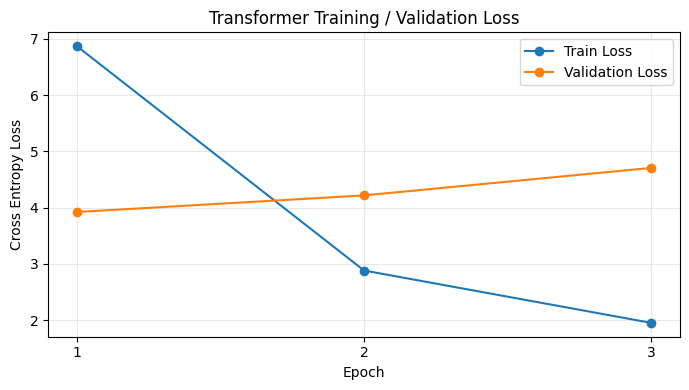

Saved CSV : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/gd06_training_history.csv
Saved Plot: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/outputs/gd06_loss_curve.png


In [30]:
# ============================================================
# Cell 69. Save Training History & Curves
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


history_df = pd.DataFrame(
    training_history
)


# ------------------------------------------------------------
# CSV
# ------------------------------------------------------------

HISTORY_CSV = (
    OUTPUT_DIR
    / "gd06_training_history.csv"
)

history_df.to_csv(
    HISTORY_CSV,
    index=False,
    encoding="utf-8-sig",
)


# ------------------------------------------------------------
# Loss curve
# ------------------------------------------------------------

LOSS_FIG = (
    OUTPUT_DIR
    / "gd06_loss_curve.png"
)


plt.figure(
    figsize=(7, 4)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    marker="o",
    label="Train Loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    marker="o",
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.title(
    "Transformer Training / Validation Loss"
)

plt.xticks(
    history_df["epoch"]
)

plt.legend()
plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    LOSS_FIG,
    dpi=150,
    bbox_inches="tight",
)

plt.show()


print(
    "Saved CSV :",
    HISTORY_CSV
)

print(
    "Saved Plot:",
    LOSS_FIG
)

## 내가 지금 만든 트랜스포머는

Vanilla Encoder–Decoder Transformer 기반의 supervised seq2seq chatbot



```
                    질문
                     │
                     ▼
                Embedding
                     +
             Positional Encoding
                     │
                     ▼
             ┌─────────────┐
             │   Encoder   │
             │ Self-Attn   │
             │    FFN      │
             └──────┬──────┘
                    │
             Encoder Memory
                    │
                    ▼
<start> → ┌─────────────────┐
          │     Decoder     │
          │                 │
          │ Masked Self Attn│
          │        +        │
          │  Cross Attention│◀── Encoder
          │        +        │
          │       FFN       │
          └────────┬────────┘
                   │
                   ▼
                Linear
                   │
                   ▼
           Vocabulary logits
                   │
                   ▼
             다음 token
```



약 7천 개의 독립 Q-A 원본을 Word2Vec으로 약 2.9만 개까지 증강하여, 약 600만 parameter의 1-layer Vanilla Encoder–Decoder Transformer를 scratch부터 학습한 결과, 모델은 매우 빠르게 Train 데이터에 fitting되었고 Epoch 2 이후 validation NLL이 악화되었다. 이는 제한된 원본 데이터 다양성, lexical augmentation의 의미 노이즈, 그리고 warm-up 과정의 높은 learning rate가 함께 영향을 미쳤을 가능성이 있다.

In [31]:
# ============================================================
# Cell 68. Restore Best Transformer
# ============================================================

best_ckpt = torch.load(
    BEST_CHECKPOINT,
    map_location="cpu",
    weights_only=False,
)


print("=" * 70)
print("[Best checkpoint]")
print("=" * 70)

print(
    "Best saved epoch :",
    best_ckpt["epoch"]
)

print(
    "Global step      :",
    best_ckpt["global_step"]
)

print(
    "Best val loss    :",
    best_ckpt["best_val_loss"]
)


# ------------------------------------------------------------
# Best weight 복원
# ------------------------------------------------------------

transformer.load_state_dict(
    best_ckpt["model_state_dict"]
)

transformer = transformer.to(device)
transformer.eval()


# ------------------------------------------------------------
# 검증
# ------------------------------------------------------------

assert best_ckpt["epoch"] == 1

assert (
    transformer.fc.weight.data_ptr()
    ==
    transformer.embedding.weight.data_ptr()
)


print(
    "\nEpoch 1 Best Transformer 복원 완료"
)

[Best checkpoint]
Best saved epoch : 1
Global step      : 455
Best val loss    : 3.9224264838243763

Epoch 1 Best Transformer 복원 완료


In [33]:
# ============================================================
# Cell 70-R1. Runtime restart 후 inference tokenizer 복원
# ============================================================

%pip install -q \
    konlpy==0.6.0 \
    mecab-python3==1.0.12 \
    mecab-ko-dic==1.0.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.2/33.2 MB 36.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 88.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.3/591.3 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 42.2 MB/s eta 0:00:00


In [34]:
# ============================================================
# Cell 70-R2. MeCab inference environment
# ============================================================

import os
import re
from pathlib import Path

from konlpy.tag import Mecab
import mecab_ko_dic


# ------------------------------------------------------------
# 1. mecab-ko-dic 경로
# ------------------------------------------------------------

MECAB_DICDIR = str(
    Path(mecab_ko_dic.__file__).parent
    / "dicdir"
)


# ------------------------------------------------------------
# 2. mecabrc가 없는 Colab 환경 보완
# ------------------------------------------------------------

MECABRC = "/usr/local/etc/mecabrc"

os.makedirs(
    os.path.dirname(MECABRC),
    exist_ok=True,
)

if not os.path.exists(MECABRC):
    Path(MECABRC).touch()


# ------------------------------------------------------------
# 3. MeCab 생성
# ------------------------------------------------------------

mecab = Mecab(
    dicpath=MECAB_DICDIR
)


print("=" * 70)
print("[MeCab restored]")
print("=" * 70)

print(
    "Dictionary :",
    MECAB_DICDIR
)

print(
    "Test       :",
    mecab.morphs(
        "오늘 일찍 일어났더니 피곤하다."
    )
)

[MeCab restored]
Dictionary : /usr/local/lib/python3.13/dist-packages/mecab_ko_dic/dicdir
Test       : ['오늘', '일찍', '일어났', '더니', '피곤', '하', '다', '.']


In [35]:
# ============================================================
# Cell 70-R3. Inference preprocessing
# ============================================================

def preprocess_sentence(sentence):
    """
    Train preprocessing과 동일한 규칙.
    """

    sentence = str(
        sentence
    ).lower()

    sentence = re.sub(
        r"[^a-z0-9ㄱ-ㅎㅏ-ㅣ가-힣.,?!~]+",
        " ",
        sentence,
    )

    sentence = re.sub(
        r"\s+",
        " ",
        sentence,
    ).strip()

    return sentence


def encode_question(sentence):
    """
    문자열
    → train과 동일한 정제
    → MeCab
    → 현재 Transformer vocabulary ID
    """

    cleaned = preprocess_sentence(
        sentence
    )

    tokens = mecab.morphs(
        cleaned
    )

    ids = [
        token_to_id.get(
            token,
            UNK_ID,
        )
        for token in tokens
    ]

    return (
        cleaned,
        tokens,
        ids,
    )


# ------------------------------------------------------------
# 검증
# ------------------------------------------------------------

test_sentence = (
    "오늘 일찍 일어났더니 피곤하다."
)

cleaned, tokens, ids = (
    encode_question(
        test_sentence
    )
)


print("=" * 70)
print("[Inference preprocessing]")
print("=" * 70)

print(
    "Original :",
    test_sentence
)

print(
    "Cleaned  :",
    cleaned
)

print(
    "Tokens   :",
    tokens
)

print(
    "IDs      :",
    ids
)

print(
    "UNK count:",
    ids.count(UNK_ID)
)

[Inference preprocessing]
Original : 오늘 일찍 일어났더니 피곤하다.
Cleaned  : 오늘 일찍 일어났더니 피곤하다.
Tokens   : ['오늘', '일찍', '일어났', '더니', '피곤', '하', '다', '.']
IDs      : [118, 762, 1513, 675, 612, 6, 44, 4]
UNK count: 0


In [36]:
# ============================================================
# Cell 71. Autoregressive Greedy Decoding
# ============================================================

@torch.no_grad()
def greedy_decode(
    model,
    sentence,
    max_new_tokens=26,
):
    model.eval()

    # 1. 질문 전처리
    cleaned, src_tokens, src_ids = encode_question(
        sentence
    )

    if len(src_ids) == 0:
        raise ValueError(
            "전처리 후 입력 token이 없습니다."
        )

    src = torch.tensor(
        [src_ids],
        dtype=torch.long,
        device=device,
    )

    # 2. Decoder는 <start>부터 시작
    generated_ids = [START_ID]

    # 3. 한 token씩 생성
    for _ in range(max_new_tokens):

        dec_input = torch.tensor(
            [generated_ids],
            dtype=torch.long,
            device=device,
        )

        (
            enc_mask,
            dec_enc_mask,
            dec_mask,
        ) = build_transformer_masks(
            src,
            dec_input,
        )

        (
            logits,
            _,
            _,
            _,
        ) = model(
            src,
            dec_input,
            enc_mask,
            dec_enc_mask,
            dec_mask,
        )

        # 마지막 위치의 vocabulary logits
        next_logits = logits[:, -1, :].clone()

        # 생성 중 나오면 안 되는 token 차단
        next_logits[:, PAD_ID] = -float("inf")
        next_logits[:, START_ID] = -float("inf")

        # Greedy: 가장 높은 logit 선택
        next_id = int(
            torch.argmax(
                next_logits,
                dim=-1,
            ).item()
        )

        generated_ids.append(next_id)

        # <end>면 종료
        if next_id == END_ID:
            break

    # 4. ID → token
    generated_tokens = [
        id_to_token[token_id]
        for token_id in generated_ids
        if token_id not in {
            START_ID,
            END_ID,
            PAD_ID,
        }
    ]

    return {
        "input": sentence,
        "cleaned": cleaned,
        "source_tokens": src_tokens,
        "source_ids": src_ids,
        "generated_ids": generated_ids,
        "generated_tokens": generated_tokens,
        "response": " ".join(generated_tokens),
        "ended": generated_ids[-1] == END_ID,
    }


print("greedy_decode 정의 완료")

greedy_decode 정의 완료


In [37]:
# ============================================================
# Cell 72. Required chatbot examples
# ============================================================

TEST_QUESTIONS = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

generation_results = []


print("=" * 70)
print("[Greedy chatbot generation]")
print("=" * 70)


for i, question in enumerate(
    TEST_QUESTIONS,
    start=1,
):

    result = greedy_decode(
        transformer,
        question,
        max_new_tokens=26,
    )

    generation_results.append(result)

    print(f"\n[{i}]")
    print("Q:", question)
    print(
        "Tokenized Q:",
        result["source_tokens"]
    )
    print(
        "UNK count:",
        result["source_ids"].count(
            UNK_ID
        )
    )
    print(
        "A:",
        result["response"]
    )
    print(
        "Generated <end>:",
        result["ended"]
    )

[Greedy chatbot generation]

[1]
Q: 지루하다, 놀러가고 싶어.
Tokenized Q: ['지루', '하', '다', ',', '놀', '러', '가', '고', '싶', '어', '.']
UNK count: 0
A: 마음 이 에요 .
Generated <end>: True

[2]
Q: 오늘 일찍 일어났더니 피곤하다.
Tokenized Q: ['오늘', '일찍', '일어났', '더니', '피곤', '하', '다', '.']
UNK count: 0
A: 많이 사랑 한다면 사과 하 는 게 좋 아요 .
Generated <end>: True

[3]
Q: 간만에 여자친구랑 데이트 하기로 했어.
Tokenized Q: ['간만에', '여자', '친구', '랑', '데이트', '하', '기', '로', '했', '어', '.']
UNK count: 0
A: 더 좋 은 사람 이 에요 .
Generated <end>: True

[4]
Q: 집에 있는다는 소리야.
Tokenized Q: ['집', '에', '있', '는다는', '소리', '야', '.']
UNK count: 0
A: 마음 이 에요 .
Generated <end>: True


In [38]:
# ============================================================
# Cell 73. Required questions reference lookup
# ============================================================

# augmentation metadata에서 original train 개수 확인
augmentation_metadata = state[
    "augmentation"
]["metadata"]

ORIGINAL_TRAIN_SIZE = sum(
    meta["kind"] == "original"
    for meta in augmentation_metadata
)

print(
    "Original Train size:",
    ORIGINAL_TRAIN_SIZE
)


# final_train_q/a의 앞부분은 original train
original_train_q = final_train_q[
    :ORIGINAL_TRAIN_SIZE
]

original_train_a = final_train_a[
    :ORIGINAL_TRAIN_SIZE
]


def find_reference_answer(question):
    """
    동일한 preprocessing + MeCab tokenization 후
    original Train / Validation에서 정확히 같은 Q를 찾는다.
    """

    cleaned = preprocess_sentence(
        question
    )

    question_tokens = mecab.morphs(
        cleaned
    )

    q_key = tuple(
        question_tokens
    )


    # --------------------------------------------------------
    # Train original
    # --------------------------------------------------------

    for idx, q_tokens in enumerate(
        original_train_q
    ):

        if tuple(q_tokens) == q_key:

            return {
                "split": "train",
                "index": idx,
                "question_tokens":
                    question_tokens,

                "reference_tokens":
                    original_train_a[idx],

                "reference":
                    " ".join(
                        original_train_a[idx]
                    ),
            }


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    for idx, q_tokens in enumerate(
        val_q
    ):

        if tuple(q_tokens) == q_key:

            return {
                "split": "validation",
                "index": idx,
                "question_tokens":
                    question_tokens,

                "reference_tokens":
                    val_a[idx],

                "reference":
                    " ".join(
                        val_a[idx]
                    ),
            }


    return {
        "split": "not_found",
        "index": None,
        "question_tokens":
            question_tokens,

        "reference_tokens": None,
        "reference": None,
    }


reference_results = []


print("=" * 70)
print("[Reference answer lookup]")
print("=" * 70)


for i, question in enumerate(
    TEST_QUESTIONS,
    start=1,
):

    ref = find_reference_answer(
        question
    )

    reference_results.append(
        ref
    )

    print(f"\n[{i}]")
    print("Q        :", question)
    print("Split    :", ref["split"])
    print(
        "Reference:",
        ref["reference"]
    )

Original Train size: 7269
[Reference answer lookup]

[1]
Q        : 지루하다, 놀러가고 싶어.
Split    : not_found
Reference: None

[2]
Q        : 오늘 일찍 일어났더니 피곤하다.
Split    : not_found
Reference: None

[3]
Q        : 간만에 여자친구랑 데이트 하기로 했어.
Split    : not_found
Reference: None

[4]
Q        : 집에 있는다는 소리야.
Split    : not_found
Reference: None


## 생성 메커니즘은 성공했지만 챗봇의 semantic relevance는 낮다.

현재 모델 성능..

```
① Decoder 생성 절차
<start> → token → token → ... → <end>
                         ✅ 배움

② 짧은 한국어 문장 패턴
"~이에요.", "~좋아요."
                         어느 정도 ✅

③ 질문 의미 이해
"피곤하다"가 무엇을 의미하는지
                         약함

④ 질문에 적절한 답 선택
피곤하다 → 쉬라고 답하기
                         상당히 약함
```





```
A. 정량 평가
Validation 383개
각각 reference answer가 존재함
→ 전체 validation set에서 BLEU 계산
→ Validation CrossEntropy / Token Accuracy도 함께 기록

B. 정성 평가
LMS 지정 4문장
reference 없음
→ BLEU 계산하지 않음
→ 실제 생성 응답의
   관련성 / 자연스러움 / 반복 / 종료 여부 평가
```



In [39]:
# ============================================================
# Cell 74. BLEU evaluation
# ============================================================

from nltk.translate.bleu_score import (
    sentence_bleu,
    corpus_bleu,
    SmoothingFunction,
)


smoothing = (
    SmoothingFunction()
    .method1
)


BLEU_WEIGHTS = {
    "BLEU-1":
        (1.0, 0, 0, 0),

    "BLEU-2":
        (0.5, 0.5, 0, 0),

    "BLEU-3":
        (
            1/3,
            1/3,
            1/3,
            0,
        ),

    "BLEU-4":
        (
            0.25,
            0.25,
            0.25,
            0.25,
        ),
}


bleu_rows = []


for (
    generation,
    reference,
) in zip(
    generation_results,
    reference_results,
):

    generated_tokens = (
        generation[
            "generated_tokens"
        ]
    )

    ref_tokens = (
        reference[
            "reference_tokens"
        ]
    )


    row = {
        "question":
            generation["input"],

        "split":
            reference["split"],

        "generated":
            generation["response"],

        "reference":
            reference["reference"],
    }


    if ref_tokens is None:

        for name in BLEU_WEIGHTS:
            row[name] = np.nan

    else:

        for (
            name,
            weights,
        ) in BLEU_WEIGHTS.items():

            score = sentence_bleu(
                [ref_tokens],
                generated_tokens,
                weights=weights,
                smoothing_function=smoothing,
            )

            row[name] = score


    bleu_rows.append(row)


bleu_df = pd.DataFrame(
    bleu_rows
)


print("=" * 70)
print("[Sentence BLEU]")
print("=" * 70)

display(
    bleu_df.round({
        "BLEU-1": 4,
        "BLEU-2": 4,
        "BLEU-3": 4,
        "BLEU-4": 4,
    })
)

[Sentence BLEU]


,question,split,generated,reference,BLEU-1,BLEU-2,BLEU-3,BLEU-4
0,"지루하다, 놀러가고 싶어.",not_found,마음 이 에요 .,None,NaN,NaN,NaN,NaN
1,오늘 일찍 일어났더니 피곤하다.,not_found,많이 사랑 한다면 사과 하 는 게 좋 아요 .,None,NaN,NaN,NaN,NaN
2,간만에 여자친구랑 데이트 하기로 했어.,not_found,더 좋 은 사람 이 에요 .,None,NaN,NaN,NaN,NaN
3,집에 있는다는 소리야.,not_found,마음 이 에요 .,None,NaN,NaN,NaN,NaN


## 19. Final Evaluation

최종 모델은 Validation CrossEntropy Loss가 가장 낮았던
Epoch 1 checkpoint를 사용한다.

추가적인 Epoch별 자유 생성 비교는 수행하지 않는다.
Epoch 1~3의 Validation loss 비교를 통해 Best checkpoint 선정 근거가
이미 확보되었기 때문이다.

최종 평가는 다음 두 가지로 구분한다.

### 1. 정량 평가

Reference answer가 존재하는 Validation 383 pairs를 대상으로
Best Epoch 1 모델의 autoregressive greedy decoding 결과를 생성한다.

생성 결과와 실제 reference answer 사이의

- BLEU-1
- BLEU-2
- BLEU-3
- BLEU-4

를 계산한다.

### 2. 정성 평가

프로젝트에서 지정한 네 질문에 대해 실제 자유 생성 결과를 확인한다.

해당 질문들은 최종 Train/Validation corpus에서 정확히 일치하는 reference가
발견되지 않았으므로 BLEU는 계산하지 않고 다음 기준으로 분석한다.

- 정상적으로 답변 생성을 시작/종료하는가
- 문법적 형태를 갖춘 문장을 생성하는가
- 질문과 응답의 의미적 관련성이 있는가
- generic response를 반복하는가

이를 통해 정량 지표와 실제 챗봇 응답 품질을 함께 평가한다.

In [40]:
# ============================================================
# Cell 76. Validation Greedy Decoding
# ============================================================

@torch.no_grad()
def greedy_decode_from_ids(
    model,
    src_ids,
    max_new_tokens=26,
):
    """
    이미 vectorized된 source IDs로부터
    autoregressive greedy decoding을 수행한다.
    """

    model.eval()

    src = torch.tensor(
        [src_ids],
        dtype=torch.long,
        device=device,
    )

    generated_ids = [
        START_ID
    ]


    for _ in range(
        max_new_tokens
    ):

        dec_input = torch.tensor(
            [generated_ids],
            dtype=torch.long,
            device=device,
        )


        (
            enc_mask,
            dec_enc_mask,
            dec_mask,
        ) = build_transformer_masks(
            src,
            dec_input,
        )


        (
            logits,
            _,
            _,
            _,
        ) = model(
            src,
            dec_input,
            enc_mask,
            dec_enc_mask,
            dec_mask,
        )


        next_logits = (
            logits[:, -1, :]
            .clone()
        )


        # 생성 불가 특수 token
        next_logits[:, PAD_ID] = (
            -float("inf")
        )

        next_logits[:, START_ID] = (
            -float("inf")
        )


        next_id = int(
            torch.argmax(
                next_logits,
                dim=-1,
            ).item()
        )


        generated_ids.append(
            next_id
        )


        if next_id == END_ID:
            break


    generated_tokens = [
        id_to_token[token_id]
        for token_id in generated_ids
        if token_id not in {
            START_ID,
            END_ID,
            PAD_ID,
        }
    ]


    return (
        generated_tokens,
        generated_ids[-1] == END_ID,
    )


print(
    "Validation greedy decoder 정의 완료"
)

Validation greedy decoder 정의 완료


In [41]:
# ============================================================
# Cell 77. Generate Full Validation Set
# ============================================================

from tqdm.auto import tqdm


validation_generations = []


for i in tqdm(
    range(len(enc_val)),
    desc="Validation generation",
):

    generated_tokens, ended = (
        greedy_decode_from_ids(
            transformer,
            enc_val[i],
            max_new_tokens=26,
        )
    )


    validation_generations.append({
        "index":
            i,

        "question_tokens":
            val_q[i],

        "reference_tokens":
            val_a[i],

        "generated_tokens":
            generated_tokens,

        "question":
            " ".join(
                val_q[i]
            ),

        "reference":
            " ".join(
                val_a[i]
            ),

        "generated":
            " ".join(
                generated_tokens
            ),

        "ended":
            ended,
    })


print("=" * 70)
print("[Validation generation]")
print("=" * 70)

print(
    "Generated:",
    len(
        validation_generations
    )
)

print(
    "Ended with <end>:",
    sum(
        row["ended"]
        for row in validation_generations
    ),
    "/",
    len(
        validation_generations
    ),
)

Validation generation:   0%|          | 0/383 [00:00<?, ?it/s]

[Validation generation]
Generated: 383
Ended with <end>: 383 / 383


In [42]:
# ============================================================
# Cell 78. Validation Corpus BLEU
# ============================================================

from nltk.translate.bleu_score import (
    corpus_bleu,
    sentence_bleu,
    SmoothingFunction,
)


smoothing = (
    SmoothingFunction()
    .method1
)


BLEU_WEIGHTS = {
    "BLEU-1":
        (1.0, 0, 0, 0),

    "BLEU-2":
        (0.5, 0.5, 0, 0),

    "BLEU-3":
        (
            1/3,
            1/3,
            1/3,
            0,
        ),

    "BLEU-4":
        (
            0.25,
            0.25,
            0.25,
            0.25,
        ),
}


references = [
    [
        row[
            "reference_tokens"
        ]
    ]
    for row in validation_generations
]


hypotheses = [
    row[
        "generated_tokens"
    ]
    for row in validation_generations
]


corpus_bleu_scores = {}


print("=" * 70)
print("[Validation Corpus BLEU]")
print("=" * 70)


for name, weights in (
    BLEU_WEIGHTS.items()
):

    score = corpus_bleu(
        references,
        hypotheses,
        weights=weights,
        smoothing_function=smoothing,
    )

    corpus_bleu_scores[
        name
    ] = score

    print(
        f"{name:<8}: "
        f"{score:.4f}"
    )

[Validation Corpus BLEU]
BLEU-1  : 0.1610
BLEU-2  : 0.0626
BLEU-3  : 0.0346
BLEU-4  : 0.0185


In [43]:
# ============================================================
# Cell 79. Validation Generation Examples
# ============================================================

import pandas as pd


example_indices = np.linspace(
    0,
    len(validation_generations) - 1,
    10,
    dtype=int,
)


example_rows = []


for idx in example_indices:

    row = validation_generations[
        idx
    ]

    example_rows.append({
        "id":
            idx,

        "Question":
            row["question"],

        "Reference":
            row["reference"],

        "Generated":
            row["generated"],

        "END":
            row["ended"],
    })


validation_example_df = (
    pd.DataFrame(
        example_rows
    )
)


print("=" * 70)
print("[Validation generation examples]")
print("=" * 70)

display(
    validation_example_df
)

[Validation generation examples]


,id,Question,Reference,Generated,END
0,0,자신감 업 되 는 비결 좀,충분히 스스로 극복 할 수 있 을 거 예요 .,잘 될 거 예요 .,True
1,42,한 번 만 더 보 고 싶 어요 .,후회 하 지 않 을 자신 이 있 다면 만나 봐요 .,마음 이 많 았 어요 .,True
2,84,가출 할까 ?,무모 한 결정 을 내리 지 마세요 .,잘 될 거 예요 .,True
3,127,잘 지냈 으면 좋 겠 다,따뜻 한 마음 이 네요 .,좋 은 사람 이 에요 .,True
4,169,좋 아 하 는 애 한테 페메 해 볼까 .,당장 해 보 세요 .,좋 아 하 는 게 좋 아요 .,True
5,212,차 사 는 게 낫 겠 지 ?,판단 은 당신 몫 이 에요 .,좋 은 사람 은 없 어요 .,True
6,254,수염 기를까,길러도 어울리 면 길러 보 세요 .,이제 드세요 .,True
7,297,썸 인가 아닌가,한 방향 인지 양방향 인지 살펴보 세요 .,좋 은 사람 이 에요 .,True
8,339,사귄 지 얼마 안 됐 는데 스킨십 하 려고 해,자신 의 속도 에 맞추 세요 .,많이 사랑 하 는 게 좋 죠 .,True
9,382,이제 자리 잡아가 는데,얼마 남 지 않 았 어요 .,좀 더 잘 될 거 예요 .,True


### 지정 질문 정성 평가

네 개의 지정 질문 모두 vocabulary OOV 없이 처리되었으며,
모델은 네 경우 모두 `<end>` token을 생성하여
autoregressive generation을 정상적으로 종료하였다.

그러나 실제 응답의 의미적 적합성은 낮았다.

예를 들어

- `오늘 일찍 일어났더니 피곤하다.`
  → `많이 사랑 한다면 사과 하 는 게 좋 아요 .`

처럼 문법적인 답변 형태는 생성하지만 질문의 의미와 관계없는 응답이 나타났다.

또한 `마음 이 에요 .`와 같은 generic response가
서로 다른 질문에서 반복되었다.

따라서 본 모델은

- Transformer 기반 sequence generation
- 문장 시작/종료
- 짧은 한국어 답변 패턴

은 학습하였으나,

질문의 의미를 충분히 반영한 응답 생성 능력에는 한계가 있음을 확인하였다.

In [44]:
# ============================================================
# Cell 80. Beam Search Decoding
# ============================================================

@torch.no_grad()
def beam_search_decode(
    model,
    sentence,
    beam_size=3,
    max_new_tokens=26,
    length_penalty=0.7,
):
    """
    동일한 Best Transformer에서 Beam Search로 답변 생성.

    각 step에서 가장 좋은 후보 하나만 남기는 Greedy와 달리
    상위 beam_size개의 sequence 후보를 유지한다.
    """

    model.eval()

    cleaned, src_tokens, src_ids = (
        encode_question(sentence)
    )

    src = torch.tensor(
        [src_ids],
        dtype=torch.long,
        device=device,
    )

    # (generated_ids, log_probability, finished)
    beams = [
        ([START_ID], 0.0, False)
    ]


    for _ in range(max_new_tokens):

        candidates = []

        for (
            generated_ids,
            score,
            finished,
        ) in beams:

            # 이미 <end>가 나온 sequence는 유지
            if finished:
                candidates.append(
                    (
                        generated_ids,
                        score,
                        True,
                    )
                )
                continue


            dec_input = torch.tensor(
                [generated_ids],
                dtype=torch.long,
                device=device,
            )


            (
                enc_mask,
                dec_enc_mask,
                dec_mask,
            ) = build_transformer_masks(
                src,
                dec_input,
            )


            logits, _, _, _ = model(
                src,
                dec_input,
                enc_mask,
                dec_enc_mask,
                dec_mask,
            )


            next_logits = (
                logits[:, -1, :]
                .clone()
            )

            next_logits[:, PAD_ID] = (
                -float("inf")
            )

            next_logits[:, START_ID] = (
                -float("inf")
            )


            log_probs = F.log_softmax(
                next_logits,
                dim=-1,
            )


            top_log_probs, top_ids = (
                torch.topk(
                    log_probs,
                    k=beam_size,
                    dim=-1,
                )
            )


            for j in range(beam_size):

                next_id = int(
                    top_ids[0, j].item()
                )

                next_score = (
                    score
                    + float(
                        top_log_probs[
                            0, j
                        ].item()
                    )
                )

                next_generated = (
                    generated_ids
                    + [next_id]
                )

                candidates.append(
                    (
                        next_generated,
                        next_score,
                        next_id == END_ID,
                    )
                )


        # ----------------------------------------------
        # length-normalized score
        # ----------------------------------------------

        def normalized_score(item):

            ids, score, _ = item

            length = max(
                len(ids) - 1,
                1,
            )

            return (
                score
                / (
                    length
                    ** length_penalty
                )
            )


        candidates.sort(
            key=normalized_score,
            reverse=True,
        )

        beams = candidates[
            :beam_size
        ]


        if all(
            finished
            for _, _, finished
            in beams
        ):
            break


    best_ids, best_score, ended = max(
        beams,
        key=normalized_score,
    )


    generated_tokens = [
        id_to_token[token_id]
        for token_id in best_ids
        if token_id not in {
            START_ID,
            END_ID,
            PAD_ID,
        }
    ]


    return {
        "input":
            sentence,

        "source_tokens":
            src_tokens,

        "generated_tokens":
            generated_tokens,

        "response":
            " ".join(
                generated_tokens
            ),

        "ended":
            ended,

        "score":
            normalized_score(
                (
                    best_ids,
                    best_score,
                    ended,
                )
            ),
    }


print(
    "beam_search_decode 정의 완료"
)

beam_search_decode 정의 완료


In [45]:
# ============================================================
# Cell 81. Greedy vs Beam Search
# ============================================================

decoding_rows = []


for question in TEST_QUESTIONS:

    greedy_result = greedy_decode(
        transformer,
        question,
        max_new_tokens=26,
    )

    beam_result = beam_search_decode(
        transformer,
        question,
        beam_size=3,
        max_new_tokens=26,
    )


    decoding_rows.append({
        "Question":
            question,

        "Greedy":
            greedy_result[
                "response"
            ],

        "Beam-3":
            beam_result[
                "response"
            ],

        "Greedy END":
            greedy_result[
                "ended"
            ],

        "Beam END":
            beam_result[
                "ended"
            ],
    })


decoding_compare_df = (
    pd.DataFrame(
        decoding_rows
    )
)


print("=" * 70)
print("[Greedy vs Beam Search]")
print("=" * 70)

display(
    decoding_compare_df
)

[Greedy vs Beam Search]


,Question,Greedy,Beam-3,Greedy END,Beam END
0,"지루하다, 놀러가고 싶어.",마음 이 에요 .,마음 이 에요 .,True,True
1,오늘 일찍 일어났더니 피곤하다.,많이 사랑 한다면 사과 하 는 게 좋 아요 .,좋 아 하 는 것 도 좋 을 거 예요 .,True,True
2,간만에 여자친구랑 데이트 하기로 했어.,더 좋 은 사람 이 에요 .,친구 가 있 을 거 예요 .,True,True
3,집에 있는다는 소리야.,마음 이 에요 .,마음 이 에요 .,True,True


최종 모델
Vanilla Encoder–Decoder Transformer
1 Encoder Layer + 1 Decoder Layer
약 5.96M parameters

최종 checkpoint
Epoch 1
Validation Loss = 3.9224

Train
29,076 pairs

Validation
383 original pairs

Validation Generation
383 / 383 <end> 정상 종료

Corpus BLEU
BLEU-1 = 0.1610
BLEU-2 = 0.0626
BLEU-3 = 0.0346
BLEU-4 = 0.0185

최종 decoding
Greedy

 ## 20. 프로젝트 최종 결과

### 1. 데이터 전처리 및 증강

원본 ChatbotData의 Q-A pair를 다음 절차로 전처리하였다.

- 영문 소문자화 및 허용 문자 기반 정규식 정제
- MeCab 형태소 분석
- 최대 25 token 길이 제한
- Source와 Target 각각의 중복을 제거하면서 Q-A alignment 유지
- 원본 데이터를 augmentation 전에 Train / Validation으로 분리하여
  augmented sibling이 Validation에 포함되는 데이터 누수를 방지

전처리 결과 원본 7,652 pairs를 확보하였으며,

- Train original: 7,269
- Validation original: 383

으로 분리하였다.

Train에만 Word2Vec 기반 Lexical Substitution을 적용하였다.
문맥 기반 POS 정보와 cosine similarity >= 0.65 조건을 사용하고,
중복 및 Validation leakage를 검사하여 최종적으로

**29,076 Train pairs**

를 구축하였다.

최종 데이터 검증 결과:

- Duplicate Q-A pairs: 0
- Train-Val pair leakage: 0
- Train-Val Q leakage: 0
- Train-Val A leakage: 0

을 확인하였다.

---

### 2. Transformer 모델 학습

질문을 Encoder 입력, 답변을 Decoder 출력으로 사용하는
Vanilla Encoder–Decoder Transformer를 구현하였다.

Baseline configuration:

- Encoder layers: 1
- Decoder layers: 1
- d_model: 368
- Attention heads: 8
- FFN dimension: 1024
- Dropout: 0.2
- Vocabulary size: 7,660
- Batch size: 64
- Adam betas: (0.9, 0.98)
- Warm-up steps: 1,000
- Gradient clipping: 5.0

Teacher Forcing, Padding Mask, Causal Mask,
Encoder-Decoder Cross Attention을 직접 구성하였다.

학습 결과:

| Epoch | Train Loss | Validation Loss | Train Token Acc | Validation Token Acc |
|---|---:|---:|---:|---:|
| 1 | 6.8720 | **3.9224** | 26.47% | 38.82% |
| 2 | 2.8822 | 4.2179 | 45.81% | 40.28% |
| 3 | 1.9506 | 4.7071 | 59.91% | 40.85% |

Train loss는 지속적으로 감소했지만 Epoch 2부터
Validation loss가 증가하였다.

따라서 Validation CrossEntropy Loss가 가장 낮았던
**Epoch 1을 Best checkpoint로 선택**하였다.

이는 단순히 정해진 epoch 수를 모두 학습하는 대신
Validation 성능을 기준으로 과적합을 감시하고 모델을 선택한 것이다.

---

### 3. 자유 생성 및 BLEU 평가

Best Epoch 1 모델에서 autoregressive greedy decoding을 수행하였다.

Validation 383개 전체에 대해 자유 생성을 수행한 결과

**383 / 383 문장에서 `<end>` token을 정상 생성하여 종료**하였다.

Validation reference answer를 이용한 Corpus BLEU 결과:

- BLEU-1: 0.1610
- BLEU-2: 0.0626
- BLEU-3: 0.0346
- BLEU-4: 0.0185

BLEU-1에서는 일부 token overlap이 확인되었으나,
BLEU-2~4는 빠르게 감소하여 reference와 동일한 구문 구조를
생성하는 능력은 제한적이었다.

프로젝트 지정 질문의 자유 생성 결과에서도
문장 생성과 종료 자체는 안정적으로 수행되었으나
질문의 의미와 관계없는 generic response가 반복되는 사례가 확인되었다.

예:

- `지루하다, 놀러가고 싶어.`
  → `마음 이 에요 .`

- `오늘 일찍 일어났더니 피곤하다.`
  → `많이 사랑 한다면 사과 하 는 게 좋 아요 .`

- `간만에 여자친구랑 데이트 하기로 했어.`
  → `더 좋 은 사람 이 에요 .`

- `집에 있는다는 소리야.`
  → `마음 이 에요 .`

Beam Search(size=3)도 추가로 확인하였으나
semantic relevance를 유의미하게 개선하지 못했다.
따라서 최종 추론 방식은 단순하고 재현 가능한 Greedy Decoding을 유지하였다.

---

### 4. 결과 해석 및 한계

본 실험에서는 Transformer의 핵심 구조와
autoregressive sequence generation을 정상적으로 구현하였다.

특히 다음 기능은 정상적으로 학습되었다.

- Encoder-Decoder Transformer forward path
- Teacher Forcing
- Padding / Causal Mask
- Autoregressive token generation
- `<start>` / `<end>` 기반 sequence 제어
- 안정적인 문장 종료

반면 질문의 의미를 충분히 반영하는 답변 생성 능력에는 한계가 있었다.

주요 원인 후보는 다음과 같다.

1. 실제 독립적인 원본 Train pair가 약 7천 개 수준으로 작음
2. 약 2.9만 데이터의 상당 부분이 원본에서 파생된 augmentation임
3. Word2Vec lexical substitution은 semantic similarity이지
   동의어 관계를 보장하지 않아 일부 의미 노이즈가 발생함
4. 모델을 대규모 사전학습 없이 random initialization부터 학습함
5. 약 596만 parameter의 작은 1-layer Transformer라는 구조적 한계가 있음

따라서 본 프로젝트의 모델은 현대적인 대규모 언어모델 수준의 챗봇이라기보다,
**작은 Q-A corpus에서 scratch부터 학습한
Vanilla Encoder–Decoder Transformer 기반 seq2seq chatbot**으로 해석한다.

이번 프로젝트를 통해 Transformer가 어떻게
질문을 Encoder에서 표현하고,
Decoder가 Cross Attention을 통해 질문 정보를 참고하면서
답변 token을 순차적으로 생성하는지를 실제 코드와 실험으로 확인하였다.